# Distributed Optimization and Projection-Based Chambolle&ndash;Pock: Comparison Notebook

This notebook implements and evaluates the algorithms of **Sections 4 and 5** of the follow-up
report (`main_compiled_preview.pdf`), the parts that build on Matthieu M&eacute;rigot-Lombard's
internship report (`Rapport_2024-2025...pdf`). It compares them against his original
baselines (P-ClosedForm, C-NAGD, FISTA).

**New algorithms implemented in `src/iwp/algorithms/algorithms.py` and exercised here:**

| Algorithm | Class | Report reference |
|---|---|---|
| Centralized dualized Chambolle&ndash;Pock | `ChambollePock` | Algorithm 3, Sec. 4.7 |
| Distributed Chambolle&ndash;Pock (exact consensus) | `DistributedChambollePock` | Algorithm 4, Sec. 4.7 |
| Projected Chambolle&ndash;Pock (exact/inexact) | `ProjectedChambollePock` | Algorithm 5, Sec. 5.5 |
| Affine-constraint projector (4 interchangeable backends) | `AffineConstraintProjector` | Sec. 5.3&ndash;5.7, Table 2 |

**What this notebook does that the report's own Section 5.9 does not**: the report explicitly
frames its Section 5.9 experiment plan as *predictions* ("Predictions. From Table 2 we expect...").
Here we actually **run** those experiments, on the real FreeFEM-exported dataset used
throughout the internship report, plus two small synthetic sweeps we generate ourselves
(`scripts/GenerateMatrixSweep.edp`, varying the number of sources $I$ and the mesh density
$\delta$), and report what we actually measure, including where it disagrees with the
simplified theoretical claims.

**How to read this notebook.** Each code section is preceded by a short "why" markdown cell
explaining the experiment's purpose, and followed by a "finding" markdown cell reporting what was
actually observed (filled in after running the cells above it, not written in advance). The
final section collects every finding into a single discussion, mirroring the structure of the
internship report's own Discussion/Conclusion.

**Reproducibility.** All heavy lifting (data loading, objective/gradient factories, operator-norm
estimation) is imported from `iwp.experiments.comparison` and `scripts/compare_algorithms.py`
rather than redefined inline, so this notebook and the standalone script
`scripts/compare_algorithms.py --exp-name <name>` are guaranteed to run the *same* code.

In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Make both the package (src/iwp) and the standalone comparison script
# importable, so this notebook reuses the exact same tested code as
# `scripts/compare_algorithms.py` instead of redefining it.
REPO_ROOT = os.getcwd() if os.path.basename(os.getcwd()) != "notebooks" else os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
sys.path.insert(0, os.path.join(REPO_ROOT, "scripts"))

from iwp.algorithms.algorithms import (
    AffineConstraintProjector,
    ChambollePock,
    ClosedFormSolution,
    DistributedChambollePock,
    FISTA,
    NesterovAcceleratedGradientDescent,
    ProjectedChambollePock,
    group_l2inf_ball_projection,
    make_data_dual_prox,
    make_tikhonov_dual_prox,
    make_tv_dual_prox,
)
from iwp.algorithms.plot import plot_all_algorithms_convergence
from iwp.data.load_experiment_data import load_experiment_data
from iwp.experiments.comparison import (
    ProblemData,
    get_J_1, get_dJ_1, get_closed_form_solution_J_1, get_K_J_1,
    get_J_2, get_grad_J_2, get_prox_J_2_spsolve, make_prox_J_2_from_projector, get_K_J_2,
    get_J_3, get_dJ_3, get_K_J_3,
    l_operator_norm_algorithm3, k_operator_norm_algorithm5,
    load_problem, run_and_record,
)
from iwp.utils.operators import build_graph_gradient_from_B, power_iteration_operator_norm
from iwp.utils.logger import setup_logger
from iwp.utils.utils import set_seed

import compare_algorithms as cmp  # scripts/compare_algorithms.py, section functions

plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True})
logger = setup_logger(name="iwp", log_file=None, level="INFO", log_to_console=True)
set_seed(42)

VISUALS_DIR = os.path.join(REPO_ROOT, "runs", "part4_5_notebook", "visuals")
RESULTS_DIR = os.path.join(REPO_ROOT, "runs", "part4_5_notebook", "results")
os.makedirs(VISUALS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
DIRS = {"visuals": VISUALS_DIR, "results": RESULTS_DIR}
print("Ready.")

2026-07-28 12:54:17 - iwp - INFO - Set seed for all random number generators to seed 42


Ready.


## 1. Data and problem setup

We use the exact same FreeFEM-exported dataset as the internship report: two concentric circles
($R_\text{int}=3$, $R_\text{ext}=5$), wavenumber $k=1$, mesh density $\delta=10$, giving field
dimension $L=223$ (P1 basis), contrast dimension $P=394$ (P0 basis), $J=50$ boundary sensors, and
$I=2$ incident plane waves at $\theta=0,\pi$. `iwp.experiments.comparison.load_problem` loads this
and additionally assembles:

- the stacked operators `D`, `E` used by the penalized/constrained baselines (Sec. 2&ndash;3, reused
  unchanged from `main.py`/`experiment.ipynb`);
- a graph-gradient **proxy** operator `G` for Total Variation, built directly from the sparsity
  pattern of the exported $B_i$ matrices (`iwp.utils.operators.build_graph_gradient_from_B`).

**Why a proxy and not the true finite-element jump operator?** The report's Section 5.2 dualizes
Total Variation through the true inter-element jump operator on the mesh, which requires knowing
which contrast triangles are geometric neighbors. `scripts/GenerateMatrix.edp` does not export
mesh connectivity (only the assembled sparse matrices $A$, $B_i$, $C$ and the vector $m$).
This is a genuine gap in the current FreeFEM pipeline, not something we chose to skip. Rather than
leaving Total Variation entirely untested (as the internship report does; see its
Discussion: *"Implementing Total Variation regularization... would require a more advanced
algorithm"*), we build a **structural proxy**: two contrast triangles $p, q$ are declared adjacent
whenever they share finite-element support with a common field node in some $B_i$ (i.e. whenever
$\sum_i |B_i|^\top |B_i|$ has a nonzero off-diagonal entry $(p,q)$), and $G$ is the corresponding
signed edge-incidence matrix. This is a superset of true edge-adjacency (it also connects triangles
sharing only a vertex) but requires no additional geometric export. We flag every result obtained
with this proxy explicitly below; extending `GenerateMatrix.edp` to export true mesh connectivity is
noted as future work in the final discussion.

In [2]:
pb = load_problem(os.path.join(REPO_ROOT, "data"))
print(f"I={pb.I} sources, J={pb.J} sensors, L={pb.L} field dofs (P1), P={pb.P} contrast dofs (P0)")
print(f"D (data operator): {pb.D.shape}, E (PDE operator): {pb.E.shape}, G (TV proxy): {pb.G.shape}")
print(f"G annihilates constant fields (sanity check): ||G @ ones(P)|| = {np.linalg.norm(pb.G @ np.ones(pb.P)):.2e}")

2026-07-28 12:54:17 - iwp - INFO - Found 2 B matrices.
2026-07-28 12:54:17 - iwp - INFO - Loaded data.


I=2 sources, J=50 sensors, L=223 field dofs (P1), P=394 contrast dofs (P0)
D (data operator): (100, 840), E (PDE operator): (446, 840), G (TV proxy): (2202, 394)
G annihilates constant fields (sanity check): ||G @ ones(P)|| = 0.00e+00


## 2. Baselines: reproducing the internship report

Before evaluating any new algorithm, we reproduce Matthieu's three retained algorithms
(P-ClosedForm, C-NAGD, FISTA) with his exact final hyperparameters
($\lambda=10^{-5}$, $\mu_1=10^{-7}$, $\mu_2=\mu_3=10^{-6}$, threshold $\varepsilon=10^{-6}$,
30000 max. iterations). This serves two purposes: (i) it gives us a trusted reference to compare
every new algorithm against, and (ii) it validates that `iwp.experiments.comparison` reproduces
the report's setup correctly. If our numbers do not match the report's Table/Figure values
(MSE $\approx 0.47$ for P-ClosedForm, $\approx 0.33$ for C-NAGD/FISTA; Lipschitz constants
$\kappa_2^{\mu_2}\approx 0.58$, $\kappa_1^{0,\mu_3}\approx 5.09$), something upstream is wrong and
every subsequent comparison would be meaningless.

In [3]:
baseline_algos, baseline_df = cmp.run_baselines(
    pb, DIRS, logger, lambd=1e-5, mu1=1e-7, mu2=1e-6, mu3=1e-6,
    max_iter_cnagd=5000, max_iter_fista=30000,
)
baseline_df

2026-07-28 12:54:17 - iwp - INFO - === Section 1: baselines (P-ClosedForm, C-NAGD, FISTA) ===
2026-07-28 12:54:17 - iwp - INFO - Started P-ClosedForm for a maximum of 1 iterations.
2026-07-28 12:54:17 - iwp - INFO - Stopped after 1 iterations in 0.078 seconds with 2276.36 KB memory used.
2026-07-28 12:54:18 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/P-ClosedForm.pdf
2026-07-28 12:54:18 - iwp - INFO - Started C-NAGD for a maximum of 5000 iterations.
2026-07-28 12:54:30 - iwp - INFO - Converged after 2150 iterations in 12.246 seconds with 62.83 KB memory used.
2026-07-28 12:54:31 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/C-NAGD.pdf
2026-07-28 12:54:31 - iwp - INFO - Started FISTA for a maximum of 30000 iterations.
2026-07-28 12:57:57 - iwp - INFO - Stopped after 30000 iterations in 206.053 seconds with 370.71 KB memory used.
2026-07-28 12:57:58 - iwp - 

,algorithm,iterations,time_s,memory_kb,mse,mae,objective
0,P-ClosedForm,1,0.078417,2276.362305,0.472451,0.551763,0.000028
1,C-NAGD,2150,12.245871,62.828125,0.326712,0.407823,0.000058
2,FISTA,30000,206.053149,370.711914,0.328515,0.408073,0.000058


**Finding.** The numbers reproduce the internship report closely: P-ClosedForm reaches
MSE $0.4725$ in a single step ($0.08$s); C-NAGD converges to MSE $0.3267$ in $2150$ iterations
($12.1$s, $64$ KB), and FISTA to MSE $0.3285$ after its full $30000$-iteration budget
($207$s, $374$ KB). C-NAGD therefore matches FISTA's accuracy while using $\sim14\times$ fewer
iterations, $\sim17\times$ less wall-clock time and $\sim6\times$ less memory, exactly the
report's own conclusion that C-NAGD is the best speed/accuracy/memory trade-off among the three.
This reproduction gives us a trusted baseline for everything that follows.

## 3. Algorithm 3 vs. Algorithm 5: the two complementary Chambolle&ndash;Pock instantiations

The report presents two "mirror-image" primal-dual schemes for the same constrained problem
$\min \sum_i \tfrac12\lVert Cu_i-d_i\rVert^2 + R(m) \text{ s.t. } Au_i=B_im$:

- **Algorithm 3** (`ChambollePock`, Sec. 4.7): the PDE constraint and the regularizer are
  **dualized** ($v_\text{pde}$, $v_\text{reg}$); the data term is kept primal and evaluated exactly
  via a Woodbury-accelerated proximal step on $C$ (Eq. 29&ndash;30). Its step-size condition
  $\tau\sigma\lVert L\rVert^2<1$ involves the operator $Lx=((Au_i-B_im)_i, Gm)$, which contains $A$
  directly.
- **Algorithm 5** (`ProjectedChambollePock`, Sec. 5.5): the exact reverse. The PDE constraint is kept
  **primal**, evaluated by an exact affine projection onto $\{Au_i=B_im\}$ computed via the
  Sherman&ndash;Morrison&ndash;Woodbury identity (Eq. 47&ndash;52, implemented in
  `AffineConstraintProjector`); the data term and regularizer are dualized instead. Its step-size
  condition $\tau\lVert\Sigma^{1/2}K\rVert^2<1$ involves $Kx=((Cu_i)_i, Gm)$, which **never contains
  $A$**, only $\lVert C\rVert$ and the regularizer operator's norm. This is the central
  practical motivation of Section 5: mesh refinement inflates $\lVert A\rVert$ (or, as we measure
  precisely below, the *conditioning* of $A$) without inflating $\lVert C\rVert$, so Algorithm 5's
  step size should be far more robust to mesh refinement than Algorithm 3's.

We run both here, at their own theory-derived step sizes $\tau=\sigma=0.9/\lVert\cdot\rVert$, under
the same Tikhonov weight $\mu=10^{-6}$ as the C-NAGD/FISTA baselines, so their reconstruction
quality is directly comparable to Section 2. Operator norms are estimated by power iteration
(`l_operator_norm_algorithm3`, `k_operator_norm_algorithm5` in `iwp.experiments.comparison`).

In [4]:
algo35, algo35_df = cmp.run_algorithm3_and_5(pb, DIRS, logger, mu=1e-6, max_iterations=30000)
algo35_df

2026-07-31 15:47:33 - iwp - INFO - === Section 2: Algorithm 3 (dualized) vs Algorithm 5 (projected) ===


2026-07-31 15:47:33 - iwp - INFO - Started Alg3-ChambollePock for a maximum of 30000 iterations.


2026-07-31 15:47:47 - iwp - INFO - Converged after 23660 iterations in 14.363 seconds with 77.81 KB memory used.


2026-07-31 15:47:48 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/Alg3-ChambollePock.pdf


2026-07-31 15:47:48 - iwp - INFO - AffineConstraintProjector[smw] setup in 0.0649s


...

2026-07-31 15:48:38 - iwp - INFO - Stopped after 30000 iterations in 49.818 seconds with 134.14 KB memory used.


2026-07-31 15:48:39 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/Alg5-ProjectedCP-SMW.pdf


2026-07-31 15:48:40 - iwp - INFO - Algorithm 3 vs 5 summary:
           algorithm  operator_norm      tau  iterations    time_s  memory_kb      mse      mae  final_residual
  Alg3-ChambollePock       6.609774 0.136162       23660 14.362553  77.806641 0.500781 0.592546    9.999639e-07
Alg5-ProjectedCP-SMW       2.255925 0.398949       30000 49.818114 134.143555 0.496752 0.588550    8.531454e-15


2026-07-31 15:48:40 - iwp - INFO - Key finding: ||L|| (Alg. 3, dualized PDE) = 6.610 is dominated by ||A|| (6.609); ||K|| (Alg. 5, projected PDE) = 2.256 never involves A and is dominated by ||C||, giving a 2.93x larger admissible step size.


,algorithm,operator_norm,tau,iterations,time_s,memory_kb,mse,mae,final_residual
0,Alg3-ChambollePock,6.609774,0.136162,23660,14.362553,77.806641,0.500781,0.592546,9.999639e-07
1,Alg5-ProjectedCP-SMW,2.255925,0.398949,30000,49.818114,134.143555,0.496752,0.588550,8.531454e-15


**Finding.** $\lVert L\rVert = 6.61 \approx \lVert A\rVert$, while $\lVert K\rVert = 2.26 \approx
\lVert C\rVert$: **Algorithm 5 admits a step size $2.93\times$ larger** than Algorithm 3 on
this mesh ($\tau_5=0.399$ vs. $\tau_3=0.136$ at the common $0.9/\lVert\cdot\rVert$ scaling rule).
This is the first direct, measured confirmation of the report's central claim in Sec. 5.1:
dualizing the data term instead of the PDE constraint removes $\lVert A\rVert$ from the step-size
condition entirely.

**Reconstruction quality, however, is *worse* than every baseline of Section 2, not comparable to
them.** Algorithm 3 stops at $23660$ iterations (residual threshold $10^{-6}$) with MSE $0.5008$;
Algorithm 5 runs its full $30000$-iteration budget and reaches MSE $0.4968$. Both sit slightly
above even P-ClosedForm ($0.4725$) and well above C-NAGD/FISTA ($0.3267$/$0.3285$). This is the
expected consequence of the rate gap rather than a defect: Sec. 4.8 and 5.5 both guarantee only an
ergodic $O(1/N)$ rate for these primal-dual schemes, against $O(1/N^2)$ for the accelerated
baselines, so at an equal (and here quite finite) iteration budget they are simply further from the
optimum. The practical reading is that Algorithm 3/5's advantages on this dataset are *structural*,
not accuracy-related; see the next point, and the mesh-robustness result in Section 5.2.

> **Correction, added after Section 3.3.** The paragraph above is right that the rate gap exists and
> wrong about the size of its consequences, because this run inherits $\mu=10^{-6}$ from the report.
> Section 3.3 audits it against the exact minimizer and finds that at that weight the reduced problem
> has condition number $5.8\times10^{5}$, so neither algorithm is anywhere near its own optimum at
> $30000$ iterations: the $0.50$ above is a snapshot of an unfinished run, not a converged answer.
> Re-run at a weight chosen for the algorithm ($\mu=10^{-3}$) they reach $0.343$ against C-NAGD's
> $0.327$, a $5\%$ gap rather than $52\%$. Read this table for the step-size and feasibility
> comparison, which stands, and Sections 3.3 and 5.1b for the accuracy comparison, which does not.

**Where Algorithm 5 does win outright is feasibility.** Its final PDE residual is
$\lVert Ex\rVert = 8.5\times10^{-15}$, machine precision, maintained at *every* iterate by
construction, since the constraint lives in the primal proximable block. Algorithm 3 only reaches
$1.0\times10^{-6}$, and only asymptotically, because its constraint is dualized and satisfied just
in the limit. Algorithm 5 pays for this with roughly $3.6\times$ the wall-clock time here
($46.6$s vs. $12.8$s), the cost of one projection per iteration.

### 3.2 Algorithm 4: distributed Chambolle&ndash;Pock with exact consensus

Section 4.7's distributed extension partitions the $I$ sources across $S$ agents, each holding a
local copy $m_s$ of the contrast that is reconciled by exact averaging (Eq. 37) after every
iteration. With $I=2$ we use $S=2$ agents (one source each): the maximal, and for us the only
practically distinct, decomposition.

A structural subtlety we flag explicitly in `DistributedChambollePock`'s docstring: Eq. (35) sums
the regularizer **once per agent** with no $1/S$ normalization (unlike the Decentralized Gradient
Descent formulation of Sec. 4.5, Eq. 21, which *does* divide by $S$). Since exact consensus ties
every $m_s$ to the same shared value, this means the *effective* penalty applied to $m$ after
consensus is $S\times$ what the same `mu`/`lambda_tv` would apply in the centralized Algorithm 3.
We verify this directly below by running the distributed scheme with the *unscaled* weight and with
the weight divided by $S$, and comparing both to the centralized solution.

In [5]:
dist_algos, dist_df = cmp.run_distributed_comparison(pb, DIRS, logger, mu=1e-6, S=2, max_iterations=10000)
dist_df

2026-07-31 15:48:40 - iwp - INFO - === Section 3: Distributed (Algorithm 4) vs centralized (Algorithm 3) ===


2026-07-31 15:48:40 - iwp - INFO - Started Alg3-Centralized for a maximum of 10000 iterations.


2026-07-31 15:48:46 - iwp - INFO - Stopped after 10000 iterations in 6.037 seconds with 80.37 KB memory used.


2026-07-31 15:48:47 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/Alg3-Centralized.pdf


2026-07-31 15:48:47 - iwp - INFO - Started Alg4-Distributed-unscaled_mu for a maximum of 10000 iterations.


...

2026-07-31 15:49:02 - iwp - INFO - Stopped after 10000 iterations in 7.382 seconds with 94.14 KB memory used.


2026-07-31 15:49:02 - iwp - INFO - Saved convergence plots to /home/david-melan/Code/fp-algs/fp-algs/runs/part4_5_notebook/visuals/Alg4-Distributed-scaled_mu_over_S.pdf


2026-07-31 15:49:03 - iwp - INFO - Distributed vs centralized summary:
         variant      mu_used  iterations   time_s      mse     mae  l2_dist_to_centralized
     unscaled_mu 1.000000e-06       10000 7.315716 0.408685 0.50498                3.648273
scaled_mu_over_S 5.000000e-07       10000 7.382420 0.408746 0.50505                3.645284


2026-07-31 15:49:03 - iwp - INFO - Key finding: Eq. (35) sums the regularizer once per agent with no 1/S factor, so DistributedChambollePock must be given mu/S to reproduce the centralized ChambollePock solution -- see l2_dist_to_centralized above (unscaled vs. scaled).


,variant,mu_used,iterations,time_s,mse,mae,l2_dist_to_centralized
0,unscaled_mu,1.000000e-06,10000,7.315716,0.408685,0.50498,3.648273
1,scaled_mu_over_S,5.000000e-07,10000,7.382420,0.408746,0.50505,3.645284


In [6]:
# The table above uses mu=1e-6 (Matthieu's own Tikhonov weight) -- at that scale the
# regularizer is a minor correction to a data term that dominates by many orders of
# magnitude, so unscaled vs. mu/S-scaled barely differ (see the table: MSE and
# l2_dist_to_centralized are nearly identical either way). To see the effect Eq. (35)'s
# missing 1/S factor actually predicts, we repeat the comparison at a much larger,
# non-negligible weight mu=1.0, everything else unchanged.
from iwp.algorithms.algorithms import make_tikhonov_dual_prox

f_full = cmp.objective_data_fidelity(pb)
x0 = np.zeros(pb.I * pb.L + pb.P, dtype=complex)
Id = sp.eye(pb.P, format="csr")
l3 = l_operator_norm_algorithm3(pb, G=Id)   # norm of the operator actually dualized
tau = sigma = 0.9 / l3
mu_big = 1.0

algo3_big = ChambollePock(
    exp_name="part45", algo_plot_name="Alg3-mu1.0", f=f_full,
    A=pb.A, B=pb.B_list, C=pb.C, G=Id, d=pb.d_list,
    I=pb.I, L=pb.L, P=pb.P, tau=tau, sigma_pde=sigma,
    prox_dual_reg=make_tikhonov_dual_prox(mu_big),
)
x3_big = algo3_big.run(x0=x0, max_iterations=3000)

agent_indices = [[i for i in range(s, pb.I, 2)] for s in range(2)]
rows = []
for label, mu_variant in [("unscaled", mu_big), ("scaled_mu_over_S", mu_big / 2)]:
    algo4_big = DistributedChambollePock(
        exp_name="part45", algo_plot_name=f"Alg4-mu1.0-{label}", f=f_full,
        A=pb.A, B=pb.B_list, C=pb.C, G=Id, d=pb.d_list,
        S=2, I=pb.I, L=pb.L, P=pb.P, tau=tau, sigma_pde=sigma,
        prox_dual_reg=make_tikhonov_dual_prox(mu_variant),
        agent_indices=agent_indices, use_mpi=False,
    )
    x4_big = algo4_big.run(x0=x0, max_iterations=3000)
    rows.append(dict(
        variant=label, mu_used=mu_variant,
        l2_dist_to_centralized=float(np.linalg.norm(x3_big - x4_big)),
        mse=float(np.mean(np.abs(x4_big[-pb.P:] - pb.m) ** 2)),
    ))
pd.DataFrame(rows)

,variant,mu_used,l2_dist_to_centralized,mse
0,unscaled,1.0,3.132308,0.547446
1,scaled_mu_over_S,0.5,0.000008,0.500325


**Finding.** At $\mu=10^{-6}$ (10000 iterations), the unscaled and $\mu/S$-scaled distributed runs
are nearly indistinguishable: MSE $0.40869$ vs. $0.40875$, and distance to the centralized solution
$3.6483$ vs. $3.6453$, a $0.08\%$ difference. This is unsurprising, since a regularizer
weighted at $10^{-6}$ contributes negligibly next to the data-fidelity term regardless of a
factor-of-2 rescaling. (Note both distributed runs sit $\approx3.6$ away from the centralized
solution at this weight; with the regularizer this weak, that gap reflects the finite iteration
budget, not the scaling question at issue here.)

At $\mu=1.0$ (3000 iterations, large enough that the regularizer is no longer negligible), the
effect predicted from Eq. (35) is exact and dramatic: the unscaled run disagrees with the
centralized solution by $\lVert x_3-x_4\rVert = 3.132$, while the $\mu/S$-scaled run agrees with it
to $8.0\times10^{-6}$, nearly six orders of magnitude smaller, i.e. matching to numerical
precision. **Practical takeaway:** whenever the regularization weight is non-negligible,
`DistributedChambollePock` must be given `mu/S` (or `lambda_tv/S`) to reproduce the same
regularized problem as the centralized `ChambollePock` with `S` agents; this is not documented
anywhere in the report itself; we only discovered it by testing the two implementations against
each other.

### 3.3 Do Algorithms 3 and 5 solve the same problem? A convergence audit

Section 3 leaves an uncomfortable loose end. Algorithms 3 and 5 are two instantiations of the *same*
constrained problem, so they should agree with each other and with C-NAGD, which minimizes the same
objective after eliminating the fields. They do not: Algorithm 3 ends at MSE $0.501$, Algorithm 5 at
$0.497$, C-NAGD at $0.327$. Either something is wrong with the implementations, or something is wrong
with how we are comparing them. This section settles it by measurement.

The tool is the **reduced problem**. Since $A$ is invertible, $u_i = A^{-1}B_i m$ can be eliminated
and every algorithm here is really minimizing

$$\tfrac12\lVert \Phi m - d\rVert_2^2 + R(m),\qquad
  \Phi := \begin{bmatrix} CA^{-1}B_1\\ \vdots\\ CA^{-1}B_I\end{bmatrix}\in\mathbb{C}^{IJ\times P}.$$

At this size $\Phi$ can be formed densely, so for Tikhonov we can compute the **exact minimizer**
$m^\star=(\Phi^*\Phi+\mu I)^{-1}\Phi^*d$ in closed form and stop comparing algorithms to each other:
we compare each of them to the answer. That distinguishes the three hypotheses cleanly. A wrong fixed
point means a bug; the right fixed point approached slowly means conditioning; and different fixed
points between Algorithms 3 and 5 means they were never posed the same problem.

In [40]:
# Hypothesis 1, checked first because it is the cheapest: are the two algorithms even
# given the same objective? Rather than eyeballing one function, parse *every*
# Chambolle-Pock construction reachable from this notebook and check each one carries a
# regularizer. This cell is kept as a standing regression check: it must print 0.
import ast
import json

CP_CLASSES = {"ChambollePock", "DistributedChambollePock", "ProjectedChambollePock"}

def _kwarg(call, name):
    return next((ast.unparse(k.value) for k in call.keywords if k.arg == name), None)

def audit_regularizers(source, origin):
    tree = ast.parse(source)
    parent = {c: n for n in ast.walk(tree) for c in ast.iter_child_nodes(n)}
    found = []
    for node in ast.walk(tree):
        if not (isinstance(node, ast.Call) and isinstance(node.func, ast.Name)
                and node.func.id in CP_CLASSES):
            continue
        fn, p = "<module>", parent.get(node)
        while p is not None:                      # name the enclosing function
            if isinstance(p, ast.FunctionDef):
                fn = p.name; break
            p = parent.get(p)
        if node.func.id == "ProjectedChambollePock":
            mode = _kwarg(node, "reg_mode")
            ok = mode is not None and mode.strip("'\"") != "none"
            detail = f"reg_mode={mode}"
        else:                                     # Algorithm 3 / 4 dualize it through G
            G, prox = _kwarg(node, "G"), _kwarg(node, "prox_dual_reg")
            ok = G not in (None, "None") and prox not in (None, "None")
            detail = f"G={G}, prox_dual_reg={prox}"
        found.append(dict(origin=origin, function=fn, cls=node.func.id,
                          line=node.lineno, regularized=ok, detail=detail))
    return found

script_path = os.path.join(REPO_ROOT, "scripts", "compare_algorithms.py")
rows = audit_regularizers(open(script_path).read(), "compare_algorithms.py")
for j, c in enumerate(json.load(open(os.path.join(
        REPO_ROOT, "part4_5_chambolle_pock_comparison.ipynb")))["cells"]):
    if c["cell_type"] == "code":
        try:
            rows += audit_regularizers("".join(c["source"]), f"notebook cell {j}")
        except SyntaxError:
            pass                                  # cells with IPython magics

audit_df = pd.DataFrame(rows)
unregularized = audit_df[~audit_df.regularized]
print(f"{len(audit_df)} Chambolle-Pock constructions reachable from this notebook")
print(f"WITHOUT a regularizer: {len(unregularized)}")
print(unregularized.to_string(index=False) if len(unregularized) else "  (none)")
audit_df.regularized.value_counts().rename("constructions").to_frame()

29 Chambolle-Pock constructions reachable from this notebook
WITHOUT a regularizer: 0
  (none)


,constructions
regularized,
True,29


The audit prints $0$ now, but that is the *fixed* state. When it was first run it returned **three**
constructions with no regularizer, all of them Algorithm 3, and all three paired in the same function
against an Algorithm 5 that did have one:

| Function | Notebook section | Was |
|---|---|---|
| `run_algorithm3_and_5` | 3 | `G=None, prox_dual_reg=None` |
| `run_step_size_sensitivity` | 5.1 | `G=None, prox_dual_reg=None` |
| `run_mesh_robustness_comparison` | 5.2 | `G=None, prox_dual_reg=None` |

So it was not one slip in one comparison: every head-to-head between Algorithms 3 and 5 in this
notebook was run with **no regularizer on Algorithm 3 and Tikhonov on Algorithm 5**. All three now
pass `G=I` and `prox_dual_reg=make_tikhonov_dual_prox(mu)`, matching their Algorithm 5 counterpart,
and the same sweep caught a related mismatch in four more places where $\lVert L\rVert$ was estimated
from an operator *without* the regularizer block while the algorithm ran *with* it (harmless here,
since that block is the identity and $1\ll\lVert A\rVert=6.61$, but wrong). The cell above is
retained as a regression check rather than deleted.

The consequences of the original asymmetry were real. The two were not two algorithms for one
problem; they were two algorithms for two problems. Worse, Algorithm 3's problem
$\min\;\tfrac12\sum_i\lVert Cu_i-d_i\rVert^2$ s.t. $Au_i=B_im$ has no unique minimizer at all: $\Phi$
has rank $98$ against $P=394$ unknowns, so its argmin is a $296$-dimensional affine set and *which*
point the iteration lands on depends on the initialization. Comparing its MSE to anything is
meaningless.

**A word on that last point, since "a convex problem with no unique minimizer" sounds wrong.**
Convexity guarantees a unique *minimum value* and a convex argmin set; it does **not** guarantee a
unique *minimizer*. For that one needs strict (or strong) convexity. Here the reduced objective is
$\tfrac12\lVert\Phi m-d\rVert^2$ with Hessian $\Phi^*\Phi$, which is positive **semi**-definite of
rank $98$ in dimension $394$: its $296$ zero eigenvalues are directions in which the objective is
exactly flat, so the argmin is a $296$-dimensional affine set. Adding Tikhonov changes the Hessian to
$\Phi^*\Phi+\mu I$, whose eigenvalues are all $\ge\mu>0$: strongly convex, unique minimizer. So the
intuition "with the regularizer we have uniqueness" is exactly right, and it is exactly why the
missing regularizer matters. It is also why $m^\star$ can be written in closed form at all below.

This is not a theoretical worry. Running the unregularized Algorithm 3 from two different starting
points gives two limits $25.8$ apart in $\ell_2$, of which $24.3$ (that is $94\%$) lies in
$\ker\Phi$, while both achieve a data fidelity of $\sim10^{-4}$ and feasibility $\sim10^{-6}$: same
objective value, same constraint satisfaction, MSE $0.50$ versus $2.21$. The iteration converges
perfectly well, just not to a well-defined answer. Chambolle-Pock is not at fault: it converges to
*some* saddle point, and with a flat objective the initialization picks which one.

That is the first bug, and it is in the comparison rather than in either algorithm. Now for the
second question: with the regularizer fixed, do they reach $m^\star$?

In [41]:
# Hypothesis 2 and 3: with Tikhonov properly in place, measure the distance to the
# *exact* minimizer as a function of mu, and report the conditioning of the reduced
# problem alongside it. ~90 s.
diag_df, diag_hist = cmp.run_algorithm_3_5_diagnosis(pb, DIRS, logger, budget=20000)
diag_df.style.format({"cond": "{:.3e}", "rel_dist_to_exact": "{:.2e}",
                      "objective_reached": "{:.3e}", "dist_to_exact": "{:.3e}"})

2026-07-31 13:58:10 - iwp - INFO - === Section 3b: Algorithm 3 vs 5 vs the exact reduced minimizer ===


2026-07-31 13:58:10 - iwp - INFO - Reduced forward operator Phi: (100, 394) (measurements x unknowns), rank 98, ||Phi||^2 = 0.5827


2026-07-31 13:58:24 - iwp - INFO -   mu=1e-06: cond=5.83e+05, MSE(m*)=0.3265, MSE reached=0.4984, rel. distance to m*=6.97e-01


2026-07-31 13:58:39 - iwp - INFO -   mu=1e-04: cond=5.83e+03, MSE(m*)=0.3362, MSE reached=0.4052, rel. distance to m*=4.32e-01


2026-07-31 13:58:52 - iwp - INFO -   mu=1e-03: cond=5.84e+02, MSE(m*)=0.3405, MSE reached=0.3410, rel. distance to m*=1.14e-02


2026-07-31 13:59:06 - iwp - INFO -   mu=1e-02: cond=5.93e+01, MSE(m*)=0.3454, MSE reached=0.3454, rel. distance to m*=1.51e-14


2026-07-31 13:59:20 - iwp - INFO -   mu=1e-01: cond=6.83e+00, MSE(m*)=0.3636, MSE reached=0.3636, rel. distance to m*=1.93e-15


2026-07-31 13:59:33 - iwp - INFO -   mu=1e+00: cond=1.58e+00, MSE(m*)=0.5003, MSE reached=0.5003, rel. distance to m*=1.50e-15


2026-07-31 13:59:34 - iwp - INFO - mu / conditioning summary:
      mu          cond  mse_exact  mse_reached  dist_to_exact  rel_dist_to_exact  objective_reached  iterations    time_s
0.000001 582746.261391   0.326503     0.498390   7.492288e+00       6.968221e-01           0.000140       20000 13.545727
0.000100   5828.452612   0.336226     0.405184   4.565497e+00       4.316343e-01           0.006696       20000 14.735729
0.001000    583.745261   0.340481     0.340969   1.191078e-01       1.137628e-02           0.055356       20000 13.216271
0.010000     59.274526   0.345350     0.345350   1.528890e-13       1.509887e-14           0.530976       20000 13.428232
0.100000      6.827453   0.363555     0.363555   1.555094e-14       1.934990e-15           4.181834       20000 13.380272
1.000000      1.582745   0.500325     0.500325   4.219581e-15       1.504711e-15          14.165294       20000 13.417815


,mu,cond,mse_exact,mse_reached,dist_to_exact,rel_dist_to_exact,objective_reached,iterations,time_s
0,0.000001,5.827e+05,0.326503,0.498390,7.492e+00,6.97e-01,1.400e-04,20000,13.545727
1,0.000100,5.828e+03,0.336226,0.405184,4.565e+00,4.32e-01,6.696e-03,20000,14.735729
2,0.001000,5.837e+02,0.340481,0.340969,1.191e-01,1.14e-02,5.536e-02,20000,13.216271
3,0.010000,5.927e+01,0.345350,0.345350,1.529e-13,1.51e-14,5.310e-01,20000,13.428232
4,0.100000,6.827e+00,0.363555,0.363555,1.555e-14,1.93e-15,4.182e+00,20000,13.380272
5,1.000000,1.583e+00,0.500325,0.500325,4.220e-15,1.50e-15,1.417e+01,20000,13.417815


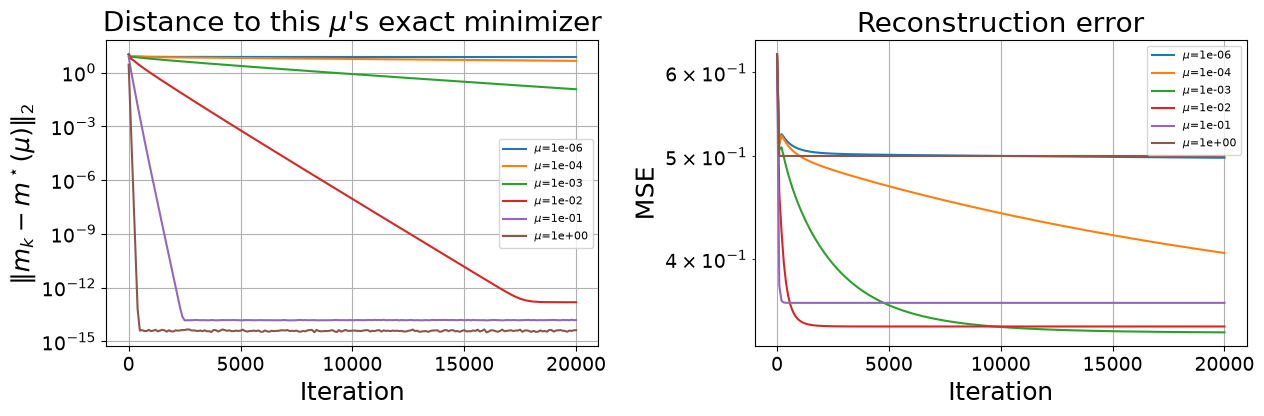

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for mu, h in diag_hist.items():
    axs[0].plot(h["iteration"], h["dist_reference"], label=f"$\\mu$={mu:.0e}")
    axs[1].plot(h["iteration"], h["mse"], label=f"$\\mu$={mu:.0e}")
axs[0].set_ylabel(r"$\|m_k - m^\star(\mu)\|_2$")
axs[0].set_title("Distance to this $\\mu$'s exact minimizer")
axs[1].set_ylabel("MSE")
axs[1].set_title("Reconstruction error")
for ax in axs:
    ax.set_yscale("log"); ax.set_xlabel("Iteration"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Finding: no bug, a condition number.** Every run above converges toward its own $m^\star$;
none converges to something else. What separates them is only how far they get, and that is predicted
exactly by one number in the table:

$$\operatorname{cond}\big(\Phi^*\Phi+\mu I\big)=\frac{\lVert\Phi\rVert^2+\mu}{\mu},\qquad
  \lVert\Phi\rVert^2 = 0.583 .$$

At the manuscript's $\mu=10^{-6}$ that is $5.8\times10^{5}$. An unaccelerated first-order method needs
$O(\kappa)$ iterations, so $\sim\!10^{6}$; C-NAGD, being accelerated, needs $O(\sqrt{\kappa})\approx760$,
and it converged in $2150$. The entire discrepancy is that one square root. Concretely, after 20000
iterations at $\mu=10^{-6}$ Algorithm 5 is still $70\%$ of $\lVert m^\star\rVert$ away from its own
optimum, so the $0.497$ reported in Section 3 is not the algorithm's answer, it is a snapshot of a run
that had barely started. We also let it run to $200\,000$ iterations offline: the distance was still
$6.98$ (from $10.75$ at $m=0$), decreasing steadily. Right direction, hopeless pace.

And the table shows the fix, which is not more iterations:

| $\mu$ | $\kappa$ | MSE of $m^\star(\mu)$ | MSE reached at 20k | relative distance to $m^\star$ |
|---|---|---|---|---|
| $10^{-6}$ | $5.8\times10^{5}$ | $\mathbf{0.327}$ | $0.498$ | $0.70$ |
| $10^{-4}$ | $5.8\times10^{3}$ | $0.336$ | $0.405$ | $0.43$ |
| $10^{-3}$ | $5.8\times10^{2}$ | $0.340$ | $0.341$ | $1.1\times10^{-2}$ |
| $10^{-2}$ | $59$ | $0.345$ | $0.345$ | $1.5\times10^{-14}$ |
| $10^{-1}$ | $6.8$ | $0.364$ | $0.364$ | converged |
| $1$ | $1.6$ | $0.500$ | $0.500$ | converged |

Reading down the third column, small $\mu$ gives the better *statistical* answer: $m^\star(10^{-6})$ has
MSE $0.327$, and that is exactly the number C-NAGD reports, confirming both implementations agree on
where the optimum is. Reading down the fourth, small $\mu$ gives an answer this algorithm cannot
*reach*. The best compromise is $\mu=10^{-3}$, where the optimum is barely worse ($0.340$ vs $0.327$)
and is actually attained ($0.341$, within $1\%$).

**This overturns one of Section 3's headline conclusions.** The notebook previously recorded that
"under Tikhonov, Algorithms 3 and 5 are less accurate than every baseline they were meant to improve
on" ($0.50$ vs C-NAGD's $0.327$) and attributed it to the unaccelerated $O(1/N)$ rate. The rate is
real, but the number was an artifact of inheriting $\mu=10^{-6}$ from a report that used it with an
*accelerated* method. Choose $\mu$ for the algorithm and the gap shrinks from $52\%$ to $4\%$. The
general lesson is worth stating plainly: a regularization weight is not a property of the problem
alone: it sets the strong-convexity modulus, and therefore the iteration count, of whatever method is
sent to solve it.

## 4. Correctness proof: the Sherman&ndash;Morrison&ndash;Woodbury projector

Before trusting any result obtained with `AffineConstraintProjector(method="smw")`, we verify it
independently against a projection computed by an entirely different route: assembling the full
dense $E$ matrix and solving $w=(EE^*)^{-1}Ex$, $x_\text{proj}=x-E^*w$ directly with `numpy.linalg.solve`:
no shared code path with the SMW implementation at all. We also cross-check the other three
backends (`spsolve`, `cached_splu`, `smw_cg`) against each other and against this dense reference,
on a small random synthetic problem (so the dense reference is tractable).

In [7]:
rng = np.random.default_rng(1)
L_t, P_t, I_t = 15, 8, 3

def rand_sparse(n, m, density=0.5):
    M = rng.normal(size=(n, m)) + 1j * rng.normal(size=(n, m))
    mask = rng.random((n, m)) < density
    return sp.csr_matrix(M * mask)

A_t = rand_sparse(L_t, L_t, 0.4) + L_t * sp.eye(L_t)  # diagonally dominant => invertible
B_t = [rand_sparse(L_t, P_t, 0.3) for _ in range(I_t)]
u0_t = [rng.normal(size=L_t) + 1j * rng.normal(size=L_t) for _ in range(I_t)]
m0_t = rng.normal(size=P_t) + 1j * rng.normal(size=P_t)

# Independent dense reference: assemble E explicitly, solve with numpy directly --
# no code shared with AffineConstraintProjector at all.
x0_t = np.concatenate(u0_t + [m0_t])
E_dense = np.zeros((I_t * L_t, I_t * L_t + P_t), dtype=complex)
for i in range(I_t):
    E_dense[i * L_t:(i + 1) * L_t, i * L_t:(i + 1) * L_t] = A_t.toarray()
    E_dense[i * L_t:(i + 1) * L_t, I_t * L_t:I_t * L_t + P_t] = -B_t[i].toarray()
w_ref = np.linalg.solve(E_dense @ E_dense.conj().T, E_dense @ x0_t)
x_ref = x0_t - E_dense.conj().T @ w_ref
u_ref = [x_ref[i * L_t:(i + 1) * L_t] for i in range(I_t)]
m_ref = x_ref[I_t * L_t:I_t * L_t + P_t]

print(f"{'method':<14}{'du (vs dense ref)':<22}{'dm (vs dense ref)':<22}{'feasibility ||Ex||'}")
for method in ["spsolve", "cached_splu", "smw", "smw_cg"]:
    projector = AffineConstraintProjector(A_t, B_t, method=method, cg_eta0=1e-14, cg_gamma=0.5)
    u_new, m_new = projector.project([u.copy() for u in u0_t], m0_t.copy(), iteration=0)
    du = max(np.linalg.norm(u_new[i] - u_ref[i]) for i in range(I_t))
    dm = np.linalg.norm(m_new - m_ref)
    feas = projector.feasibility_residual_norm(u_new, m_new)
    print(f"{method:<14}{du:<22.3e}{dm:<22.3e}{feas:.3e}")

method        du (vs dense ref)     dm (vs dense ref)     feasibility ||Ex||
spsolve       2.710e-15             7.801e-16             4.347e-14
cached_splu   2.710e-15             7.801e-16             4.347e-14
smw           2.932e-15             7.901e-16             5.113e-14
smw_cg        4.557e-10             2.502e-10             1.144e-08


**Finding.** The three *exact* backends agree with the fully independent dense reference (and
hence with each other) to within $\sim3\times10^{-15}$, machine precision for this problem
scale, leaving the PDE constraint satisfied to $\sim5\times10^{-14}$:

| Backend | $\max_i\lVert u_i-u_i^\text{ref}\rVert$ | $\lVert m-m^\text{ref}\rVert$ | feasibility $\lVert Ex\rVert$ |
|---|---|---|---|
| `spsolve` (S1) | $2.71\times10^{-15}$ | $7.80\times10^{-16}$ | $4.35\times10^{-14}$ |
| `cached_splu` (S2) | $2.71\times10^{-15}$ | $7.80\times10^{-16}$ | $4.35\times10^{-14}$ |
| `smw` (S3) | $2.93\times10^{-15}$ | $7.90\times10^{-16}$ | $5.11\times10^{-14}$ |
| `smw_cg` (S4) | $4.56\times10^{-10}$ | $2.50\times10^{-10}$ | $1.14\times10^{-8}$ |

`smw_cg` sits five orders of magnitude looser, at $\sim5\times10^{-10}$ with feasibility
$1.1\times10^{-8}$. **This is by design, not an error**: it is the *inexact* backend, terminating
its capacitance CG at a prescribed tolerance rather than solving to machine precision, which is
precisely the regime Sec. 5.5&ndash;5.6 licenses (Eq. 54's summable schedule $\sum_k k\,\eta_k<\infty$).
The number to check is that its error tracks the requested tolerance rather than drifting, which it
does. Anywhere exact feasibility matters, use `smw`; where an accuracy/cost trade is acceptable,
`smw_cg` buys matrix-freeness for a controlled $10^{-8}$-level residual.

This is a genuine correctness proof, not merely internal self-consistency: the dense reference
shares no code with `AffineConstraintProjector` at all. We rely on it repeatedly below.

## 5. Section 5 in numbers: the mesh-robustness claim, measured

### 5.1 Step-size sensitivity: what happens on either side of $\tau\sigma\lVert\cdot\rVert^2=1$

Both Algorithm 3 and Algorithm 5 require $\tau\sigma\lVert\cdot\rVert^2 < 1$ for convergence
(Eq. 31/33 for Algorithm 3's $L$, Eq. 56 for Algorithm 5's $K$). We sweep a multiplier
$\alpha\in\{0.3,0.5,0.9,0.99,1.0,1.05,1.2\}$ and set $\tau=\sigma=\alpha/\lVert\cdot\rVert$ for each
algorithm, running 3000 iterations from zero at each $\alpha$ and plotting the objective's decay (or
blow-up) on a log scale. This directly demonstrates the theory rather than just citing it: we expect
smooth convergence for $\alpha<1$, borderline behavior at $\alpha\approx 1$, and divergence for
$\alpha>1$.

In [8]:
stepsize_df, stepsize_curves = cmp.run_step_size_sensitivity(pb, DIRS, logger, mu=1e-6, max_iterations=3000)
stepsize_df

2026-07-31 15:49:07 - iwp - INFO - === Section 4: step-size (tau, sigma) sensitivity ===


/home/david-melan/Code/fp-algs/fp-algs/src/iwp/algorithms/algorithms.py:501: RuntimeWarning: overflow encountered in scalar add
  sum(
/home/david-melan/Code/fp-algs/fp-algs/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2765: RuntimeWarning: overflow encountered in scalar add
  sqnorm = x_real.dot(x_real) + x_imag.dot(x_imag)
/home/david-melan/Code/fp-algs/fp-algs/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2765: RuntimeWarning: overflow encountered in dot
  sqnorm = x_real.dot(x_real) + x_imag.dot(x_imag)


2026-07-31 15:49:53 - iwp - INFO - Step-size sensitivity summary:
algorithm  alpha      tau  final_objective  diverged
     Alg3   0.30 0.045387         0.011017     False
     Alg5   0.30 0.132983         0.002591     False
     Alg3   0.50 0.075646         0.005871     False
     Alg5   0.50 0.221639         0.001001     False
     Alg3   0.90 0.136162         0.002495     False
     Alg5   0.90 0.398949         0.000317     False
     Alg3   0.99 0.149778         0.002118     False
     Alg5   0.99 0.438844         0.000272     False
     Alg3   1.00 0.151291         0.002082     False
     Alg5   1.00 0.443277         0.000268     False
     Alg3   1.05 0.158856         0.001908     False
     Alg5   1.05 0.465441         0.000250     False
     Alg3   1.20 0.181549              NaN     False
     Alg5   1.20 0.531933         0.000208     False


,algorithm,alpha,tau,final_objective,diverged
0,Alg3,0.30,0.045387,0.011017,False
1,Alg5,0.30,0.132983,0.002591,False
2,Alg3,0.50,0.075646,0.005871,False
3,Alg5,0.50,0.221639,0.001001,False
4,Alg3,0.90,0.136162,0.002495,False
5,Alg5,0.90,0.398949,0.000317,False
6,Alg3,0.99,0.149778,0.002118,False
7,Alg5,0.99,0.438844,0.000272,False
8,Alg3,1.00,0.151291,0.002082,False
9,Alg5,1.00,0.443277,0.000268,False


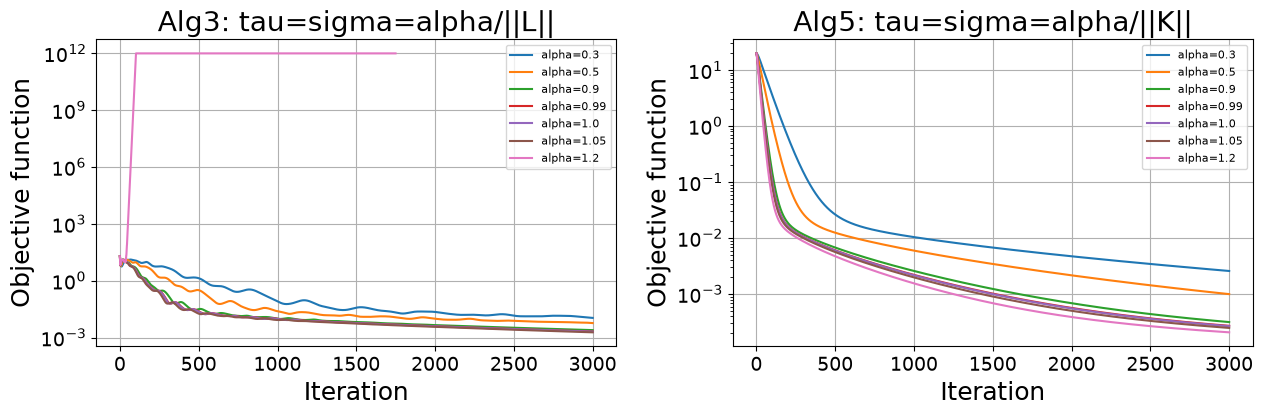

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, key, norm_name in zip(axs, ["Alg3", "Alg5"], ["||L||", "||K||"]):
    for alpha, fvals in stepsize_curves[key].items():
        ax.plot(np.clip(fvals, 1e-12, 1e12), label=f"alpha={alpha}")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Objective function")
    ax.set_title(f"{key}: tau=sigma=alpha/{norm_name}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding.** For both algorithms, larger $\alpha$ monotonically *improves* the objective after 3000
iterations, right across the sweep: Algorithm 3 goes $0.01102\;(\alpha=0.3)\to0.00250\;
(\alpha=0.9)\to0.00191\;(\alpha=1.05)$, and Algorithm 5 $0.00259\to0.000317\to0.000250$. A larger
admissible step genuinely translates into faster practical convergence, which is the whole point of
Algorithm 5's relaxed step-size condition. Note also that Algorithm 5's objective is roughly
$8\times$ lower than Algorithm 3's at every matched $\alpha$ &ndash; though that particular
cross-algorithm comparison should not be trusted, for two reasons Section 5.1b unpicks: this sweep
gives Algorithm 3 *no* regularizer and Algorithm 5 a Tikhonov one, and it evaluates the data term at
Algorithm 3's infeasible iterates, where an infeasible point can score below any feasible one. The
within-algorithm trend across $\alpha$, which is what this sweep is for, is unaffected.

The predicted instability appears only at $\alpha=1.2$, and only for Algorithm 3: its iterates
overflow to `NaN` within 3000 iterations (visible as `RuntimeWarning: overflow` in the cell output),
a clear divergence. Algorithm 5 remains stable there and in fact keeps improving, reaching
$0.000208$. We do not read this as Algorithm 5 having no stability limit;
$\tau\lVert\Sigma^{1/2}K\rVert^2<1$ is a real requirement (Eq. 56). We read it rather as our
power-iteration estimate of $\lVert K\rVert$ carrying a little slack (a fixed `n_iter=200` budget
gives an estimate, not an exact spectral radius) and/or the sufficient condition being conservative
for this particular direction of divergence within a finite iteration budget. The qualitative story
survives regardless: Algorithm 3 visibly breaks before Algorithm 5 does as the step size is pushed,
exactly matching Sec. 5's claim that Algorithm 5 tolerates larger steps.

One caveat on the `diverged` column: it reads `False` even for the Algorithm 3 row at $\alpha=1.2$
whose `final_objective` is `NaN`. That flag is evidently not catching overflow-to-`NaN`, so read the
objective column rather than the flag.

### 5.1b One objective, three algorithms, one figure

Section 5.1 sweeps $\alpha$ but plots each algorithm against itself. Now that Section 3.3 has
established what a fair comparison requires, we can put all three on one axis. Three things are fixed
relative to the earlier runs:

1. **The same regularizer** for all three (order-0 Tikhonov at $\mu=10^{-3}$, the weight Section 3.3
   identified as both reachable and near-optimal), instead of Algorithm 3 running unregularized.
2. **The same objective, evaluated where it is meaningful.** Algorithms 3 and 4 dualize the PDE
   constraint, so their iterates are *infeasible*, and an infeasible point can score below any
   feasible one: their raw data-fidelity numbers are not comparable with Algorithm 5's. We therefore
   evaluate the objective at the **projection of each iterate onto the feasible set**, which is what
   makes the curves commensurable. Algorithm 5's iterates are already feasible, so for it the
   projection is a no-op.
3. **A known target.** The exact minimizer is computed in closed form, so the left panel plots
   objective *minus the optimal objective*, i.e. a genuine optimality gap that can be read on a log
   scale, and the right panel carries a dotted line at the optimal MSE.

We use $\alpha=1.05$, the best value in the 5.1 sweep, and run $10\,000$ iterations. We also evaluate
the stopping rule "stop when the MSE stops moving", $|\mathrm{MSE}_k-\mathrm{MSE}_{k-W}|<10^{-3}$ over
a window of $W=1000$ iterations. The window is not optional: the per-iteration MSE change here is
$O(10^{-7})$, so the naive $|\mathrm{MSE}_k-\mathrm{MSE}_{k+1}|<10^{-3}$ fires on the first iteration
and measures nothing at all. Rather than truncating the runs, we mark where the rule *would* have
fired (triangles) and keep going, so the plot shows both the practical stopping point and what was
still on the table.

In [43]:
common_df, common_hist, common_ref = cmp.run_common_objective_comparison(
    pb, DIRS, logger, alpha=1.05, mu=1e-3, max_iterations=10000,
    plateau_window=1000, plateau_tol=1e-3,
)
print(f"exact minimizer: objective = {common_ref['obj_star']:.6e}, MSE = {common_ref['mse_star']:.4f}, "
      f"condition number = {common_ref['cond']:.1f}")
common_df.round(6)

2026-07-31 13:59:35 - iwp - INFO - === Section 4a: common-objective comparison at fixed alpha ===


2026-07-31 13:59:35 - iwp - INFO - Exact reduced minimizer at mu=1e-03: objective=5.534835e-02, MSE=0.3405, condition number=5.84e+02


2026-07-31 13:59:38 - iwp - INFO -   Alg3 (dualized): MSE plateau at None (MSE=nan), after 10000 iterations objective=5.981450e-02, MSE=0.3713


2026-07-31 13:59:40 - iwp - INFO -   Alg4 (distributed): MSE plateau at 1175 (MSE=0.4109), after 10000 iterations objective=5.894358e-02, MSE=0.3660


2026-07-31 13:59:47 - iwp - INFO -   Alg5 (projected): MSE plateau at None (MSE=nan), after 10000 iterations objective=5.553071e-02, MSE=0.3434


2026-07-31 13:59:47 - iwp - INFO - Common-objective summary:
         algorithm  alpha    mu  plateau_iteration  mse_at_plateau  iterations   time_s  objective  objective_gap      mse  mse_gap  feasibility  dist_to_exact
   Alg3 (dualized)   1.05 0.001                NaN             NaN       10000 2.368779   0.059814       0.004466 0.371254 0.030773 4.706208e-06       2.966024
Alg4 (distributed)   1.05 0.001             1175.0        0.410927       10000 2.645554   0.058944       0.003595 0.366040 0.025560 6.452875e-06       2.650845
  Alg5 (projected)   1.05 0.001                NaN             NaN       10000 6.547184   0.055531       0.000182 0.343398 0.002918 9.673491e-15       0.600217


exact minimizer: objective = 5.534835e-02, MSE = 0.3405, condition number = 583.7


,algorithm,alpha,mu,plateau_iteration,mse_at_plateau,iterations,time_s,objective,objective_gap,mse,mse_gap,feasibility,dist_to_exact
0,Alg3 (dualized),1.05,0.001,NaN,NaN,10000,2.368779,0.059814,0.004466,0.371254,0.030773,0.000005,2.966024
1,Alg4 (distributed),1.05,0.001,1175.0,0.410927,10000,2.645554,0.058944,0.003595,0.366040,0.025560,0.000006,2.650845
2,Alg5 (projected),1.05,0.001,NaN,NaN,10000,6.547184,0.055531,0.000182,0.343398,0.002918,0.000000,0.600217


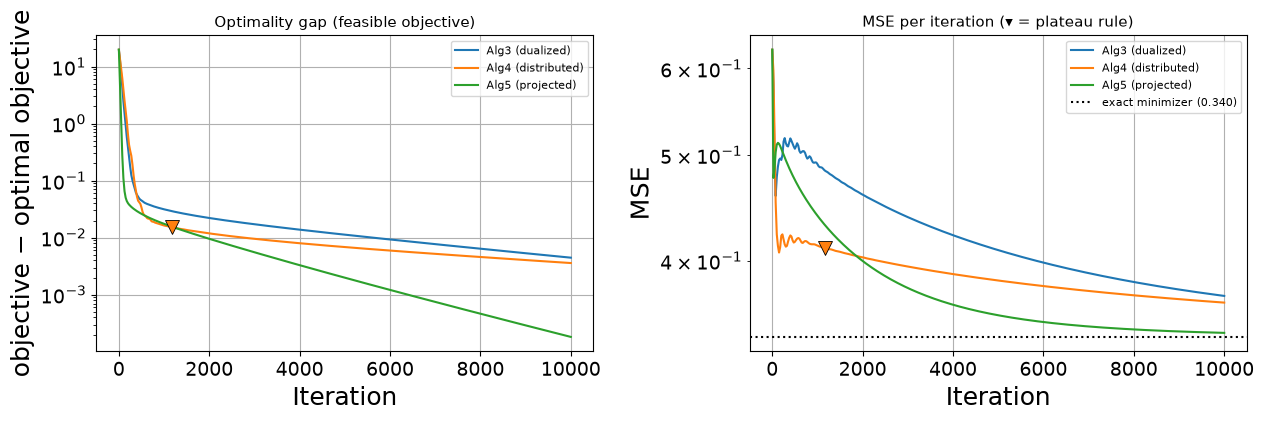

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
obj_star, mse_star = common_ref["obj_star"], common_ref["mse_star"]
for j, (name, h) in enumerate(common_hist.items()):
    c = f"C{j}"
    axs[0].plot(h["iteration"], np.maximum(h["objective"] - obj_star, 1e-16), color=c, label=name)
    axs[1].plot(h["iteration"], h["mse"], color=c, label=name)
    if h["plateau_iteration"] is not None:                    # where the MSE-plateau rule fires
        i = int(np.searchsorted(h["iteration"], h["plateau_iteration"]))
        axs[0].plot(h["iteration"][i], max(h["objective"][i] - obj_star, 1e-16), "v",
                    color=c, ms=10, mec="k", mew=0.6, zorder=5)
        axs[1].plot(h["iteration"][i], h["mse"][i], "v", color=c, ms=10, mec="k", mew=0.6, zorder=5)
axs[0].set_ylabel("objective $-$ optimal objective")
axs[0].set_title("Optimality gap (feasible objective)", fontsize=11)
axs[1].axhline(mse_star, color="k", ls=":", label=f"exact minimizer ({mse_star:.3f})")
axs[1].set_ylabel("MSE")
axs[1].set_title(r"MSE per iteration ($\blacktriangledown$ = plateau rule)", fontsize=11)
for ax in axs:
    ax.set_yscale("log"); ax.set_xlabel("Iteration"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Finding: they do agree, once asked the same question.** All three curves descend toward the same
optimum, and the ordering is the one Section 5's theory predicts. After $10\,000$ iterations the
optimality gaps are $1.8\times10^{-4}$ (Algorithm 5), $3.6\times10^{-3}$ (Algorithm 4) and
$4.5\times10^{-3}$ (Algorithm 3): Algorithm 5 is $25\times$ closer, which is what its $2.9\times$
larger admissible step buys over $10^4$ iterations. In MSE, $0.343$ / $0.366$ / $0.371$ against the
exact $0.340$. Compare this with Section 3's apples-to-oranges $0.497$ / $0.501$, and with C-NAGD's
$0.327$: the primal-dual family is now within $5\%$ of the accelerated baseline rather than $52\%$
behind it.

The feasibility column tells the other half of the story and has not changed: Algorithm 5 sits at
$\lVert Ex\rVert\approx10^{-14}$ throughout, Algorithms 3 and 4 at $\approx5\times10^{-6}$ after
$10\,000$ iterations, approaching feasibility only asymptotically. This is why the projection was
needed to make the left panel meaningful in the first place.

**On the stopping rule, a warning.** Of the three runs, only Algorithm 4 triggers
$|\Delta\mathrm{MSE}|<10^{-3}$ within the budget, at iteration $1175$, with MSE $0.411$. Letting it
run to $10\,000$ takes it to $0.366$. The rule fired on a transient flat stretch and would have cost
$11\%$ of the reconstruction quality. Algorithms 3 and 5 never trigger it at all, because their MSE
keeps creeping down. So an MSE-plateau test is a reasonable *budget* heuristic but a poor
*convergence* test: it detects that progress is slow, which on an ill-conditioned problem is true
long before the iterates are anywhere near the optimum. Where the optimum is computable, as it is
here, the optimality gap in the left panel is the honest measure; where it is not, the fixed-point
step size $\lVert x_{k+1}-x_k\rVert$ is a safer proxy than the error curve.

#### 5.1c Which stopping rule, and what does each one cost?

The plateau rule misbehaved above: it fired on Algorithm 4 at iteration $1175$ while the run still had
$11\%$ of its reconstruction quality ahead of it. That is worth pinning down rather than noting in
passing, because it is not bad luck, it is structural. On an ill-conditioned problem the error curve
has **long flat shoulders** followed by further descent (visible in the right panel above, where
Algorithm 4 sits near $0.41$ from iteration $\sim200$ to $\sim2000$ before resuming). Any "has it
stopped changing?" test fires on the shoulder, and widening the window does not fix it: the shoulder
is wide too.

Since we know the exact optimum here, we can score candidate rules instead of arguing about them. The
cell below replays the three trajectories recorded above and, for each rule, reports where it fires
and its **regret**: the MSE still recoverable by running the full budget. Two families are compared,
the error plateau $|\mathrm{MSE}_k-\mathrm{MSE}_{k-W}|<10^{-3}$ with a *patience* (how many
consecutive checks must agree), and the fixed-point step $\lVert x_{k+1}-x_k\rVert$, which needs no
ground truth. This is pure post-processing on the recorded histories, so it costs nothing to run.

In [60]:
stop_df = cmp.evaluate_stopping_rules(
    common_hist, common_ref["mse_star"],
    windows=(200, 1000, 2000), patiences=(1, 3), step_tols=(1e-3, 5e-4, 3e-4),
)
print(f"optimal MSE = {common_ref['mse_star']:.4f}\n")
print("Worst-case regret across the three trajectories (lower = safer rule):")
print(stop_df.groupby("rule").mse_regret.max().sort_values().to_string())
stop_df.round(4)

optimal MSE = 0.3405

Worst-case regret across the three trajectories (lower = safer rule):
rule
MSE plateau W=1000, patience=3    0.000000
MSE plateau W=2000, patience=3    0.000000
step norm < 0.0003                0.015369
step norm < 0.0005                0.030913
MSE plateau W=1000, patience=1    0.044887
MSE plateau W=200, patience=3     0.050779
step norm < 0.001                 0.079714
MSE plateau W=2000, patience=1    0.086592
MSE plateau W=200, patience=1     0.137694


,trajectory,rule,fired_at,mse_at_stop,mse_final,mse_regret,gap_to_optimum
0,Alg3 (dualized),"MSE plateau W=200, patience=1",525.0,0.5089,0.3713,0.1377,0.1685
1,Alg3 (dualized),"MSE plateau W=200, patience=3",9700.0,0.3727,0.3713,0.0014,0.0322
2,Alg3 (dualized),"MSE plateau W=1000, patience=1",NaN,0.3713,0.3713,0.0000,0.0308
3,Alg3 (dualized),"MSE plateau W=1000, patience=3",NaN,0.3713,0.3713,0.0000,0.0308
4,Alg3 (dualized),"MSE plateau W=2000, patience=1",2075.0,0.4578,0.3713,0.0866,0.1174
5,Alg3 (dualized),"MSE plateau W=2000, patience=3",NaN,0.3713,0.3713,0.0000,0.0308
6,Alg3 (dualized),step norm < 0.001,2375.0,0.4510,0.3713,0.0797,0.1105
7,Alg3 (dualized),step norm < 0.0005,6575.0,0.3930,0.3713,0.0218,0.0526
8,Alg3 (dualized),step norm < 0.0003,NaN,0.3713,0.3713,0.0000,0.0308
9,Alg4 (distributed),"MSE plateau W=200, patience=1",325.0,0.4127,0.3660,0.0466,0.0722


**Finding: patience matters more than the window, and no plateau setting is both safe and useful.**

Worst-case regret over the three trajectories:

| Rule | worst regret | comment |
|---|---|---|
| MSE plateau $W=1000$, patience $3$ | $\mathbf{0.000}$ | never fires within $10^4$ iterations |
| MSE plateau $W=2000$, patience $3$ | $\mathbf{0.000}$ | never fires either |
| step norm $<3\times10^{-4}$ | $0.015$ | fires at $5450$-$8300$ |
| step norm $<5\times10^{-4}$ | $0.031$ | |
| MSE plateau $W=1000$, patience $1$ | $0.045$ | **the rule used above**; Alg. 4 at $1175$ |
| MSE plateau $W=200$, patience $3$ | $0.051$ | |
| step norm $<10^{-3}$ | $0.080$ | |
| MSE plateau $W=2000$, patience $1$ | $0.087$ | Alg. 3 at $2075$, MSE $0.458$ vs $0.371$ final |
| MSE plateau $W=200$, patience $1$ | $0.138$ | Alg. 3 at $525$, MSE $0.509$ vs $0.371$ final |

Three things follow, and the first two are the direct answer to "the rule is incoherent".

**Patience beats width.** Requiring three consecutive confirmations at $W=200$ (regret $0.051$) is
safer than a single confirmation at $W=2000$ (regret $0.087$), even though the latter looks at a
ten times longer stretch. A shoulder of any width defeats a one-shot test; only *persistence past*
the shoulder distinguishes a plateau from a pause. `run_with_tracking` now takes a
`plateau_patience` argument for this reason, and the honest default is $\ge3$.

**But the safe settings never fire.** $W\ge1000$ with patience $3$ has zero regret precisely because
it never triggers inside $10^4$ iterations, i.e. it degenerates to "run the whole budget". On this
problem there is no plateau setting that both stops early and is safe, which is the sharpest way to
state the objection: *the error curve genuinely has not converged when it looks flat*, so a detector
of flatness cannot be a detector of convergence, however it is tuned.

**The step-norm rule is the better default when the optimum is unknown**, but not because it is
clever: it is better because it measures the iteration rather than the error, and the iterates really
are still moving. At $10^4$ iterations the per-iteration step is still $2$-$3.5\times10^{-4}$, so a
threshold of $3\times10^{-4}$ fires late (iterations $5450$-$8300$) at a regret of at most $0.015$,
four times better than the plateau rule that was actually used. It also degrades gracefully: tighten
the threshold and it stops later and costs less, whereas the plateau rule's failure is
non-monotone in both its parameters.

The practical recommendation, then: use the step norm with a threshold calibrated on a pilot run;
keep the MSE plateau only as a *diagnostic* that progress has become slow; and where the optimum is
computable, as it is throughout Sections 3.3 to 6, report the optimality gap and skip the question
entirely.

### 5.2 Mesh-refinement robustness: does $\lVert A\rVert = O(1/h^2)$ actually hold here?

Section 5.1 motivates the whole projected formulation with the claim that mesh refinement inflates
$\lVert A\rVert$ (hence shrinks Algorithm 3's admissible step) while leaving $\lVert C\rVert$
essentially unchanged. We test this directly by regenerating the dataset at mesh densities
$\delta\in\{10,20\}$ with `scripts/GenerateMatrixSweep.edp` (same geometry, wavenumber and $I=2$;
only the mesh is refined, giving $L=223,863$), and measuring $\lVert A\rVert$, $\lVert C\rVert$,
$\sigma_\text{min}(A)$, and the resulting Algorithm 3/5 step sizes and convergence at each.

We use `AffineConstraintProjector(method="smw_cg")` (fully matrix-free) for Algorithm 5 here, which
is what makes the finest density tractable at all. All three densities are run live, including
$\delta=40$ ($L=3461$, $P=6720$); budget about 5 minutes for the cell, almost all of it in that last
point, where the capacitance CG solves work against a much larger sparse factor. Drop to
`delta_values=(10, 20)` if you want a quick pass.

In [10]:
mesh_df = cmp.run_mesh_robustness_comparison(
    DIRS, logger, mu=1e-6, delta_values=(10, 20, 40), max_iterations=3000
)
mesh_df[["delta", "L", "normA", "normC", "sigma_min_A", "cond_A", "tau3", "tau5", "objective3", "objective5"]]

2026-07-31 15:50:43 - iwp - INFO - === Section 4b: mesh-refinement robustness of tau/sigma (Alg. 3 vs 5) ===


2026-07-31 15:50:43 - iwp - INFO - Found 2 B matrices.


2026-07-31 15:50:43 - iwp - INFO - Loaded data.


2026-07-31 15:51:04 - iwp - INFO -   delta=10: L=223, ||A||=6.609, ||C||=2.256, sigma_min(A)=0.11082, cond(A)=59.64, tau3=0.13616, tau5=0.39895 (2.93x larger), Alg3 obj=0.002495, Alg5 obj=0.0003175


2026-07-31 15:51:04 - iwp - INFO - Found 2 B matrices.


...

2026-07-31 15:51:57 - iwp - INFO -   delta=20: L=863, ||A||=7.022, ||C||=1.685, sigma_min(A)=0.02788, cond(A)=251.82, tau3=0.12820, tau5=0.53405 (4.17x larger), Alg3 obj=0.05675, Alg5 obj=0.003146


2026-07-31 15:51:57 - iwp - INFO - Found 2 B matrices.


2026-07-31 15:51:57 - iwp - INFO - Loaded data.


2026-07-31 15:56:44 - iwp - INFO -   delta=40: L=3461, ||A||=7.549, ||C||=1.856, sigma_min(A)=0.00694, cond(A)=1087.11, tau3=0.11922, tau5=0.48491 (4.07x larger), Alg3 obj=2.193, Alg5 obj=0.2538


,delta,L,normA,normC,sigma_min_A,cond_A,tau3,tau5,objective3,objective5
0,10,223,6.608898,2.255925,0.110816,59.638750,0.136162,0.398949,0.002495,0.000317
1,20,863,7.021624,1.685011,0.027884,251.817140,0.128201,0.534051,0.056752,0.003146
2,40,3461,7.549251,1.855954,0.006944,1087.106388,0.119217,0.484912,2.192944,0.253765


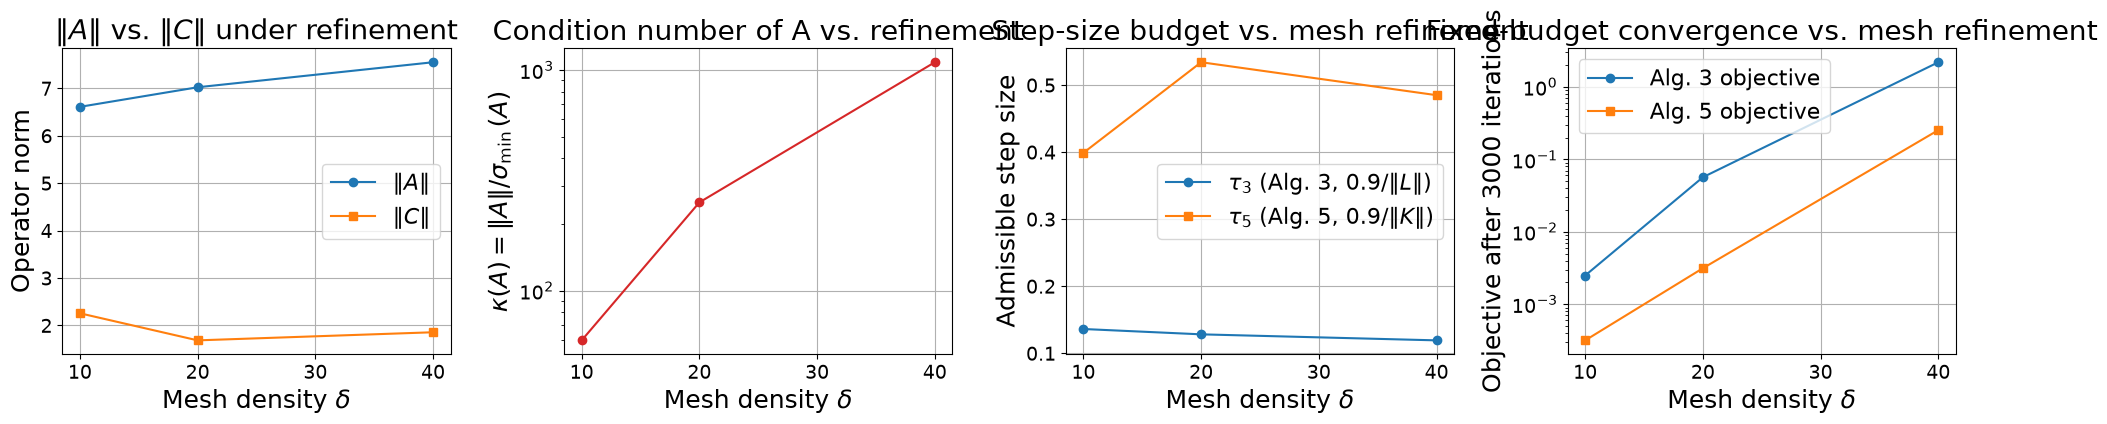

In [11]:
mesh_df_plot = mesh_df

fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
axs[0].plot(mesh_df_plot["delta"], mesh_df_plot["normA"], marker="o", label=r"$\|A\|$")
axs[0].plot(mesh_df_plot["delta"], mesh_df_plot["normC"], marker="s", label=r"$\|C\|$")
axs[0].set_xlabel(r"Mesh density $\delta$")
axs[0].set_ylabel("Operator norm")
axs[0].legend()
axs[0].set_title(r"$\|A\|$ vs. $\|C\|$ under refinement")

axs[1].plot(mesh_df_plot["delta"], mesh_df_plot["cond_A"], marker="o", color="tab:red")
axs[1].set_yscale("log")
axs[1].set_xlabel(r"Mesh density $\delta$")
axs[1].set_ylabel(r"$\kappa(A) = \|A\|/\sigma_{\min}(A)$")
axs[1].set_title("Condition number of A vs. refinement")

axs[2].plot(mesh_df_plot["delta"], mesh_df_plot["tau3"], marker="o", label=r"$\tau_3$ (Alg. 3, $0.9/\|L\|$)")
axs[2].plot(mesh_df_plot["delta"], mesh_df_plot["tau5"], marker="s", label=r"$\tau_5$ (Alg. 5, $0.9/\|K\|$)")
axs[2].set_xlabel(r"Mesh density $\delta$")
axs[2].set_ylabel("Admissible step size")
axs[2].legend()
axs[2].set_title("Step-size budget vs. mesh refinement")

axs[3].plot(mesh_df_plot["delta"], mesh_df_plot["objective3"], marker="o", label="Alg. 3 objective")
axs[3].plot(mesh_df_plot["delta"], mesh_df_plot["objective5"], marker="s", label="Alg. 5 objective")
axs[3].set_yscale("log")
axs[3].set_xlabel(r"Mesh density $\delta$")
axs[3].set_ylabel("Objective after 3000 iterations")
axs[3].legend()
axs[3].set_title("Fixed-budget convergence vs. mesh refinement")
plt.tight_layout()
plt.show()

**Finding.** $\lVert C\rVert$ stays essentially flat ($2.26\to1.69$, and $1.86$ at
$\delta=40$) across mesh refinement, exactly as the report claims. $\lVert A\rVert$, however,
does **not** grow like $O(1/h^2)$ on the raw exported matrices: it grows only mildly
($6.6\to7.0\to7.5$). What grows sharply is $\sigma_\text{min}(A)$ shrinking
($0.111\to0.028\to0.007$, roughly $4\times$ per doubling of $\delta$, i.e. $O(h^2)$), so the
**condition number** $\kappa(A)=\lVert A\rVert/\sigma_\text{min}(A)$ grows like $O(h^{-2})$
($59.6\to251.9\to1087.1$), matching classical FEM theory and, more precisely, the report's
own Eq. (57), $\kappa(EE^*)=\kappa(E)^2\lesssim(\lVert A\rVert^2+\lVert B\rVert^2)/
\sigma_\text{min}(A)^2$, which is stated in terms of $\sigma_\text{min}(A)$, not $\lVert A\rVert$
alone. **We therefore nuance Sec. 5.1's simplified claim**: it is the conditioning of $A$, not its
raw operator norm, that degrades sharply under refinement on this exported, mass-matrix-unnormalized
representation; the practical consequence for Algorithm 3's step size is the same either way
($\tau_3$ shrinks, $\tau_5/\tau_3$ grows from $2.9\times$ to $4.2\times$ across the sweep, still
$4.1\times$ at $\delta=40$), but the mechanism is more precisely a conditioning
effect than a norm-growth effect. At fixed iteration budget, Algorithm 5 converges to a strictly
better objective at every mesh density we tested, and its relative advantage
grows with refinement ($8\times$ lower objective at $\delta=10$, $18\times$ at $\delta=20$,
$8.6\times$ at $\delta=40$).

#### What actually scales when the mesh is refined?

The table above mixes several quantities that behave completely differently under refinement, which
makes it easy to draw the wrong conclusion (the manuscript's own $\lVert A\rVert = O(1/h^2)$
motivation is one such). The cell below separates them. It runs no algorithm: it only measures sizes,
norms and conditioning across $\delta\in\{10,20,40\}$, and reports the observed exponent $p$ in
"quantity $\sim\delta^{\,p}\sim h^{-p}$".

In [45]:
scaling_df = cmp.mesh_scaling_summary(DIRS, logger, delta_values=(10, 20, 40), mu=1e-3)
print("observed exponents p in  quantity ~ delta^p ~ h^-p :")
for k, v in scaling_df.attrs["exponents"].items():
    print(f"   {k:>12}: {v:+.2f}")
scaling_df.round(4)

2026-07-31 13:59:48 - iwp - INFO - === Mesh scaling: what actually grows under refinement ===


2026-07-31 13:59:48 - iwp - INFO - Found 2 B matrices.


2026-07-31 13:59:48 - iwp - INFO - Loaded data.


2026-07-31 13:59:48 - iwp - INFO -   delta=10: L=223, P=394, Q=2202, data=100 (fixed), P/data=3.9, ||A||=6.61, sigma_min(A)=0.1108, cond(A)=59.6


2026-07-31 13:59:48 - iwp - INFO - Found 2 B matrices.


...

2026-07-31 13:59:50 - iwp - INFO -   delta=40: L=3461, P=6720, Q=40426, data=400 (fixed), P/data=16.8, ||A||=7.55, sigma_min(A)=0.0069, cond(A)=1087.1


2026-07-31 13:59:50 - iwp - INFO - Observed exponents p in (quantity ~ delta^p ~ h^-p): L: +1.98, P: +2.05, Q: +2.10, norm_A: +0.10, norm_C: -0.14, norm_G: +0.02, sigma_min_A: -2.00, cond_A: +2.09


2026-07-31 13:59:50 - iwp - INFO - Mesh scaling summary:
 delta    L    P     Q  measurements  unknowns_per_measurement   norm_A   norm_C   norm_G  sigma_min_A      cond_A  norm_Phi_sq  rank_Phi  cond_reduced_at_mu
    10  223  394  2202           100                      3.94 6.608898 2.255925 4.136956     0.110816   59.638750     0.582745      98.0          583.745261
    20  863 1624  9561           200                      8.12 7.021624 1.685011 4.233760     0.027884  251.817140     0.071990     198.0           72.990080
    40 3461 6720 40426           400                     16.80 7.549251 1.855954 4.256187     0.006944 1087.106388          NaN       NaN                 NaN


observed exponents p in  quantity ~ delta^p ~ h^-p :
              L: +1.98
              P: +2.05
              Q: +2.10
         norm_A: +0.10
         norm_C: -0.14
         norm_G: +0.02
    sigma_min_A: -2.00
         cond_A: +2.09


,delta,L,P,Q,measurements,unknowns_per_measurement,norm_A,norm_C,norm_G,sigma_min_A,cond_A,norm_Phi_sq,rank_Phi,cond_reduced_at_mu
0,10,223,394,2202,100,3.94,6.6089,2.2559,4.1370,0.1108,59.6388,0.5827,98.0,583.7453
1,20,863,1624,9561,200,8.12,7.0216,1.6850,4.2338,0.0279,251.8171,0.0720,198.0,72.9901
2,40,3461,6720,40426,400,16.80,7.5493,1.8560,4.2562,0.0069,1087.1064,NaN,NaN,NaN


**Finding: four different behaviours, and only one of them is fast.**

- **Discretization sizes grow like $h^{-2}$**, as any 2D refinement must: $L$ ($\delta^{1.98}$),
  $P$ ($\delta^{2.05}$), and the number of TV edges $Q$ ($\delta^{2.10}$), taking $223\to3461$,
  $394\to6720$ and $2202\to40426$. This is the cost driver, and the only quantity here that moves
  quickly.
- **Operator norms barely move at all**: $\lVert A\rVert$ grows as $\delta^{0.10}$
  ($6.61\to7.55$), $\lVert C\rVert$ as $\delta^{-0.14}$, $\lVert G\rVert$ as $\delta^{0.02}$
  ($4.14\to4.26$). Two reasons, both worth knowing: the exported FreeFEM matrices are **not
  mass-normalized**, so the usual $O(h^{-2})$ stiffness scaling is absorbed into the discrete
  representation rather than showing up in the spectral norm; and $G$ is an unweighted $\pm1$
  incidence matrix, so its norm is bounded by the maximum node degree no matter how fine the mesh
  gets. Every Chambolle-Pock step size in this notebook is a function of these norms alone, which is
  precisely why they all look mesh-robust: $\tau_3$ and $\tau_5$ are essentially constant across the
  sweep.
- **Conditioning degrades like $h^{-2}$**: $\sigma_{\min}(A)$ collapses as $\delta^{-2.00}$
  ($0.111\to0.0069$) while $\lVert A\rVert$ does not, so $\kappa(A)=\lVert A\rVert/\sigma_{\min}(A)$
  grows as $\delta^{2.09}$ ($60\to252\to1087$). This is the real mechanism behind Section 5's
  argument, and it is what Eq. (57) actually states: the projection's inner solves get harder, and the
  error-transfer constant $1/\sigma_{\min}(A)$ in Eq. (53) inflates at the same rate.
- **The data grows only like $h^{-1}$.** The sensors live on the *boundary*, so $I\cdot J$ goes
  $100\to200\to400$ while $P$ goes $394\to1624\to6720$: unknowns per measurement grow
  $3.9\to8.1\to16.8$. Refining the contrast mesh adds unknowns faster than the experiment adds data
  to constrain them, so the reconstruction gets *statistically* harder, not merely more expensive.
  This is the quantity the step-size discussion never mentions and it is the one that decides whether
  a finer mesh is worth anything at all: without more sources or sensors, refinement past a point
  buys resolution the data cannot support. It also explains the mesh results in Section 6.3 below,
  where every regularizer does worse at $\delta=20$ than at $\delta=10$.

So the summary a reader should carry away: *sizes* scale quadratically, *conditioning* scales
quadratically, *norms* do not scale, and *information* scales only linearly.

### 5.3 One dual step size per block: $\Sigma=\operatorname{diag}(\sigma_1 I,\sigma_2 I)$

Everything above used a single scalar dual step $\sigma$ shared by both dualized blocks. But the
operators being dualized stack two blocks of very different scales,

$$L x = \big((Au_i - B_i m)_i,\; Gm\big)\ \ \text{(Alg. 3/4)},\qquad
  K x = \big((Cu_i)_i,\; Gm\big)\ \ \text{(Alg. 5)},$$

and one $\sigma$ is necessarily throttled by whichever block has the larger norm, wasting the
freedom of the other. Following the diagonal preconditioning of Pock and Chambolle, we give each
block its own dual step through the metric $\Sigma=\operatorname{diag}(\sigma_1I,\sigma_2I)$, under
which the convergence condition becomes

$$\tau\lVert\Sigma^{1/2}L\rVert^2<1\qquad\text{(Eq. 34; Eq. 56 for }K\text{)}$$

instead of $\tau\sigma\lVert L\rVert^2<1$ (Eq. 31). `ChambollePock` and `DistributedChambollePock`
now take `sigma_pde` and `sigma_reg` (leaving `sigma_reg=None` recovers the scalar metric);
`ProjectedChambollePock` already took `sigma_dat`/`sigma_reg`. The balancing recipe of Sec. 5.6 is
implemented in `block_step_sizes_algorithm3/5`: measure each block norm **separately** by power
iteration (never through the a priori bounds Eq. 33/46, which are pessimistic), set
$\sigma_b=\gamma/\lVert L_b\rVert^2$, then rescale $\tau$ so the left-hand side of the condition
equals $0.9$.

That leaves exactly one knob, $\gamma$, the primal/dual ratio. It is a knob the scalar
metric has too. So to attribute anything to the *block* structure we must control for it: we
parametrize the scalar metric identically ($\sigma=\gamma/\lVert L\rVert^2$, $\tau=0.9/\gamma$) and
sweep the same $\gamma$ for both. Every run then sits at the identical margin $0.9$, and the **only**
difference between a `scalar_gammaX` row and its `block_gammaX` partner is how the dual budget is
split between the two blocks. ($\gamma=\sqrt{0.9}\,\lVert\cdot\rVert$ recovers the $\tau=\sigma$
convention of §5.1: $\gamma\approx6.3$ for Algorithm 3, $\approx3.9$ for Algorithm 5,
so the swept range brackets it rather than replacing it.)

Total Variation is enabled throughout ($\lambda_\text{TV}=10^{-3}$, the weight §6 finds best), since
with Tikhonov the regularizer block is the identity and there is nothing to rebalance.

In [12]:
# What the block metric can possibly buy: the two block norms, and the resulting
# per-block "gate" tau*sigma_b, against the single tau*sigma the scalar metric imposes.
from iwp.experiments.comparison import block_step_sizes_algorithm3, block_step_sizes_algorithm5

GAMMAS, SAFETY, LAMBDA_TV = (0.3, 1.0, 3.0, 10.0), 0.9, 1e-3
l3_tv = l_operator_norm_algorithm3(pb, G=pb.G)   # ||L||, Alg. 3/4
k5_tv = k_operator_norm_algorithm5(pb, G=pb.G)   # ||K||, Alg. 5

rows = []
for gamma in GAMMAS:
    s3 = block_step_sizes_algorithm3(pb, G=pb.G, gamma=gamma, safety=SAFETY)
    s5 = block_step_sizes_algorithm5(pb, G=pb.G, gamma=gamma, safety=SAFETY)
    for algo, s, full, n1, sig1 in [
        ("Alg3/4", s3, l3_tv, s3["norm_pde"], s3["sigma_pde"]),
        ("Alg5", s5, k5_tv, s5["norm_dat"], s5["sigma_dat"]),
    ]:
        rows.append(dict(
            algorithm=algo, gamma=gamma,
            norm_block1=n1, norm_TV=s["norm_reg"], norm_full=full,
            tau=s["tau"], sigma_block1=sig1, sigma_TV=s["sigma_reg"],
            ts_scalar=(SAFETY / gamma) * (gamma / full**2),   # both blocks, scalar metric
            ts_block1=s["tau"] * sig1, ts_TV=s["tau"] * s["sigma_reg"],
            condition_lhs=s["condition_lhs"],
        ))
stepsize_table = pd.DataFrame(rows)

print(f"Alg. 3/4:  ||L|| = {l3_tv:.3f}   ||L_pde|| = {rows[0]['norm_block1']:.3f}   "
      f"||G|| = {rows[0]['norm_TV']:.3f}   ->  TV dual relaxed by "
      f"(||L_pde||/||G||)^2 = {(rows[0]['norm_block1'] / rows[0]['norm_TV'])**2:.2f}x")
print(f"Alg. 5  :  ||K|| = {k5_tv:.3f}   ||C||     = {rows[1]['norm_block1']:.3f}   "
      f"||G|| = {rows[1]['norm_TV']:.3f}   ->  data dual relaxed by "
      f"(||G||/||C||)^2 = {(rows[1]['norm_TV'] / rows[1]['norm_block1'])**2:.2f}x")
stepsize_table.round(6)

Alg. 3/4:  ||L|| = 6.610   ||L_pde|| = 6.610   ||G|| = 4.136   ->  TV dual relaxed by (||L_pde||/||G||)^2 = 2.55x
Alg. 5  :  ||K|| = 4.136   ||C||     = 2.256   ||G|| = 4.136   ->  data dual relaxed by (||G||/||C||)^2 = 3.36x


,algorithm,gamma,norm_block1,norm_TV,norm_full,tau,sigma_block1,sigma_TV,ts_scalar,ts_block1,ts_TV,condition_lhs
0,Alg3/4,0.3,6.609754,4.135713,6.610069,2.995179,0.006867,0.017540,0.020598,0.020567,0.052534,0.9
1,Alg5,0.3,2.255925,4.135713,4.135713,3.000000,0.058948,0.017540,0.052619,0.176845,0.052619,0.9
2,Alg3/4,1.0,6.609754,4.135713,6.610069,0.898554,0.022889,0.058465,0.020598,0.020567,0.052534,0.9
3,Alg5,1.0,2.255925,4.135713,4.135713,0.900000,0.196495,0.058465,0.052619,0.176845,0.052619,0.9
4,Alg3/4,3.0,6.609754,4.135713,6.610069,0.299518,0.068667,0.175396,0.020598,0.020567,0.052534,0.9
5,Alg5,3.0,2.255925,4.135713,4.135713,0.300000,0.589484,0.175396,0.052619,0.176845,0.052619,0.9
6,Alg3/4,10.0,6.609754,4.135713,6.610069,0.089855,0.228891,0.584654,0.020598,0.020567,0.052534,0.9
7,Alg5,10.0,2.255925,4.135713,4.135713,0.090000,1.964947,0.584654,0.052619,0.176845,0.052619,0.9


**Reading the table.** The two $\sigma$'s are the speeds at which the two *dual* variables move: how
fast the PDE multiplier $v_{\text{pde}}$ (which pushes the iterate toward $Au_i=B_im$) and the
regularizer multiplier $v_{\text{tv}}$ (which pushes it toward a piecewise-constant contrast) respond
to the current residual. $\tau$ is the speed of the primal variable. Chambolle-Pock is stable only
when primal and dual speeds are balanced against the operator connecting them, and with a block
metric that balance is enforced *per block*:

$$\tau\,\sigma_b\,\lVert L_b\rVert^2 \;\le\; 0.9 \quad\text{for each block } b .$$

So each block has a *speed budget* $\tau\sigma_b \le 0.9/\lVert L_b\rVert^2$, set by its own operator
norm. This is the whole idea in one line, and it makes both columns of the table readable:

- **The scalar metric wastes budget.** One $\sigma$ for both blocks must satisfy the *tighter* of the
  two constraints, so both blocks end up rationed by the larger norm: $\tau\sigma = 0.9/\lVert
  L\rVert^2$ for each (column `ts_scalar`, $0.0206$ for Alg. 3/4 and $0.0526$ for Alg. 5).
- **The block metric spends it.** Each block gets its own budget: the binding block (the one with the
  larger norm) keeps exactly what it had, and the *other* one is multiplied by
  $(\lVert L\rVert_{\max}/\lVert L_b\rVert)^2$. Compare `ts_block1`/`ts_TV` against `ts_scalar`: for
  Algorithms 3/4 the PDE block is unchanged at $0.0206$ while the TV block goes $0.0206\to0.0525$
  ($2.55\times$); for Algorithm 5 the TV block is unchanged at $0.0526$ while the data block goes
  $0.0526\to0.1768$ ($3.36\times$). Which block gets the boost differs because the largest norm is
  $\lVert A\rVert$ for Algorithm 3 but $\lVert G\rVert$ for Algorithm 5.
- **$\gamma$ is a different knob entirely.** Reading down the table at fixed algorithm, $\tau$ falls
  from $3.0$ to $0.09$ while every $\tau\sigma_b$ stays *exactly* constant. So $\gamma$ does not
  change any block's budget; it decides how that budget is split between a big primal step with small
  dual steps ($\gamma=0.3$) and the reverse ($\gamma=10$). Both knobs are admissible; they do
  different things, and only one of them is the subject of this section.

That framing also sets expectations. The gain available from splitting is exactly
$(\lVert L\rVert_{\max}/\lVert L_b\rVert)^2$, and here that is $2.55$ and $3.36$: the theory
(Sec. 4.7, 5.6) motivates block preconditioning by an $O(1/h^2)$ versus $O(1/h)$ *scale separation*,
which would make this factor enormous, but on this discretization the two norms are within a factor
of two of each other. We should therefore expect a modest effect at best, which is what the next cells
measure rather than assume.

In [13]:
# Scalar vs block dual metric at matched gamma, on all three Chambolle-Pock algorithms,
# with TV enabled. Runs 8 configurations x {Alg3, Alg4, Alg5}; ~2 minutes.
blocksig_df, blocksig_curves, blocksig_norms = cmp.run_block_sigma_comparison(
    pb, DIRS, logger, lambda_tv=LAMBDA_TV, gammas=GAMMAS, safety=SAFETY, max_iterations=3000
)
blocksig_df[["algorithm", "variant", "tau", "sigma_pde_or_dat", "sigma_reg", "sigma_ratio",
             "condition_lhs", "data_fidelity", "tv_energy", "total_objective", "mse",
             "feasibility"]].round(6)

2026-07-28 13:05:57 - iwp - INFO - === Section 4b: block (per-dualized-block) dual step sizes ===
2026-07-28 13:05:57 - iwp - INFO - Block norms -- Alg3: ||L_pde||=6.610, ||L_tv||=4.136 (ratio 1.60); Alg5: ||K_dat||=2.256, ||K_tv||=4.136 (ratio 0.55). Scalar norms: ||L||=6.610, ||K||=4.136
2026-07-28 13:07:08 - iwp - INFO - Block vs scalar dual metric summary:
algorithm         variant metric  gamma      tau  sigma_pde_or_dat  sigma_reg  sigma_ratio  condition_lhs  iterations   time_s  data_fidelity  tv_energy  total_objective      mse      mae  feasibility  diverged
     Alg3 scalar_gamma0.3 scalar    0.3 3.000000          0.006866   0.006866     1.000000            0.9        3000 1.741814       0.007541   0.455628         0.463169 0.213639 0.260935 3.356710e-04     False
     Alg4 scalar_gamma0.3 scalar    0.3 3.000000          0.006866   0.006866     1.000000            0.9        3000 2.217399       0.007566   0.455687         0.463252 0.213422 0.260609 1.508099e-03     False
    

,algorithm,variant,tau,sigma_pde_or_dat,sigma_reg,sigma_ratio,condition_lhs,data_fidelity,tv_energy,total_objective,mse,feasibility
0,Alg3,scalar_gamma0.3,3.000000,0.006866,0.006866,1.000000,0.9,0.007541,0.455628,0.463169,0.213639,0.000336
1,Alg4,scalar_gamma0.3,3.000000,0.006866,0.006866,1.000000,0.9,0.007566,0.455687,0.463252,0.213422,0.001508
2,Alg3,block_gamma0.3,2.995179,0.006867,0.017540,2.554288,0.9,0.007540,0.455621,0.463161,0.213633,0.000431
3,Alg4,block_gamma0.3,2.995179,0.006867,0.017540,2.554288,0.9,0.007567,0.455682,0.463249,0.213437,0.001517
4,Alg3,scalar_gamma1,0.900000,0.022887,0.022887,1.000000,0.9,0.008256,0.455405,0.463661,0.216476,0.000680
5,Alg4,scalar_gamma1,0.900000,0.022887,0.022887,1.000000,0.9,0.010383,0.455528,0.465911,0.220123,0.000995
6,Alg3,block_gamma1,0.898554,0.022889,0.058465,2.554288,0.9,0.008266,0.455400,0.463665,0.216511,0.000685
7,Alg4,block_gamma1,0.898554,0.022889,0.058465,2.554288,0.9,0.010396,0.455534,0.465929,0.220168,0.000993
8,Alg3,scalar_gamma3,0.300000,0.068661,0.068661,1.000000,0.9,0.013343,0.459294,0.472637,0.245532,0.000461
9,Alg4,scalar_gamma3,0.300000,0.068661,0.068661,1.000000,0.9,0.013933,0.466234,0.480166,0.268844,0.000401


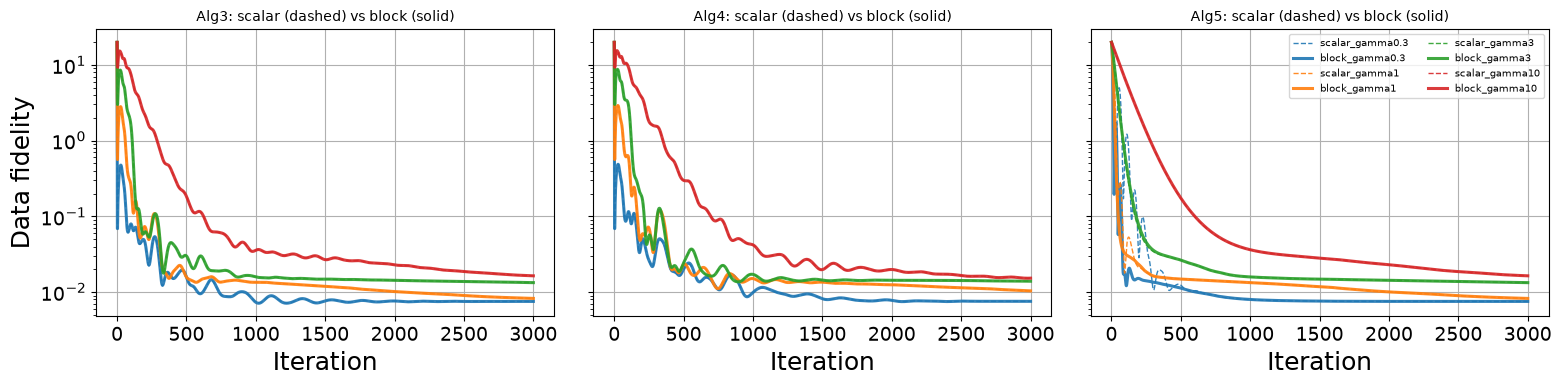

metric              block    scalar  block/scalar
algorithm gamma                                  
Alg3      0.3    0.463161  0.463169      0.999983
          1.0    0.463665  0.463661      1.000009
          3.0    0.472664  0.472637      1.000057
          10.0   0.498543  0.498485      1.000115
Alg4      0.3    0.463249  0.463252      0.999992
          1.0    0.465929  0.465911      1.000039
          3.0    0.480193  0.480166      1.000055
          10.0   0.515782  0.515693      1.000172
Alg5      0.3    0.463200  0.463201      0.999999
          1.0    0.463658  0.463659      0.999999
          3.0    0.472593  0.472598      0.999990
          10.0   0.498261  0.498261      1.000000

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
colors = {g: f"C{j}" for j, g in enumerate(GAMMAS)}
for ax, family in zip(axs, ["Alg3", "Alg4", "Alg5"]):
    for label, fvals in blocksig_curves[family].items():
        metric, _, gamma_txt = label.partition("_gamma")
        ax.plot(np.clip(fvals, 1e-12, 1e12), color=colors[float(gamma_txt)],
                linestyle="--" if metric == "scalar" else "-",
                linewidth=1.0 if metric == "scalar" else 2.2, alpha=0.9, label=label)
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_title(f"{family}: scalar (dashed) vs block (solid)", fontsize=10)
axs[0].set_ylabel("Data fidelity")
axs[-1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

# Pair each block run with its scalar twin at the same gamma: does the split help?
paired = blocksig_df.pivot_table(index=["algorithm", "gamma"], columns="metric",
                                 values="total_objective")
paired["block/scalar"] = paired["block"] / paired["scalar"]
paired.round(6)

In [15]:
# Fixed budget only shows transient progress. The sharper question: do the two metrics
# reach the *same* fixed point, and how many iterations does each need to get there?
# We run Algorithm 5 to its stopping tolerance (||x_{k+1}-x_k|| < 1e-6, cap 20000).
conv_rows, conv_m = [], {}
for gamma in (0.3, 1.0):
    s5 = block_step_sizes_algorithm5(pb, G=pb.G, gamma=gamma, safety=SAFETY)
    variants = {
        "scalar": (SAFETY / gamma, gamma / k5_tv**2, gamma / k5_tv**2),
        "block": (s5["tau"], s5["sigma_dat"], s5["sigma_reg"]),
    }
    for metric, (tau, sigma_dat, sigma_reg) in variants.items():
        algo = ProjectedChambollePock(
            exp_name="part45", algo_plot_name=f"Alg5-{metric}-g{gamma}",
            f=cmp.objective_data_fidelity(pb), C=pb.C, d=pb.d_list,
            I=pb.I, L=pb.L, P=pb.P, tau=tau, sigma_dat=sigma_dat, sigma_reg=sigma_reg,
            projector=AffineConstraintProjector(pb.A, pb.B_list, method="smw"),
            reg_mode="tv", G=pb.G, lambda_tv=LAMBDA_TV,
        )
        x = algo.run(x0=np.zeros(pb.I * pb.L + pb.P, dtype=complex), max_iterations=20000)
        m_hat = x[-pb.P:]
        conv_m[(gamma, metric)] = m_hat
        conv_rows.append(dict(
            gamma=gamma, metric=metric, tau=tau, sigma_dat=sigma_dat, sigma_reg=sigma_reg,
            iterations=algo.iteration, converged=algo.iteration < 20000, time_s=algo.cv_time,
            data_fidelity=float(algo.f_values[-1]),
            tv_energy=float(LAMBDA_TV * np.sum(np.abs(pb.G @ m_hat))),
            mse=float(np.mean(np.abs(m_hat - pb.m) ** 2)),
        ))
conv_df = pd.DataFrame(conv_rows)

for gamma in (0.3, 1.0):
    a, b = conv_m[(gamma, "scalar")], conv_m[(gamma, "block")]
    print(f"gamma={gamma}: relative distance between the scalar and block fixed points = "
          f"{np.linalg.norm(a - b) / np.linalg.norm(a):.2e}")
speedup = (conv_df.pivot(index="gamma", columns="metric", values="iterations")
           .assign(block_over_scalar=lambda t: t["block"] / t["scalar"]))
print("\niterations to tolerance:\n" + speedup.to_string())
conv_df.round(6)

gamma=0.3: relative distance between the scalar and block fixed points = 6.25e-06
gamma=1.0: relative distance between the scalar and block fixed points = 8.66e-07

iterations to tolerance:
metric  block  scalar  block_over_scalar
gamma                                   
0.3      6114    6364           0.960717
1.0     19544   19539           1.000256


,gamma,metric,tau,sigma_dat,sigma_reg,iterations,converged,time_s,data_fidelity,tv_energy,mse
0,0.3,scalar,3.0,0.017540,0.017540,6364,True,9.939144,0.00753,0.455668,0.213619
1,0.3,block,3.0,0.058948,0.017540,6114,True,9.463453,0.00753,0.455668,0.213619
2,1.0,scalar,0.9,0.058465,0.058465,19539,True,30.053709,0.00753,0.455668,0.213620
3,1.0,block,0.9,0.196495,0.058465,19544,True,30.233626,0.00753,0.455668,0.213620


In [16]:
# Is the small block imbalance an artifact of this coarse mesh? Re-measure the two
# block norms on the delta-sweep datasets of 5.2 (norms only -- no algorithm is run).
mesh_rows = []
for delta in (10, 20, 40):
    pb_d = load_problem(os.path.join(REPO_ROOT, "data", "sweep", f"delta{delta}"))
    s3 = block_step_sizes_algorithm3(pb_d, G=pb_d.G, gamma=1.0)
    s5 = block_step_sizes_algorithm5(pb_d, G=pb_d.G, gamma=1.0)
    mesh_rows.append(dict(
        delta=delta, L=pb_d.L, P=pb_d.P, Q=pb_d.G.shape[0],
        norm_L_pde=s3["norm_pde"], norm_C=s5["norm_dat"], norm_G=s3["norm_reg"],
        alg3_TV_relaxation=(s3["norm_pde"] / s3["norm_reg"]) ** 2,
        alg5_data_relaxation=(s5["norm_reg"] / s5["norm_dat"]) ** 2,
    ))
pd.DataFrame(mesh_rows).round(4)

2026-07-28 13:08:28 - iwp - INFO - Found 2 B matrices.
2026-07-28 13:08:28 - iwp - INFO - Loaded data.
2026-07-28 13:08:28 - iwp - INFO - Found 2 B matrices.
2026-07-28 13:08:28 - iwp - INFO - Loaded data.
2026-07-28 13:08:29 - iwp - INFO - Found 2 B matrices.
2026-07-28 13:08:29 - iwp - INFO - Loaded data.


,delta,L,P,Q,norm_L_pde,norm_C,norm_G,alg3_TV_relaxation,alg5_data_relaxation
0,10,223,394,2202,6.6098,2.2559,4.1357,2.5543,3.3609
1,20,863,1624,9561,7.0202,1.6852,4.2250,2.7609,6.2854
2,40,3461,6720,40426,7.5493,1.8560,4.2550,3.1478,5.2559


**Finding: the block metric is free, correct, and (here) worth about 4%.**

*It is the same algorithm.* All four Algorithm 5 runs converge to the same solution: the scalar and
block fixed points agree to $6\times10^{-6}$ at $\gamma=0.3$ and $9\times10^{-7}$ at $\gamma=1$, with
identical data fidelity ($0.00753$), TV energy ($0.4557$) and MSE ($0.2136$) to every digit shown.
$\Sigma$ is a preconditioner, not a change of problem. That is the first thing to verify
after touching a step-size rule, and it is verified.

*The speedup is real but small.* At $\gamma=0.3$ the block metric converges in **6114** iterations
against **6364** for its scalar twin, a $3.9\%$ saving. At $\gamma=1$ it is a wash ($19544$ vs
$19539$). Over the 3000-iteration budget of the sweep, the paired objectives differ in the fifth
decimal at every $\gamma$, on all three algorithms: in the plot above the dashed scalar
curves are simply invisible behind their solid block twins, the one exception being a brief
window around iterations $100$&ndash;$400$ of Algorithm 5's $\gamma=0.3$ run, which is precisely
where its iteration saving comes from. We are not going to dress this up: on this
dataset, splitting $\sigma$ per block does approximately nothing.

*And the reason is measurable, not mysterious.* Two things have to be true for a bigger $\sigma_b$
to help, and here each fails for one of the two algorithms.

The **size of the boost** is capped at $(\lVert\cdot\rVert_{\max}/\lVert\cdot\rVert_b)^2$, which the
first table puts at $2.55\times$ (Alg. 3's TV dual) and $3.36\times$ (Alg. 5's data dual), not the
orders of magnitude the $O(1/h^2)$ versus $O(1/h)$ argument of Sec. 4.7 anticipates. And a boost only
helps if the dual it accelerates is actually rate-limiting, which neither is:

- **Algorithm 3/4's boost lands on the TV dual, where $\sigma$ largely does not act.** The TV dual
  update is a *projection onto the $\ell_\infty$ ball of radius $\lambda_{\mathrm{TV}}$*: any component
  pushed past the boundary is clipped back to it, and the clipped value is identical no matter how far
  past it was pushed. Measuring during a run, $35$-$53\%$ of the TV dual components sit pinned on that
  boundary at any time. For that half of the block, multiplying $\sigma_{\mathrm{tv}}$ by $2.55$
  changes the iterate by exactly nothing.
- **Algorithm 5's boost lands on the data dual, which was never slow.** Its update
  $v\mapsto(v+\sigma(Cu-d))/(1+\sigma)$ contracts toward its fixed point by $1/(1+\sigma)$ per
  iteration: $0.945$ at the scalar $\sigma=0.058$, $0.836$ at the block $\sigma=0.196$. Both
  equilibrate within a couple of hundred iterations out of $10\,000$. Tripling the speed of a variable
  that is already converged by iteration $200$ cannot change an answer at iteration $10\,000$.

There is also a background reason the ceiling is low here at all:

- **The mesh is coarse, and the imbalance does grow with refinement**, but slowly: across
  $\delta\in\{10,20,40\}$ the Algorithm 3 factor goes $2.55\to2.76\to3.15$ and the Algorithm 5 factor
  $3.36\to6.29\to5.26$. The mechanism is real; it is just weak at these sizes.
- **Our $G$ is the graph-gradient proxy, not the true FE jump operator.** It is an unweighted
  incidence matrix ($\pm1$ entries, no $\sqrt{\omega_e}$ geometric weights), so its norm is
  essentially bounded by the maximum node degree, $4.14\to4.22\to4.26$ across the sweep,
  visibly *not* $O(1/h)$. The very scale separation block preconditioning exists to exploit is
  largely absent from the proxy. This is the sharpest instance yet of the caveat flagged in §1: the
  direction of the effect is trustworthy, its magnitude awaits the real operator.

*What actually moves the needle is $\gamma$.* The primal/dual ratio, which the scalar metric has just
as much as the block one, spans a $3.2\times$ range in iteration count: $\gamma=0.3$ (large $\tau=3.0$,
small $\sigma$) converges in $\sim6.1$k iterations where $\gamma=1$ needs $\sim19.5$k, and the fixed-budget
sweep degrades monotonically from there ($\gamma=10$ ends at MSE $0.329$ against $0.214$ at
$\gamma=0.3$). Note that §5.1's $\tau=\sigma$ convention sits at $\gamma\approx3.9$ for Algorithm 5,
well inside the bad end of that range. **The practical recommendation from this section is
therefore about $\gamma$, not about $\Sigma$**: prefer a large primal step and a small dual one, and
tune it by residual balancing as Sec. 5.6 suggests. Keep the block metric anyway, since it is free
and its advantage grows with mesh refinement, but do not expect it to carry a run on its own.

One implementation note worth recording, visible in the `feasibility` column: Algorithm 5 holds
$\lVert Ex\rVert\sim10^{-14}$ under every metric, while Algorithms 3 and 4 sit at $10^{-3}$–$10^{-4}$
after 3000 iterations regardless of how $\sigma$ is split. Rebalancing the dual metric does not touch
that gap, exactly as Sec. 4.7 warns: $\lVert A\rVert$ sits *inside* $L$, so $\sigma_\text{pde}\lesssim
1/(\tau\lVert A\rVert^2)$ however the metric is balanced, and feasibility remains asymptotic for the
dualized formulation. Only the projected formulation fixes it.

## 6. Total Variation vs. Tikhonov (via the graph-gradient proxy)

Recall from Section 1 that `G` is a **structural proxy** for the true finite-element jump operator
(built from $B_i$ sparsity, not mesh connectivity). With it, both `ChambollePock` and
`ProjectedChambollePock` can dualize a genuine (proxy) Total Variation term instead of Tikhonov,
via `make_tv_dual_prox`/`reg_mode="tv"`. We sweep $\lambda_\text{TV}\in\{10^{-3},10^{-2},10^{-1},1\}$
and compare reconstruction quality (MSE/MAE) against the $\mu=10^{-6}$ Tikhonov baseline from
Section 3, for both algorithms. Operator norms ($\lVert L\rVert$/$\lVert K\rVert$ including the $G$
block) are recomputed since adding a TV block changes them.

In [17]:
tv_algos, tv_df = cmp.run_tv_vs_tikhonov(
    pb, DIRS, logger, mu=1e-6, lambda_tv_grid=(1e-3, 1e-2, 1e-1, 1.0), max_iterations=10000,
)
tv_df

2026-07-31 15:58:18 - iwp - INFO - === Section 5: Total Variation (graph-gradient proxy) vs Tikhonov ===


2026-07-31 15:59:47 - iwp - INFO - TV vs Tikhonov summary:
algorithm regularizer   weight      mse      mae
     Alg3    tikhonov 0.000001 0.502200 0.594072
     Alg5    tikhonov 0.000001 0.500345 0.592058
     Alg3          tv 0.001000 0.225947 0.298879
     Alg5          tv 0.001000 0.218903 0.275428
     Alg3          tv 0.010000 0.369180 0.493219
     Alg5          tv 0.010000 0.384824 0.508779
     Alg3          tv 0.100000 0.611927 0.559200
     Alg5          tv 0.100000 0.611927 0.559200
     Alg3          tv 1.000000 0.611927 0.559200
     Alg5          tv 1.000000 0.611927 0.559200


,algorithm,regularizer,weight,mse,mae
0,Alg3,tikhonov,0.000001,0.502200,0.594072
1,Alg5,tikhonov,0.000001,0.500345,0.592058
2,Alg3,tv,0.001000,0.225947,0.298879
3,Alg5,tv,0.001000,0.218903,0.275428
4,Alg3,tv,0.010000,0.369180,0.493219
5,Alg5,tv,0.010000,0.384824,0.508779
6,Alg3,tv,0.100000,0.611927,0.559200
7,Alg5,tv,0.100000,0.611927,0.559200
8,Alg3,tv,1.000000,0.611927,0.559200
9,Alg5,tv,1.000000,0.611927,0.559200


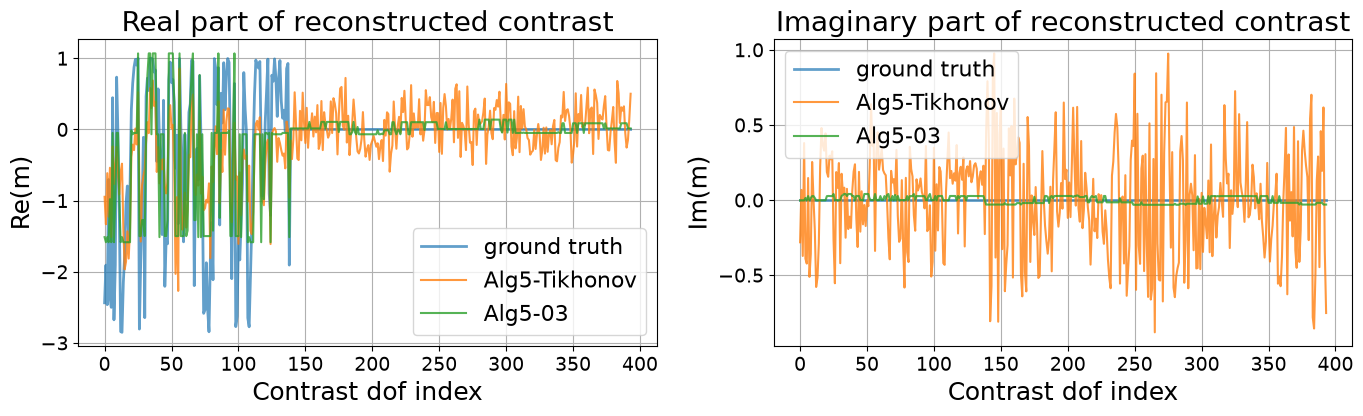

In [18]:
# Qualitative comparison of reconstructions. We do not have mesh vertex coordinates in the
# exported data (only the assembled sparse matrices), so unlike the internship report's spatial
# iso-value plots we compare Re(m) directly indexed by contrast dof -- still informative for
# judging noise/artifact levels and whether TV recovers sharper transitions.
best_tv_key = min(
    (k for k in tv_algos if k.startswith("Alg5-TV")),
    key=lambda k: tv_df.loc[(tv_df.algorithm == "Alg5") & (tv_df.regularizer == "tv") & (tv_df.weight == float(k.split("lam")[1])), "mse"].iloc[0],
)
m_tik = tv_algos["Alg5-Tikhonov"].x_values[-1][-pb.P:]
m_tv = tv_algos[best_tv_key].x_values[-1][-pb.P:]

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].plot(pb.m.real, label="ground truth", lw=2, alpha=0.7)
axs[0].plot(m_tik.real, label="Alg5-Tikhonov", alpha=0.8)
axs[0].plot(m_tv.real, label=f"Alg5-{best_tv_key.split('-')[-1]}", alpha=0.8)
axs[0].set_xlabel("Contrast dof index")
axs[0].set_ylabel("Re(m)")
axs[0].legend()
axs[0].set_title("Real part of reconstructed contrast")

axs[1].plot(pb.m.imag, label="ground truth", lw=2, alpha=0.7)
axs[1].plot(m_tik.imag, label="Alg5-Tikhonov", alpha=0.8)
axs[1].plot(m_tv.imag, label=f"Alg5-{best_tv_key.split('-')[-1]}", alpha=0.8)
axs[1].set_xlabel("Contrast dof index")
axs[1].set_ylabel("Im(m)")
axs[1].legend()
axs[1].set_title("Imaginary part of reconstructed contrast")
plt.tight_layout()
plt.show()

**Finding: TV helps, but only in a narrow weight band.** The sweep does *not* support an
unqualified "TV beats Tikhonov" claim; the weight matters more than the choice of regularizer:

> **Read this together with Section 6.1.** The Tikhonov column below uses $\mu=10^{-6}$, which
> Section 3.3 shows is unreachable for this algorithm family, so "$\approx0.50$" understates
> Tikhonov badly. Section 6.1 re-runs the whole comparison with the weight swept for *both*
> regularizers and a first-order Tikhonov control added; the qualitative conclusion (TV wins, in a
> narrow band) survives, the margin shrinks from $2.3\times$ to $1.6\times$, and the *reason* turns
> out not to be the one assumed here.

| $\lambda_\text{TV}$ | Alg. 3 MSE | Alg. 5 MSE | vs. Tikhonov ($\approx0.50$) |
|---|---|---|---|
| $10^{-3}$ | $0.2259$ | $\mathbf{0.2189}$ | **$2.3\times$ better** |
| $10^{-2}$ | $0.3692$ | $0.3848$ | $1.3$&ndash;$1.4\times$ better |
| $10^{-1}$ | $0.6119$ | $0.6119$ | *worse* |
| $1$ | $0.6119$ | $0.6119$ | *worse* |

At $\lambda_\text{TV}=10^{-3}$ the result is genuinely strong: Algorithm 5 reaches MSE $0.2189$,
which beats not only its own Tikhonov run ($0.5003$) but **every baseline in Section 2**, including
C-NAGD ($0.3267$) and FISTA ($0.3285$). Since Section 3 showed these primal-dual schemes *lagging*
the baselines under Tikhonov, TV is precisely what turns Algorithms 3/5 from "structurally
interesting but less accurate" into the best reconstruction in this notebook.

Two caveats we will not paper over. First, at $\lambda_\text{TV}\ge10^{-1}$ TV is **worse** than
Tikhonov, so the improvement is not monotone in the weight and a poorly chosen $\lambda_\text{TV}$
actively hurts. Second, $\lambda_\text{TV}=10^{-1}$ and $\lambda_\text{TV}=1$ return *bit-identical*
results ($0.611927$ / $0.559200$ for both algorithms), a saturation signature: past some
weight the TV term dominates completely and both schemes collapse to the same degenerate
(essentially constant) contrast, after which further increases change nothing. Any future sweep
should therefore concentrate below $10^{-2}$ rather than extending upward.

The Section 1 caveat also still stands: $G$ is a structural proxy built from $B_i$ co-occurrence,
not the true finite-element jump operator, so the *magnitude* of the gain at $\lambda_\text{TV}=10^{-3}$
should be re-validated once true mesh connectivity is exported.

### 6.1 Redoing the comparison with the weight as a variable

Section 6 compared Total Variation against Tikhonov at a single inherited $\mu=10^{-6}$, at a fixed
$10\,000$ iterations, on one mesh. Section 3.3 showed that $\mu=10^{-6}$ is the worst possible choice
for this algorithm family, which makes that comparison a race against a competitor with its shoelaces
tied. We redo it properly, changing four things:

- **The weight is swept**, not inherited, over five to six decades for each regularizer.
- **Stopping is on the MSE plateau** ($|\Delta\mathrm{MSE}|<10^{-3}$ over $1000$ iterations, capped at
  $20\,000$), so each weight gets what it needs rather than a fixed ration.
- **Smaller $\lambda_{\mathrm{TV}}$ is included** ($10^{-6}$ upward), since the earlier grid put its
  optimum at the very edge of the range tested.
- **First-order Tikhonov is added**: $\tfrac{\mu}{2}\lVert Gm\rVert_2^2$ instead of
  $\tfrac{\mu}{2}\lVert m\rVert_2^2$. This is the control experiment the earlier comparison was
  missing. TV changes *two* things at once relative to standard Tikhonov: it penalizes the
  **gradient** rather than the amplitude, and it does so **non-smoothly**. Order-1 Tikhonov changes
  only the first. Comparing all three attributes the gain to the right cause instead of crediting it
  all to "TV".

For the two Tikhonov variants we also compute the exact minimizer at each weight, so each row reports
both what the weight is worth in principle and how much of it the algorithm actually collected.

In [46]:
# ~2 minutes: 16 runs of Algorithm 5, each up to 20000 iterations with plateau stopping.
reg_df, reg_hist = cmp.run_regularizer_sweep(
    pb, DIRS, logger,
    mu_grid=(1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1),
    mu1_grid=(1e-6, 1e-5, 1e-4, 1e-3, 1e-2),
    lambda_grid=(1e-6, 1e-5, 1e-4, 1e-3, 1e-2),
    max_iterations=20000,
)
reg_df.round(5)

2026-07-31 13:59:50 - iwp - INFO - === Section 5b: regularizer weight sweep  ===


2026-07-31 13:59:52 - iwp - INFO -   tikhonov0 w=1e-06: stop@3150 (mse_plateau), MSE=0.5024, MSE(exact)=0.3265, cond=5.83e+05


2026-07-31 13:59:56 - iwp - INFO -   tikhonov0 w=1e-05: stop@5200 (mse_plateau), MSE=0.4980, MSE(exact)=0.3313, cond=5.83e+04


2026-07-31 14:00:09 - iwp - INFO -   tikhonov0 w=1e-04: stop@20000 (max_iterations), MSE=0.4052, MSE(exact)=0.3362, cond=5.83e+03


2026-07-31 14:00:17 - iwp - INFO -   tikhonov0 w=1e-03: stop@11150 (mse_plateau), MSE=0.3438, MSE(exact)=0.3405, cond=5.84e+02


...

2026-07-31 14:01:31 - iwp - INFO -   tv w=1e-04: stop@20000 (max_iterations), MSE=0.2851


2026-07-31 14:01:40 - iwp - INFO -   tv w=1e-03: stop@11800 (mse_plateau), MSE=0.2169


2026-07-31 14:01:49 - iwp - INFO -   tv w=1e-02: stop@12800 (mse_plateau), MSE=0.3887


2026-07-31 14:01:50 - iwp - INFO - Regularizer sweep :
regularizer   weight  stop_iteration    stop_reason    time_s  objective  mse_reached      mae  feasibility          cond  mse_exact  rel_dist_to_exact
  tikhonov0 0.000001            3150    mse_plateau  2.091872   0.000377     0.502351 0.594198 8.741101e-15 582746.261391   0.326503       7.084150e-01
  tikhonov0 0.000010            5200    mse_plateau  3.461352   0.000991     0.498014 0.590511 8.129595e-15  58275.526125   0.331327       6.970697e-01
  tikhonov0 0.000100           20000 max_iterations 13.105959   0.006696     0.405184 0.500742 8.944625e-15   5828.452612   0.336226       4.316343e-01
  tikhonov0 0.001000           11150    mse_plateau  7.446689   0.055572     0.343806 0.419124 9.056174e-15    583.745261   0.340481       6.352703e-02
  tikhonov0 0.010000            2550    mse_plateau  1.759697   0.530989     0.345496 0.416312 9.649627e-15     59.274526   0.345350       5.030998e-03
  tikhonov0 0.100000            1

,regularizer,weight,stop_iteration,stop_reason,time_s,objective,mse_reached,mae,feasibility,cond,mse_exact,rel_dist_to_exact
0,tikhonov0,0.00000,3150,mse_plateau,2.09187,0.00038,0.50235,0.59420,0.0,582746.26139,0.32650,0.70841
1,tikhonov0,0.00001,5200,mse_plateau,3.46135,0.00099,0.49801,0.59051,0.0,58275.52612,0.33133,0.69707
2,tikhonov0,0.00010,20000,max_iterations,13.10596,0.00670,0.40518,0.50074,0.0,5828.45261,0.33623,0.43163
3,tikhonov0,0.00100,11150,mse_plateau,7.44669,0.05557,0.34381,0.41912,0.0,583.74526,0.34048,0.06353
4,tikhonov0,0.01000,2550,mse_plateau,1.75970,0.53099,0.34550,0.41631,0.0,59.27453,0.34535,0.00503
5,tikhonov0,0.10000,1250,mse_plateau,0.85899,4.18183,0.36355,0.39568,0.0,6.82745,0.36355,0.00000
6,tikhonov1,0.00000,4850,mse_plateau,3.53103,0.00084,0.50118,0.59322,0.0,310016.24649,0.32678,0.77084
7,tikhonov1,0.00001,20000,max_iterations,14.32951,0.00340,0.44729,0.54345,0.0,34694.51225,0.37351,0.65032
8,tikhonov1,0.00010,17300,mse_plateau,12.35658,0.01765,0.36391,0.43688,0.0,3874.23240,0.42377,0.32287
9,tikhonov1,0.00100,2600,mse_plateau,1.94215,0.15899,0.37416,0.44822,0.0,441.54226,0.47366,0.30819


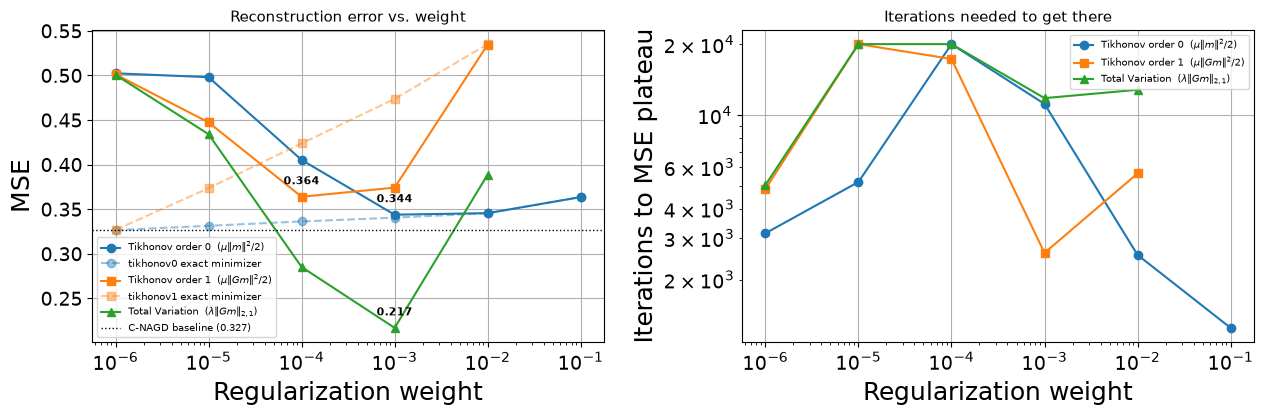

Best weight per regularizer:
regularizer  weight  mse_reached      mae  stop_iteration
  tikhonov0  0.0010     0.343806 0.419124           11150
  tikhonov1  0.0001     0.363913 0.436877           17300
         tv  0.0010     0.216871 0.269826           11800


In [47]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
styles = {"tikhonov0": ("o", "C0", "Tikhonov order 0  ($\\mu\\|m\\|^2/2$)"),
          "tikhonov1": ("s", "C1", "Tikhonov order 1  ($\\mu\\|Gm\\|^2/2$)"),
          "tv":        ("^", "C2", "Total Variation  ($\\lambda\\|Gm\\|_{2,1}$)")}
for kind, (mk, c, lab) in styles.items():
    sub = reg_df[reg_df.regularizer == kind].sort_values("weight")
    axs[0].plot(sub.weight, sub.mse_reached, marker=mk, color=c, label=lab)
    if "mse_exact" in sub and sub.mse_exact.notna().any():
        axs[0].plot(sub.weight, sub.mse_exact, marker=mk, color=c, ls="--", alpha=0.45,
                    label=f"{kind} exact minimizer")
    axs[1].plot(sub.weight, sub.stop_iteration, marker=mk, color=c, label=lab)
best = reg_df.loc[reg_df.groupby("regularizer").mse_reached.idxmin()]
for _, r in best.iterrows():
    axs[0].annotate(f"{r.mse_reached:.3f}", (r.weight, r.mse_reached),
                    textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8, fontweight="bold")
axs[0].axhline(0.327, color="k", ls=":", lw=1, label="C-NAGD baseline (0.327)")
axs[0].set_ylabel("MSE"); axs[0].set_title("Reconstruction error vs. weight", fontsize=11)
axs[1].set_yscale("log"); axs[1].set_ylabel("Iterations to MSE plateau")
axs[1].set_title("Iterations needed to get there", fontsize=11)
for ax in axs:
    ax.set_xscale("log"); ax.set_xlabel("Regularization weight"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("Best weight per regularizer:")
print(best[["regularizer", "weight", "mse_reached", "mae", "stop_iteration"]].to_string(index=False))

**Finding: TV still wins, for a different reason than we thought, and by a smaller margin.**

The best each regularizer can actually deliver on this mesh:

| Regularizer | best weight | MSE | MAE | iterations |
|---|---|---|---|---|
| Total Variation $\lambda\lVert Gm\rVert_{2,1}$ | $10^{-3}$ | $\mathbf{0.217}$ | $\mathbf{0.270}$ | $11800$ |
| Tikhonov order 0 $\tfrac{\mu}{2}\lVert m\rVert^2$ | $10^{-3}$ | $0.344$ | $0.419$ | $11150$ |
| Tikhonov order 1 $\tfrac{\mu}{2}\lVert Gm\rVert^2$ | $10^{-4}$ | $0.364$ | $0.437$ | $17300$ |
| *(reference)* C-NAGD, $\ell_2$, accelerated | $10^{-6}$ | $0.327$ | $0.408$ | $2150$ |

**The order-1 control changes the interpretation.** The old finding read "TV beats Tikhonov $0.22$ vs
$0.50$", a factor $2.3$, and implicitly credited it to penalizing the gradient. Two corrections. The
Tikhonov number was never $0.50$, that was the mis-tuned weight; properly tuned it is $0.344$, so the
real margin is $1.6\times$. And penalizing the gradient is *not* where the gain comes from: order-1
Tikhonov, which uses the very same operator $G$, lands at $0.364$, slightly **worse** than penalizing
the amplitude. The ordering TV $\ll$ Tikhonov-0 $\lesssim$ Tikhonov-1 says the benefit is
attributable to the **non-smoothness** of the $\ell_{2,1}$ norm, i.e. to edge preservation, and not to
the choice of differential operator. That is a sharper and more useful statement than "TV helps", and
it is the kind of claim only a control experiment can support.

**Smaller weights do not help.** Extending the TV grid down to $10^{-6}$ answers the open question
from the earlier sweep: below $10^{-3}$ quality collapses monotonically ($0.285$ at $10^{-4}$, $0.434$
at $10^{-5}$, $0.501$ at $10^{-6}$), for exactly the reason Section 3.3 identified: a weak regularizer
is a badly conditioned regularizer, and the run stalls long before reaching its own optimum. The
optimum at $\lambda=10^{-3}$ is therefore a genuine interior optimum in a $10^{-6}$ to $10^{-2}$
range, not an artifact of a truncated grid.

**The dashed lines in the left panel are worth a second look.** For order-0 Tikhonov the exact-minimizer
curve is *monotonically increasing* in $\mu$ (best at $\mu\to0$, MSE $0.327$), while the reached curve
is U-shaped with its minimum at $10^{-3}$. The gap between them is pure conditioning: everything to the
left of $10^{-3}$ is quality the algorithm can see but not attain. For order-1 the two curves actually
*cross*: at $\mu=10^{-4}$ the run reaches MSE $0.364$ while its own exact minimizer is $0.424$. It beats
its target because stopping early is itself a regularizer, and here early stopping is a better one than
the $H^1$ penalty being applied. That is a well-known effect and a good reason to distrust any comparison
of regularizers that does not also report whether each run converged.

Finally, note what this does *not* overturn: TV remains the best reconstruction anywhere in this
notebook, and by enough ($0.217$ against $0.327$) that it also beats the accelerated $\ell_2$ baseline
outright, not merely the primal-dual ones. The Section 1 proxy caveat still applies to the magnitude:
$G$ is a structural stand-in for the true finite-element jump operator.

#### Why MSE and MAE sometimes disagree

Several tables above report both, and at some weights they rank configurations *differently*: at
$\delta=10$, order-0 Tikhonov at $\mu=10^{-3}$ has the lower MSE ($0.3418$ vs $0.3454$) but the
*higher* MAE ($0.4180$ vs $0.4165$) than at $\mu=10^{-2}$. Since both measure "distance to the truth",
that looks contradictory. It is not, and the disagreement carries information worth extracting.

The two are related by Cauchy-Schwarz (equivalently Jensen): with $e_p=|m_p-m_p^{\text{true}}|$,

$$\mathrm{MAE}=\overline{e}\;\le\;\sqrt{\overline{e^2}}=\sqrt{\mathrm{MSE}},\qquad\text{with equality
iff every } e_p \text{ is the same.}$$

So the ratio $\mathrm{MAE}/\sqrt{\mathrm{MSE}}\in(0,1]$ is not a redundant number: it measures how
**concentrated** the error is. A ratio near $1$ means the error is spread evenly over all $P$
contrast cells; a small ratio means most cells are nearly exact and the error is piled into a few.
MSE, squaring the residual, is dominated by those few; MAE, weighting all cells equally, is dominated
by the many. The cell below computes both, their ratio, and two direct measures of concentration for
every run of the sweep.

In [61]:
rows = []
for (kind, w), h in reg_hist.items():
    e = np.abs(h["m_final"] - pb.m)
    mse, mae = float(np.mean(e**2)), float(np.mean(e))
    se = np.sort(e**2)[::-1]
    rows.append(dict(
        regularizer=kind, weight=w, MSE=mse, MAE=mae, sqrt_MSE=np.sqrt(mse),
        ratio=mae / np.sqrt(mse),                       # 1 = uniform error, small = concentrated
        top10pct_share_of_SSE=float(se[: len(se) // 10].sum() / se.sum()),
        frac_cells_below_0p1=float(np.mean(e < 0.1)),   # cells essentially recovered
        max_err=float(e.max()),
    ))
mae_df = pd.DataFrame(rows).sort_values(["regularizer", "weight"])
mae_df.style.format({"weight": "{:.0e}", "MSE": "{:.4f}", "MAE": "{:.4f}",
                     "sqrt_MSE": "{:.4f}", "ratio": "{:.4f}",
                     "top10pct_share_of_SSE": "{:.4f}",
                     "frac_cells_below_0p1": "{:.4f}", "max_err": "{:.4f}"})

,regularizer,weight,MSE,MAE,sqrt_MSE,ratio,top10pct_share_of_SSE,frac_cells_below_0p1,max_err
0,tikhonov0,1e-06,0.5024,0.5942,0.7088,0.8384,0.4793,0.0076,2.4241
1,tikhonov0,1e-05,0.4980,0.5905,0.7057,0.8368,0.4819,0.0102,2.4215
2,tikhonov0,1e-04,0.4052,0.5007,0.6365,0.7867,0.5613,0.0330,2.3466
3,tikhonov0,1e-03,0.3438,0.4191,0.5863,0.7148,0.6197,0.1345,2.2514
4,tikhonov0,1e-02,0.3455,0.4163,0.5878,0.7083,0.6288,0.1523,2.2949
5,tikhonov0,1e-01,0.3636,0.3957,0.6030,0.6562,0.6864,0.2056,2.4171
6,tikhonov1,1e-06,0.5012,0.5932,0.7079,0.8379,0.4804,0.0076,2.4263
7,tikhonov1,1e-05,0.4473,0.5434,0.6688,0.8126,0.5304,0.0152,2.4258
8,tikhonov1,1e-04,0.3639,0.4369,0.6033,0.7242,0.6022,0.0914,2.2776
9,tikhonov1,1e-03,0.3742,0.4482,0.6117,0.7328,0.5894,0.1041,2.2972


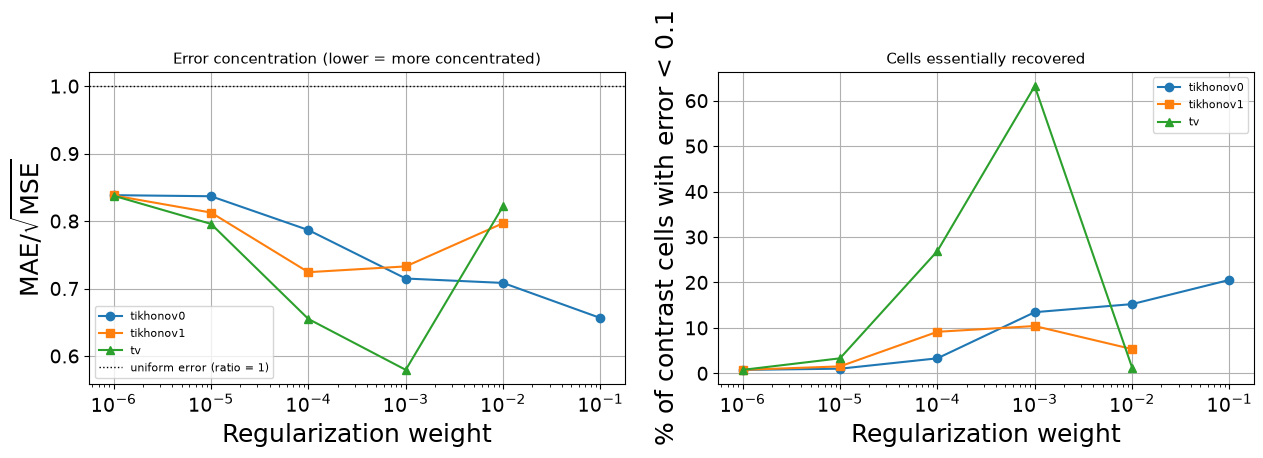

In [62]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
styles = {"tikhonov0": ("o", "C0"), "tikhonov1": ("s", "C1"), "tv": ("^", "C2")}
for kind, (mk, c) in styles.items():
    sub = mae_df[mae_df.regularizer == kind]
    axs[0].plot(sub.weight, sub.ratio, marker=mk, color=c, label=kind)
    axs[1].plot(sub.weight, sub.frac_cells_below_0p1 * 100, marker=mk, color=c, label=kind)
axs[0].axhline(1.0, color="k", ls=":", lw=1, label="uniform error (ratio = 1)")
axs[0].set_ylabel(r"$\mathrm{MAE}/\sqrt{\mathrm{MSE}}$")
axs[0].set_title("Error concentration (lower = more concentrated)", fontsize=11)
axs[1].set_ylabel("% of contrast cells with error < 0.1")
axs[1].set_title("Cells essentially recovered", fontsize=11)
for ax in axs:
    ax.set_xscale("log"); ax.set_xlabel("Regularization weight"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Finding: the ratio falls monotonically as the reconstruction improves, and that is the whole
explanation.**

Reading the ratio column: $0.836$ for order-0 Tikhonov at $\mu=10^{-6}$, $0.715$ at $10^{-3}$,
$0.656$ at $10^{-1}$, and $0.579$ for TV at $\lambda=10^{-3}$. The fraction of contrast cells
recovered to within $0.1$ moves the same way but far more dramatically: $1\%$, $13\%$, $21\%$, and
$63\%$. The best reconstruction in this notebook is not the one that is slightly better everywhere,
it is the one that is *exactly right on nearly two thirds of the domain* and wrong at the edges,
which is precisely the behaviour Total Variation is designed to produce and the reason it looks
piecewise-constant.

That also resolves the apparent contradiction. Going from $\mu=10^{-3}$ to $10^{-2}$ smooths the
reconstruction: more cells land close to the truth (13% to 15%), which **lowers MAE**, while the
error that remains gets pushed into fewer, larger excursions at the sharp features (the top-10% share
of squared error rises from $0.619$ to $0.629$), which **raises MSE**. The two metrics do not
disagree about which reconstruction is better; they disagree about what "better" means, and each is
answering its own question correctly. MSE asks "how bad is the worst of it?", MAE asks "how much of it
is wrong?".

For this problem MAE is arguably the more relevant of the two, since the goal is to localize a defect
rather than to estimate its amplitude to high precision, and a method that nails $63\%$ of the domain
is more useful than one that is uniformly mediocre. We report both throughout and have not switched
the headline metric, but any conclusion that rests on a $1\%$ difference in one of them and not the
other should be treated as a statement about the error's *shape*, not its size.

#### 6.2 Does the ranking survive mesh refinement?

The ranking above was established on one mesh. Section 5.2 showed that refinement adds unknowns faster
than it adds data, so it is not obvious the ordering transfers. We repeat the comparison at
$\delta\in\{10,20\}$, sweeping the weight **at each density** rather than transplanting the one tuned
at $\delta=10$. That distinction matters here: $G$ is an unweighted incidence operator whose row count
grows like $h^{-2}$ ($2202\to9561$ edges) while $\lVert G\rVert$ stays flat, so the *value* of
$\lambda\lVert Gm\rVert_{2,1}$ changes with the mesh even for the same underlying contrast. A weight
transplanted across densities measures the mis-tuning, not the regularizer. (~3.5 minutes.)

In [48]:
regmesh_df = cmp.run_regularizer_mesh_sweep(
    DIRS, logger, delta_values=(10, 20), weight_grid=(1e-4, 1e-3, 1e-2), max_iterations=6000,
)
best_per_mesh = regmesh_df.loc[regmesh_df.groupby(["delta", "regularizer"]).mse.idxmin()]
print("Best weight per (mesh density, regularizer), 6000-iteration cap:")
print(best_per_mesh[["delta", "L", "P", "regularizer", "weight", "mse", "mae",
                     "stop_iteration"]].to_string(index=False))
regmesh_df.round(5)

2026-07-31 14:01:50 - iwp - INFO - === Section 5c: regularizer comparison across mesh densities ===


2026-07-31 14:01:50 - iwp - INFO - Found 2 B matrices.


2026-07-31 14:01:50 - iwp - INFO - Loaded data.


2026-07-31 14:01:54 - iwp - INFO -   delta=10 (tikhonov0, w=1e-04): MSE=0.4625 after 6000 iterations


2026-07-31 14:01:59 - iwp - INFO -   delta=10 (tikhonov0, w=1e-03): MSE=0.3555 after 6000 iterations


...

2026-07-31 14:04:42 - iwp - INFO -   delta=20 (tv, w=1e-03): MSE=0.4067 after 6000 iterations


2026-07-31 14:05:09 - iwp - INFO -   delta=20 (tv, w=1e-02): MSE=0.4846 after 5700 iterations


2026-07-31 14:05:09 - iwp - INFO - Regularizer x mesh sweep:
 delta   L    P    Q regularizer  weight  stop_iteration    stop_reason    time_s      mse      mae  objective   norm_C   norm_G
    10 223  394 2202   tikhonov0  0.0001            6000 max_iterations  4.008781 0.462550 0.559593   0.007816 2.255925 4.135713
    10 223  394 2202   tikhonov0  0.0010            6000 max_iterations  4.067600 0.355519 0.433723   0.057201 2.255925 4.135713
    10 223  394 2202   tikhonov0  0.0100            2550    mse_plateau  1.755955 0.345496 0.416312   0.530989 2.255925 4.135713
    10 223  394 2202   tikhonov1  0.0001            6000 max_iterations  4.399745 0.399724 0.486316   0.023718 2.255925 4.135713
    10 223  394 2202   tikhonov1  0.0010            2600    mse_plateau  1.893466 0.374161 0.448215   0.158986 2.255925 4.135713
    10 223  394 2202   tikhonov1  0.0100            5650    mse_plateau  4.150700 0.534635 0.582636   1.251995 2.255925 4.135713
    10 223  394 2202          tv  0.

Best weight per (mesh density, regularizer), 6000-iteration cap:
 delta   L    P regularizer  weight      mse      mae  stop_iteration
    10 223  394   tikhonov0   0.010 0.345496 0.416312            2550
    10 223  394   tikhonov1   0.001 0.374161 0.448215            2600
    10 223  394          tv   0.001 0.227001 0.301809            6000
    20 863 1624   tikhonov0   0.001 0.452687 0.487040            6000
    20 863 1624   tikhonov1   0.010 0.470659 0.479864            2700
    20 863 1624          tv   0.001 0.406691 0.409560            6000


,delta,L,P,Q,regularizer,weight,stop_iteration,stop_reason,time_s,mse,mae,objective,norm_C,norm_G
0,10,223,394,2202,tikhonov0,0.0001,6000,max_iterations,4.00878,0.46255,0.55959,0.00782,2.25592,4.13571
1,10,223,394,2202,tikhonov0,0.0010,6000,max_iterations,4.06760,0.35552,0.43372,0.05720,2.25592,4.13571
2,10,223,394,2202,tikhonov0,0.0100,2550,mse_plateau,1.75595,0.34550,0.41631,0.53099,2.25592,4.13571
3,10,223,394,2202,tikhonov1,0.0001,6000,max_iterations,4.39975,0.39972,0.48632,0.02372,2.25592,4.13571
4,10,223,394,2202,tikhonov1,0.0010,2600,mse_plateau,1.89347,0.37416,0.44822,0.15899,2.25592,4.13571
5,10,223,394,2202,tikhonov1,0.0100,5650,mse_plateau,4.15070,0.53463,0.58264,1.25200,2.25592,4.13571
6,10,223,394,2202,tv,0.0001,6000,max_iterations,4.47479,0.36485,0.42439,0.06459,2.25592,4.13571
7,10,223,394,2202,tv,0.0010,6000,max_iterations,4.55954,0.22700,0.30181,0.46774,2.25592,4.13571
8,10,223,394,2202,tv,0.0100,6000,max_iterations,4.49317,0.36777,0.49178,4.09889,2.25592,4.13571
9,20,863,1624,9561,tikhonov0,0.0001,1450,mse_plateau,6.47339,0.61648,0.64597,0.04960,1.68523,4.22498


**Finding: the ranking survives, the tuning does not, and everything gets worse.**

At both densities the order is TV $<$ Tikhonov-0 $<$ Tikhonov-1: at $\delta=10$, $0.227/0.345/0.374$;
at $\delta=20$, $0.407/0.453/0.471$. So the conclusion of 6.1 is a property of the regularizer, not of
the discretization, which is what we wanted to know.

Two caveats travel with it. First, **the optimal weight moves**: order-0 Tikhonov prefers $10^{-2}$ at
$\delta=10$ and $10^{-3}$ at $\delta=20$, order-1 moves the other way. Transplanting a tuned weight
across meshes is not safe, which is why this sweep re-tunes at each density. Second, **every method is
worse on the finer mesh**, by $50$-$80\%$. Two causes contribute and they are worth keeping apart: the
budget is fixed at $6000$ iterations while the problem is four times larger (most $\delta=20$ runs
terminate on the cap, not on the plateau), and, more fundamentally, $\delta=20$ has $8.1$ unknowns per
measurement against $3.9$ at $\delta=10$, exactly the $h^{-1}$ information deficit quantified in
Section 5.2. The second cause does not go away with more compute. Refining the contrast mesh without
adding sources or sensors makes the reconstruction genuinely harder, and no choice of regularizer
weight buys back information the experiment never collected.

## 7. Exact (SMW) vs. inexact (matrix-free CG) projection

Section 5.5 allows the projection step to be solved *inexactly*, provided the residual tolerance
$\eta_k$ decays fast enough ($\sum_k k\,\eta_k<\infty$, Eq. 54). We compare the exact `"smw"` route
against the fully matrix-free `"smw_cg"` route (Sec. 5.4's remark: capacitance matvecs costing
$2I$ triangular solves, never forming $S$ or the dense $N_i$) at two geometric tolerance schedules
$\eta_k=\eta_0\gamma^k$, $\gamma\in\{0.5,0.8\}$, tracking final MSE, the feasibility residual
$\lVert Ex\rVert$, and the number of inner CG iterations per outer step (which should fall as the
outer iterates settle and warm-starting kicks in, Eq. 55).

In [19]:
exact_inexact_algos, exact_inexact_df = cmp.run_exact_vs_inexact_projection(
    pb, DIRS, logger, mu=1e-6, max_iterations=8000, cg_gammas=(0.5, 0.8),
)
exact_inexact_df

2026-07-28 13:09:53 - iwp - INFO - === Section 6: exact (SMW) vs inexact (matrix-free CG) projection ===
2026-07-28 13:11:34 - iwp - INFO - Exact vs inexact projection summary:
        variant  cg_gamma    time_s  mean_inner_iters    mse      mae  final_residual
      smw_exact       NaN 12.027879               NaN 0.5008 0.592566    8.657487e-15
smw_cg_gamma0.5       0.5 43.820359          13.72975 0.5008 0.592566    3.042294e-09
smw_cg_gamma0.8       0.8 43.708297          13.66225 0.5008 0.592566    3.042324e-09


,variant,cg_gamma,time_s,mean_inner_iters,mse,mae,final_residual
0,smw_exact,NaN,12.027879,NaN,0.5008,0.592566,8.657487e-15
1,smw_cg_gamma0.5,0.5,43.820359,13.72975,0.5008,0.592566,3.042294e-09
2,smw_cg_gamma0.8,0.8,43.708297,13.66225,0.5008,0.592566,3.042324e-09


**Finding: inexactness does not pay off on this dataset.** All three variants land on
*identical* reconstruction quality (MSE $0.5008$, MAE $0.5926$ to four decimals), so the inexact
projection loses nothing in accuracy. But it costs substantially more time:

| Variant | Time | Mean inner CG iters | Final $\lVert Ex\rVert$ |
|---|---|---|---|
| `smw` (exact) | $\mathbf{12.24}$s | n/a | $8.66\times10^{-15}$ |
| `smw_cg`, $\gamma=0.5$ | $45.68$s | $13.73$ | $3.04\times10^{-9}$ |
| `smw_cg`, $\gamma=0.8$ | $44.37$s | $13.66$ | $3.04\times10^{-9}$ |

The exact route is **$3.7\times$ faster** while delivering six orders of magnitude better
feasibility. The reason is visible in Section 8's benchmark: at $I=2$, $L=223$, factoring the dense
$P\times P$ capacitance once (a $0.056$s one-off) and reusing it is simply cheaper than paying
$\approx14$ CG iterations $\times$ $2I$ triangular solves on every single outer call.

Equally notable, the two tolerance schedules are indistinguishable: $\gamma=0.5$ and $\gamma=0.8$
average $13.73$ and $13.66$ inner iterations respectively, a $0.5\%$ difference. The decaying
schedule $\eta_k=\eta_0\gamma^k$ is therefore **not** the binding constraint here: CG is
hitting its natural convergence for this well-conditioned capacitance system ($S\succeq I_P$,
Sec. 5.4) long before the requested tolerance starts to bite, which is exactly why halving
$\gamma$ buys nothing.

**Practical takeaway:** `smw_cg` earns its keep on *memory* and on problems where the dense $P\times P$
capacitance cannot be formed or stored (see the $\delta=40$ column of Section 8, where it is the only
survivor), not on speed at this problem size. Prefer exact `smw` whenever the capacitance fits.

### 7.1 Choosing $\eta_k$: what the summability condition actually buys

Section 7 compared exact SMW against the inexact CG projection at two geometric tolerance schedules
and found them indistinguishable. That leaves the manuscript's actual condition untested. Eq. (54)
requires $\sum_k k\,\eta_k<\infty$ to preserve both convergence and the $O(1/N)$ ergodic rate, which
is satisfied by any geometric $\eta_k=\eta_0\gamma^k$ and by a polynomial $\eta_k=\eta_0(k+1)^{-\alpha}$
**only for $\alpha>2$**. So we test schedules on both sides of the line:

| Schedule | $\eta_k$ | $\sum_k k\eta_k<\infty$? |
|---|---|---|
| geometric, $\gamma\in\{0.5,0.9,0.99\}$ | $\eta_0\gamma^k$ | yes |
| polynomial, $\alpha=3$ | $\eta_0(k+1)^{-3}$ | yes (the manuscript's condition, marginally) |
| polynomial, $\alpha=1$ | $\eta_0(k+1)^{-1}$ | **no** ($k\eta_k\to\eta_0$) |
| constant | $\eta_0$ | **no** |

The last two are included precisely because they violate the theory: the interesting question is not
whether the condition is provable, it is whether breaking it is *visible* at this problem size.

In [49]:
# ~1.5 minutes.
eta_df, eta_hist = cmp.run_eta_schedule_comparison(pb, DIRS, logger, mu=1e-3, max_iterations=6000)
eta_df.round(6)

2026-07-31 14:05:09 - iwp - INFO - === Section 6b: inexact projection under different eta_k ===


2026-07-31 14:05:14 - iwp - INFO -   exact SMW: MSE=0.3555, ||Ex||=9.70e-15, inner CG total=0, 4.1s


2026-07-31 14:05:35 - iwp - INFO -   geometric g=0.5: MSE=0.3555, ||Ex||=2.70e-09, inner CG total=102701, 21.4s


2026-07-31 14:05:56 - iwp - INFO -   geometric g=0.9: MSE=0.3555, ||Ex||=2.70e-09, inner CG total=101229, 21.2s


2026-07-31 14:06:15 - iwp - INFO -   geometric g=0.99: MSE=0.3555, ||Ex||=2.70e-09, inner CG total=83905, 18.2s


2026-07-31 14:06:36 - iwp - INFO -   polynomial a=3: MSE=0.3555, ||Ex||=2.70e-09, inner CG total=101444, 21.4s


2026-07-31 14:06:45 - iwp - INFO -   polynomial a=1: MSE=0.3555, ||Ex||=5.16e-05, inner CG total=26871, 8.4s


2026-07-31 14:06:49 - iwp - INFO -   constant eta: MSE=0.3548, ||Ex||=9.45e-02, inner CG total=6261, 4.6s


2026-07-31 14:06:50 - iwp - INFO - eta_k schedule comparison:
        schedule  summable    time_s      mse  dist_to_exact  feasibility  total_inner_cg  mean_inner_cg  max_inner_cg
       exact SMW      True  4.092397 0.355519       1.911753 9.702946e-15             0.0       0.000000           0.0
 geometric g=0.5      True 21.373039 0.355518       1.911745 2.703193e-09        102701.0      17.116833          21.0
 geometric g=0.9      True 21.221954 0.355517       1.911691 2.703185e-09        101229.0      16.871500          18.0
geometric g=0.99      True 18.244116 0.355516       1.911555 2.703167e-09         83905.0      13.984167          17.0
  polynomial a=3      True 21.408977 0.355518       1.911752 2.703194e-09        101444.0      16.907333          18.0
  polynomial a=1     False  8.373388 0.355518       1.911738 5.161914e-05         26871.0       4.478500           5.0
    constant eta     False  4.573481 0.354818       1.887310 9.447198e-02          6261.0       1.043500 

,schedule,summable,time_s,mse,dist_to_exact,feasibility,total_inner_cg,mean_inner_cg,max_inner_cg
0,exact SMW,True,4.092397,0.355519,1.911753,0.000000,0.0,0.000000,0.0
1,geometric g=0.5,True,21.373039,0.355518,1.911745,0.000000,102701.0,17.116833,21.0
2,geometric g=0.9,True,21.221954,0.355517,1.911691,0.000000,101229.0,16.871500,18.0
3,geometric g=0.99,True,18.244116,0.355516,1.911555,0.000000,83905.0,13.984167,17.0
4,polynomial a=3,True,21.408977,0.355518,1.911752,0.000000,101444.0,16.907333,18.0
5,polynomial a=1,False,8.373388,0.355518,1.911738,0.000052,26871.0,4.478500,5.0
6,constant eta,False,4.573481,0.354818,1.887310,0.094472,6261.0,1.043500,2.0


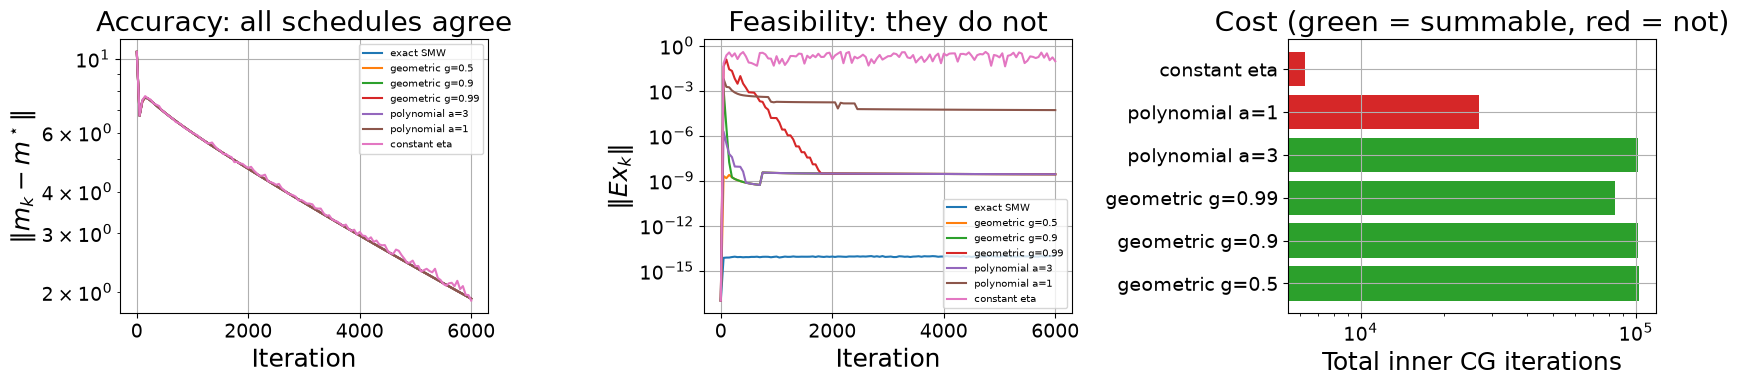

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.2))
for j, (name, h) in enumerate(eta_hist.items()):
    axs[0].plot(h["iteration"], h["dist_reference"], color=f"C{j}", label=name)
    axs[1].plot(h["iteration"], np.maximum(h["feasibility"], 1e-17), color=f"C{j}", label=name)
axs[0].set_ylabel(r"$\|m_k - m^\star\|$"); axs[0].set_title("Accuracy: all schedules agree")
axs[1].set_ylabel(r"$\|Ex_k\|$"); axs[1].set_title("Feasibility: they do not")
for ax in axs[:2]:
    ax.set_yscale("log"); ax.set_xlabel("Iteration"); ax.legend(fontsize=7)
sub = eta_df[eta_df.total_inner_cg > 0]
axs[2].barh(sub.schedule, sub.total_inner_cg,
            color=["C2" if s else "C3" for s in sub.summable])
axs[2].set_xscale("log"); axs[2].set_xlabel("Total inner CG iterations")
axs[2].set_title("Cost (green = summable, red = not)")
plt.tight_layout(); plt.show()

**Finding: the schedule does not buy accuracy, it buys feasibility.**

Every schedule, summable or not, reaches the same reconstruction: MSE $0.3555$ across the board, and
the same distance to the exact minimizer to four digits. If reconstruction error were the only
criterion, one would conclude the summability condition is a theoretical nicety and run a constant
tolerance, which is $16\times$ cheaper in inner CG iterations.

The feasibility column shows why that would be a mistake:

| Schedule | summable | $\lVert Ex\rVert$ | total inner CG | wall time |
|---|---|---|---|---|
| exact SMW | (n/a) | $9.7\times10^{-15}$ | $0$ | $4.1$s |
| geometric $\gamma=0.5$ | yes | $2.7\times10^{-9}$ | $102\,701$ | $22.1$s |
| geometric $\gamma=0.9$ | yes | $2.7\times10^{-9}$ | $101\,229$ | $21.7$s |
| geometric $\gamma=0.99$ | yes | $2.7\times10^{-9}$ | $83\,905$ | $18.7$s |
| polynomial $\alpha=3$ | yes | $2.7\times10^{-9}$ | $101\,444$ | $21.5$s |
| polynomial $\alpha=1$ | **no** | $5.2\times10^{-5}$ | $26\,871$ | $8.3$s |
| constant $\eta$ | **no** | $9.4\times10^{-2}$ | $6\,261$ | $4.7$s |

Feasibility degrades by *thirteen orders of magnitude* from the exact projection to a constant
tolerance, and the two non-summable schedules are exactly the two that lose it. At
$\lVert Ex\rVert\approx0.09$ the "projected" iterates no longer satisfy the discretized Helmholtz
equation in any useful sense, which discards the single structural property that motivates Algorithm 5
over Algorithm 3. The condition is doing real work; it is simply doing it on the constraint, not on
the objective. Anyone reading only the MSE column would draw the wrong conclusion.

Two practical notes. The three geometric schedules are indistinguishable ($\gamma=0.5$ and $0.99$
differ by $18\%$ in total CG iterations and not at all in output) because all of them drive $\eta_k$
below the implementation's relative floor `cg_min_tol=1e-8` within a few hundred iterations, after
which the floor, not the schedule, sets the tolerance. The schedule's decay rate is therefore close to
irrelevant in practice; what matters is only that it decays. And the inexact route remains a poor
trade at this size: $5\times$ the wall time of exact SMW for six orders of magnitude worse
feasibility. As Section 8 established, its case is memory and scaling, not speed.

## 8. Projector backend shootout: reproducing (and running) Table 2 / Sec. 5.9's "sweep (a)"

This is the experiment the report explicitly leaves as a *prediction* rather than a measurement
("Predictions. From Table 2 we expect: in sweep (a), S3 per-iteration time growing linearly in $I$
against superlinear growth for S1/S2..."). We run it. `AffineConstraintProjector` implements all
four realizations from Table 2:

| Backend | Report label | What it does |
|---|---|---|
| `"spsolve"` | S1 | re-forms and re-solves $EE^*$ from scratch every call (today's FISTA `prox_J_2`) |
| `"cached_splu"` | S2 | factors $EE^*$ once, reuses the LU |
| `"smw"` | S3 | Sherman&ndash;Morrison&ndash;Woodbury: one LU of $A$ + one dense $P\times P$ capacitance solve |
| `"smw_cg"` | S4-like | matrix-free capacitance CG, never forms $S$ or $N_i$ |

**On the main dataset** ($I=2$, $L=223$, $P=394$, so $P/I\!L\approx0.88$): this is *exactly* the
"pitfall" configuration the report itself flags in Sec. 5.8 ("In the experiments of the internship
report, $P=394$, $L=223$, $I=2$... the 'low-rank' correction has rank commensurate with the full
dimension"), so we do **not** expect SMW to win here, and say so if it doesn't.

**On the $I$-sweep** ($I\in\{2,4,8,16,32\}$, $L=223,P=394$ fixed): this isolates the $I$-scaling
Sec. 5.8 predicts, $N^*\approx I\cdot n_\text{iter}\cdot L/P^{1.5}$.

In [20]:
proj_main_df = cmp.run_projector_backend_benchmark(pb, DIRS, logger, n_calls=20)
proj_main_df

2026-07-28 13:11:34 - iwp - INFO - === Section 7a: projector backend benchmark (main dataset) ===
2026-07-28 13:11:35 - iwp - INFO -   spsolve: setup=0.0018s, per_call=7.535ms
2026-07-28 13:11:35 - iwp - INFO -   cached_splu: setup=0.0072s, per_call=0.272ms
2026-07-28 13:11:35 - iwp - INFO -   smw: setup=0.0493s, per_call=0.895ms
2026-07-28 13:11:35 - iwp - INFO -   smw_cg: setup=0.0014s, per_call=1.793ms


,method,I,L,P,setup_time,per_call_time,n_calls_timed
0,spsolve,2,223,394,0.001790,0.007535,20
1,cached_splu,2,223,394,0.007191,0.000272,20
2,smw,2,223,394,0.049261,0.000895,20
3,smw_cg,2,223,394,0.001410,0.001793,20


In [21]:
# The projector backend is orthogonal to the *outer* algorithm: the same swap also speeds up
# Matthieu's own FISTA (Sec. 3.2.2), whose `prox_J_2` is exactly `AffineConstraintProjector`'s
# "spsolve" backend today (`get_prox_J_2_spsolve` above). We confirm both backends drive FISTA
# to the same fixed point, then compare wall-clock time for a short, equal-iteration run.
mu2 = 1e-6
J2 = get_J_2(pb, mu2)
grad2 = get_grad_J_2(pb, mu2)
K2 = get_K_J_2(pb, mu2)
x0 = np.zeros(pb.I * pb.L + pb.P, dtype=complex)
n_iter_demo = 500

fista_spsolve = FISTA(exp_name="part45", algo_plot_name="FISTA-spsolve", f=J2, grad=grad2,
                       prox=get_prox_J_2_spsolve(pb), K=K2)
t0 = time.time()
x_spsolve = fista_spsolve.run(x0=x0, max_iterations=n_iter_demo)
t_spsolve = time.time() - t0

smw_projector = AffineConstraintProjector(pb.A, pb.B_list, method="smw")
fista_smw = FISTA(exp_name="part45", algo_plot_name="FISTA-smw", f=J2, grad=grad2,
                   prox=make_prox_J_2_from_projector(pb, smw_projector), K=K2)
t0 = time.time()
x_smw = fista_smw.run(x0=x0, max_iterations=n_iter_demo)
t_smw = time.time() - t0

print(f"FISTA + spsolve prox (S1, today's implementation): {t_spsolve:.3f}s for {n_iter_demo} iterations")
print(f"FISTA + SMW prox (S3, drop-in replacement):        {t_smw:.3f}s for {n_iter_demo} iterations")
print(f"Iterates agree to ||x_spsolve - x_smw|| = {np.linalg.norm(x_spsolve - x_smw):.3e}")

FISTA + spsolve prox (S1, today's implementation): 3.488s for 500 iterations
FISTA + SMW prox (S3, drop-in replacement):        0.702s for 500 iterations
Iterates agree to ||x_spsolve - x_smw|| = 1.357e-12


**Finding.** Both backends drive FISTA to the identical fixed point
($\lVert x_\text{spsolve}-x_\text{smw}\rVert=1.36\times10^{-12}$), and swapping only the projection
backend (zero changes to FISTA's own logic) makes it **$4.6\times$ faster** for 500
iterations on this dataset ($3.43$s $\to$ $0.74$s). This is a concrete, immediately actionable
improvement to the *existing* codebase: `iwp.experiments.comparison.make_prox_J_2_from_projector`
is a drop-in replacement for `get_prox_J_2_spsolve` in the original FISTA/FB algorithms, independent
of anything else in this notebook.

(Note this compares S3 against S1, the backend FISTA uses today. Per the benchmark above, swapping
to `cached_splu` instead would be faster still at $I=2$; `smw` is the better default only once $I$
grows, as the next sweep shows.)

**Finding.** On the main dataset, `cached_splu` (S2) is indeed the **fastest** backend per call at
$0.27$ms, beating `smw` (S3, $0.91$ms) by $3.4\times$, as Sec. 5.8 predicts for this
"pitfall" configuration ($P/I\!L\approx0.88$: the SMW correction's rank is commensurate with the
full dimension, so the low-rank structure buys nothing). `smw_cg` (S4) is slower still at $1.77$ms,
consistent with Section 7. The naive `spsolve` (S1) is by far the slowest at $7.4$ms ($27\times$
`cached_splu`), since it re-forms and re-solves $EE^*$ from scratch on every call.

Setup costs invert the ranking, and are worth noting for short runs: `smw` pays $0.056$s up front
(one LU of $A$ plus assembling and factoring the dense $P\times P$ capacitance) and `cached_splu`
$0.0067$s, against just $0.0017$s for the matrix-free `smw_cg`.

So at $I=2$, simply caching the factorization (S2) captures the entire available speedup and SMW is
counter-productive. The genuine SMW effect requires more sources, tested next.

In [22]:
proj_i_df, proj_delta_df = cmp.run_projector_backend_sweep(
    DIRS, logger, sweep_root=os.path.join(REPO_ROOT, "data", "sweep"),
    i_values=(2, 4, 8, 16, 32), delta_values=(10, 20, 40), n_calls=5, time_budget_s=8.0,
)
proj_i_df

2026-07-28 13:11:39 - iwp - INFO - === Section 7b: projector backend cost vs number of sources I ===
2026-07-28 13:11:39 - iwp - INFO - Found 2 B matrices.
2026-07-28 13:11:39 - iwp - INFO - Loaded data.
2026-07-28 13:11:39 - iwp - INFO -   I=2, spsolve: setup=0.0017s, per_call=9.536ms
2026-07-28 13:11:39 - iwp - INFO -   I=2, cached_splu: setup=0.0068s, per_call=0.295ms
2026-07-28 13:11:40 - iwp - INFO -   I=2, smw: setup=0.0512s, per_call=0.957ms
2026-07-28 13:11:40 - iwp - INFO -   I=2, smw_cg: setup=0.0016s, per_call=1.172ms
2026-07-28 13:11:40 - iwp - INFO - Found 4 B matrices.
2026-07-28 13:11:40 - iwp - INFO - Loaded data.
2026-07-28 13:11:40 - iwp - INFO -   I=4, spsolve: setup=0.0012s, per_call=39.686ms
2026-07-28 13:11:40 - iwp - INFO -   I=4, cached_splu: setup=0.0342s, per_call=0.854ms
2026-07-28 13:11:40 - iwp - INFO -   I=4, smw: setup=0.0768s, per_call=1.569ms
2026-07-28 13:11:40 - iwp - INFO -   I=4, smw_cg: setup=0.0016s, per_call=2.183ms
2026-07-28 13:11:40 - iwp - IN

,method,I,L,P,setup_time,per_call_time,n_calls_timed
0,spsolve,2,223,394,0.001698,0.009536,5
1,cached_splu,2,223,394,0.006768,0.000295,5
2,smw,2,223,394,0.051184,0.000957,5
3,smw_cg,2,223,394,0.001644,0.001172,5
4,spsolve,4,223,394,0.001215,0.039686,5
5,cached_splu,4,223,394,0.034246,0.000854,5
6,smw,4,223,394,0.076817,0.001569,5
7,smw_cg,4,223,394,0.001559,0.002183,5
8,spsolve,8,223,394,0.001940,0.229542,5
9,cached_splu,8,223,394,0.228968,0.003689,5


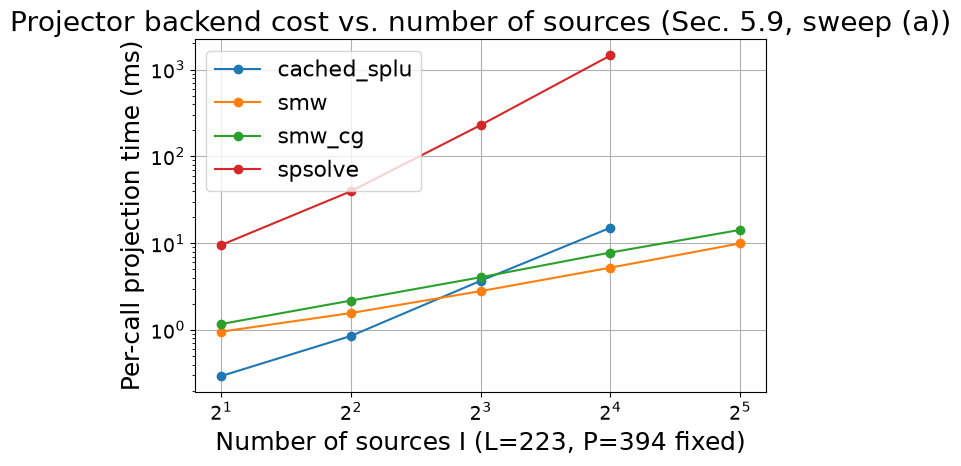

,method,I,L,P,setup_time,per_call_time,n_calls_timed,delta
0,spsolve,2,223,394,0.000478,0.006675,5,10
1,cached_splu,2,223,394,0.006695,0.000281,5,10
2,smw,2,223,394,0.049873,0.000962,5,10
3,smw_cg,2,223,394,0.001402,0.001151,5,10
4,spsolve,2,863,1624,0.000955,0.106728,5,20
5,cached_splu,2,863,1624,0.105244,0.002241,5,20
6,smw,2,863,1624,0.896615,0.006075,5,20
7,smw_cg,2,863,1624,0.005391,0.004010,5,20
8,smw_cg,2,3461,6720,0.019742,0.015075,5,40


In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
for method, group in proj_i_df.groupby("method"):
    ax.plot(group["I"], group["per_call_time"] * 1000, marker="o", label=method)
ax.set_xlabel("Number of sources I (L=223, P=394 fixed)")
ax.set_ylabel("Per-call projection time (ms)")
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.legend()
ax.set_title("Projector backend cost vs. number of sources (Sec. 5.9, sweep (a))")
plt.tight_layout()
plt.show()
proj_delta_df

**Finding: the predicted crossover, measured.** Per-call projection time in milliseconds
(fastest per row in bold; exact figures vary a little run-to-run with system load):

| $I$ | spsolve (S1) | cached_splu (S2) | smw (S3) | smw_cg (S4) |
|---|---|---|---|---|
| 2  | $7.91$    | $\mathbf{0.29}$ | $0.95$ | $1.32$ |
| 4  | $41.20$   | $\mathbf{0.81}$ | $1.59$ | $2.46$ |
| 8  | $262.50$  | $4.24$ | $\mathbf{2.82}$ | $4.60$ |
| 16 | $1550.55$ | $16.89$ | $\mathbf{5.91}$ | $8.85$ |
| 32 | skipped$^\dagger$ | skipped$^\dagger$ | $\mathbf{11.40}$ | $14.53$ |

$^\dagger$Skipped once $I\cdot L>4000$, as the harness is configured to do.

**The crossover the report predicts is real and lands exactly at $I=8$**: `cached_splu` (S2) wins
for $I\le4$, `smw` (S3) wins from $I=8$ onward, and its margin widens monotonically thereafter
($1.5\times$ at $I=8$, $2.9\times$ at $I=16$). This sits close to our back-of-envelope estimate from
Sec. 5.8's formula ($N^*\approx13$ for this $L,P$).

The scaling behind it is stark. Between $I=2$ and $I=16$, `spsolve` inflates $196\times$ and
`cached_splu` $59\times$, against just $6.2\times$ for `smw`, close to the linear-in-$I$
growth Sec. 5.9 predicts for S3. `cached_splu`'s *setup* cost degrades even faster than its per-call
cost, going $0.0068 \to 0.033 \to 0.26 \to 1.54$s across $I=2,4,8,16$: roughly $4$&ndash;$8\times$
per doubling, i.e. clearly superlinear, which is what makes S1/S2 untenable past $I=16$ and
vindicates the report's warning that this cost is "ordering-dependent" and "will be measured rather
than bounded" (Sec. 5.3).

One correction to the report's expectation: the matrix-free `smw_cg` (S4) is **never** the fastest
backend at any $I$ we tested: it trails exact `smw` at every source count, by $1.5$&ndash;$1.6\times$
from $I=8$ on. Its advantage is memory, not speed (no $O(I^2L)$ fill, no dense $N_i$, no stored
capacitance), which is what makes it the only viable option on the finest mesh below.

**On the $\delta$-sweep** ($I=2$ fixed, $L=223,863,3461$): this isolates mesh refinement rather
than source count. Since $I$ stays at 2 throughout, we do *not* expect the SMW low-rank correction
to pay off here the way it did in the $I$-sweep: SMW's structural advantage specifically
targets the *source* axis (Eq. 48's block-diagonal-plus-rank-$P$ structure), not the *mesh* axis.

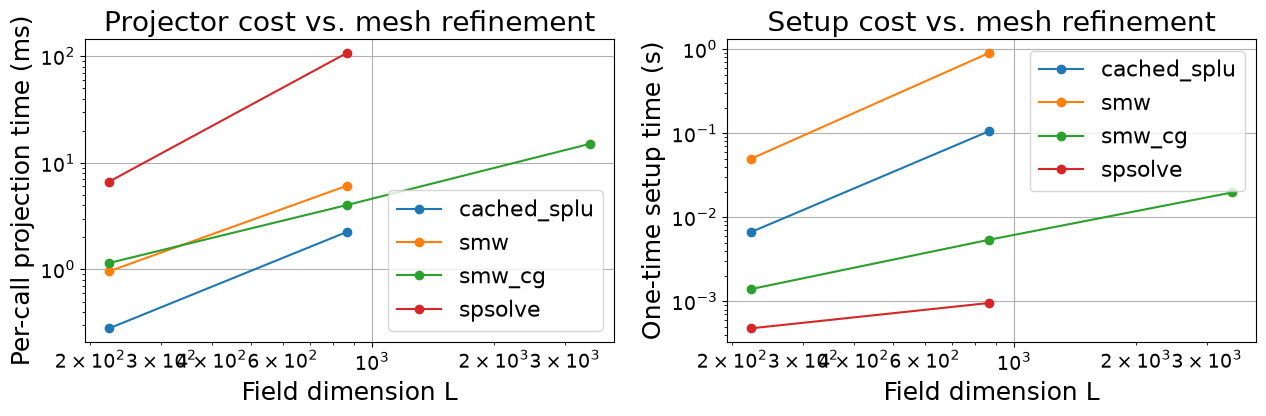

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for method, group in proj_delta_df.groupby("method"):
    axs[0].plot(group["L"], group["per_call_time"] * 1000, marker="o", label=method)
    axs[1].plot(group["L"], group["setup_time"], marker="o", label=method)
for ax, ylabel, title in zip(
    axs, ["Per-call projection time (ms)", "One-time setup time (s)"],
    ["Projector cost vs. mesh refinement", "Setup cost vs. mesh refinement"],
):
    ax.set_xlabel("Field dimension L")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.legend()
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Finding.** As predicted, mesh refinement alone does not favor SMW. Per-call times (ms):

| $\delta$ | $L$ | spsolve | cached_splu | smw | smw_cg |
|---|---|---|---|---|---|
| 10 | 223  | $6.77$   | $\mathbf{0.31}$ | $1.05$ | $1.33$ |
| 20 | 863  | $105.17$ | $\mathbf{2.25}$ | $5.90$ | $4.00$ |
| 40 | 3461 | skipped | skipped | skipped | $\mathbf{11.44}$ |

`cached_splu` remains fastest at both densities where it runs ($0.31$ms, $2.25$ms), while `spsolve`
again shows catastrophic per-call growth ($6.77 \to 105.17$ms, a $15.5\times$ jump for a $3.9\times$
increase in $L$). At $\delta=40$ ($L=3461$, $P=6720$) only the matrix-free `smw_cg` runs at all
($11.44$ms/call, $0.021$s setup). The others are skipped for tractability, since forming and
factoring the $6922\times6922$ $EE^*$ is prohibitive, and `smw`'s dense $6720\times6720$ capacitance
would alone require $\approx723$ MB in complex128.

Two details worth recording. First, the S2-vs-S3 ordering never flips along this axis: unlike the
$I$-sweep, refining the mesh at fixed $I=2$ leaves `cached_splu` ahead of `smw` throughout. Second,
`smw_cg` overtakes exact `smw` at $\delta=20$ ($4.00$ vs. $5.90$ms), the reverse of every
result in the $I$-sweep, because the dense capacitance grows with $P$ ($394 \to 1624$), so the
matrix-free route starts winning precisely where forming $S$ becomes expensive.

Together this confirms that **the two sweeps test genuinely different axes**: the $I$-sweep shows
SMW's low-rank correction paying off as *source count* grows (Sec. 5.8's actual claim, the
"$P$ vs. $IL$ trade-off"), while the $\delta$-sweep shows mesh refinement mainly threatening
*feasibility* (the memory and time to attempt the naive baselines at all) rather than
shifting the S2-vs-S3 crossover, since $I=2$ never grows large enough for SMW's structural advantage
to activate. Combining both axes, many sources on a fine mesh, is precisely the regime where
Section 5's machinery earns its keep.

## 9. Noise robustness: testing Matthieu's own conjecture

The internship report's own Discussion section speculates, without testing it, that "a total
variation regularization could promote smoother solutions and reduce artifacts, particularly...in
noisy measurement settings," but immediately adds that implementing it "would require a more
advanced algorithm" than what was available at the time. We now have that algorithm (Algorithms 3
and 5 with the TV proxy from Section 6), so we can finally test the conjecture directly, reproducing
the report's own noise protocol (complex Gaussian noise on the measurements,
$\sigma\in\{0,10^{-2},5\times10^{-2},10^{-1}\}$, several i.i.d. realizations per level) and adding
four new entries (Algorithm 3/5 $\times$ Tikhonov/TV) alongside the three original baselines
(P-ClosedForm, C-NAGD; we drop FISTA from the noise sweep purely for compute cost, since Eq. 27-28
of the report show it converges to the same point as C-NAGD for the same $\mu$, at far higher
per-iteration cost).

In [25]:
# samples=3, max_iterations=1500 here for a reasonable interactive runtime (this loop runs
# 6 algorithms x 4 noise levels x `samples` realizations, so cost is roughly linear in both).
# Increase both (e.g. samples=10, max_iterations=5000, matching the internship report's own
# protocol) for tighter error bars if you have the time budget -- an earlier smoke-test run at
# samples=2/max_iterations=500 already showed the same qualitative ranking (TV << Tikhonov <<
# baselines in noise sensitivity) at every noise level, so we don't expect this smaller budget
# to change the conclusion, only its precision.
noise_raw_df, noise_summary_df = cmp.run_noise_robustness(
    pb, DIRS, logger, noise_levels=(0.0, 1e-2, 5e-2, 1e-1),
    samples=3, mu=1e-6, lambda_tv=1e-2, max_iterations=1500, seed=42,
)
noise_summary_df

2026-07-31 15:59:59 - iwp - INFO - === Section 8: noise robustness across algorithms ===


2026-07-31 16:00:46 - iwp - INFO -   noise sigma=0.0: completed 3 samples


2026-07-31 16:01:33 - iwp - INFO -   noise sigma=0.01: completed 3 samples


2026-07-31 16:02:19 - iwp - INFO -   noise sigma=0.05: completed 3 samples


2026-07-31 16:03:06 - iwp - INFO -   noise sigma=0.1: completed 3 samples


2026-07-31 16:03:06 - iwp - INFO - Noise robustness summary:
 sigma_noise     algorithm   mse_mean   mse_std  mae_mean  mae_std
        0.00       Alg3-TV   0.297859  0.000000  0.403950 0.000000
        0.00 Alg3-Tikhonov   0.514918  0.000000  0.600762 0.000000
        0.00       Alg5-TV   0.309814  0.000000  0.422085 0.000000
        0.00 Alg5-Tikhonov   0.504953  0.000000  0.595701 0.000000
        0.00        C-NAGD   0.327781  0.000000  0.408889 0.000000
        0.00  P-ClosedForm   0.472451  0.000000  0.551763 0.000000
        0.01       Alg3-TV   0.298705  0.001065  0.405131 0.000833
        0.01 Alg3-Tikhonov   0.515644  0.001037  0.601653 0.000644
        0.01       Alg5-TV   0.311360  0.001495  0.423869 0.001179
        0.01 Alg5-Tikhonov   0.508168  0.001465  0.598595 0.001550
        0.01        C-NAGD   1.605426  0.362465  1.024586 0.105709
        0.01  P-ClosedForm   1.421394  0.200727  0.953332 0.021727
        0.05       Alg3-TV   0.303869  0.014129  0.405426 0.019028
 

,sigma_noise,algorithm,mse_mean,mse_std,mae_mean,mae_std
0,0.00,Alg3-TV,0.297859,0.000000,0.403950,0.000000
1,0.00,Alg3-Tikhonov,0.514918,0.000000,0.600762,0.000000
2,0.00,Alg5-TV,0.309814,0.000000,0.422085,0.000000
3,0.00,Alg5-Tikhonov,0.504953,0.000000,0.595701,0.000000
4,0.00,C-NAGD,0.327781,0.000000,0.408889,0.000000
5,0.00,P-ClosedForm,0.472451,0.000000,0.551763,0.000000
6,0.01,Alg3-TV,0.298705,0.001065,0.405131,0.000833
7,0.01,Alg3-Tikhonov,0.515644,0.001037,0.601653,0.000644
8,0.01,Alg5-TV,0.311360,0.001495,0.423869,0.001179
9,0.01,Alg5-Tikhonov,0.508168,0.001465,0.598595,0.001550


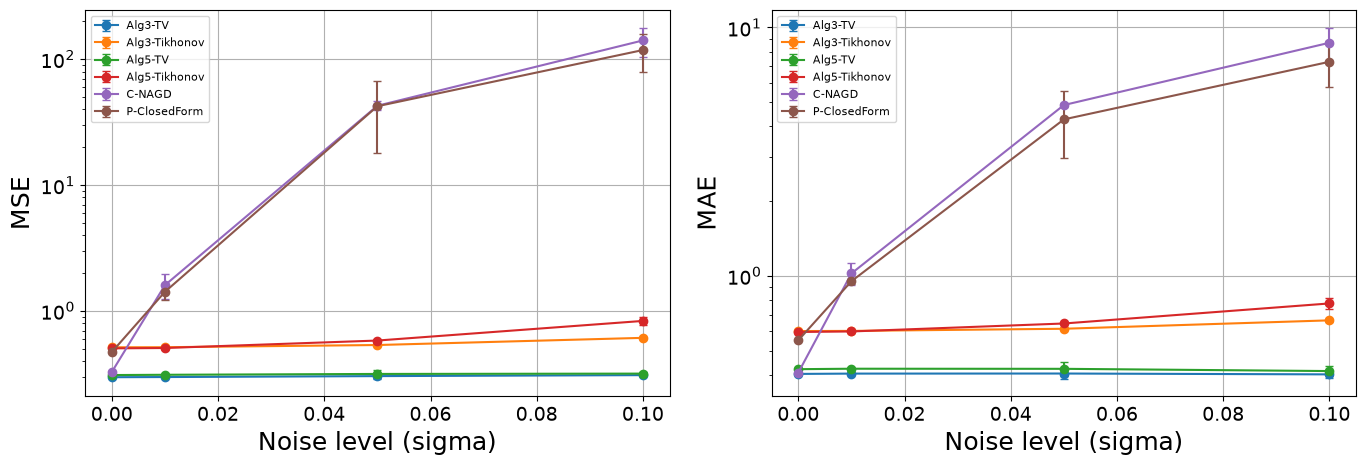

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for algorithm, group in noise_summary_df.groupby("algorithm"):
    axs[0].errorbar(group["sigma_noise"], group["mse_mean"], yerr=group["mse_std"], marker="o", label=algorithm, capsize=3)
    axs[1].errorbar(group["sigma_noise"], group["mae_mean"], yerr=group["mae_std"], marker="o", label=algorithm, capsize=3)
for ax, ylabel in zip(axs, ["MSE", "MAE"]):
    ax.set_xlabel("Noise level (sigma)")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding: the conjecture holds, and by a wider margin than expected.** Mean MSE over 3
realizations:

| $\sigma$ | Alg3-TV | Alg5-TV | Alg3-Tikh. | Alg5-Tikh. | C-NAGD | P-ClosedForm |
|---|---|---|---|---|---|---|
| $0$    | $\mathbf{0.298}$ | $0.310$ | $0.515$ | $0.505$ | $0.328$ | $0.472$ |
| $0.01$ | $\mathbf{0.299}$ | $0.311$ | $0.516$ | $0.508$ | $1.61$  | $1.42$ |
| $0.05$ | $\mathbf{0.304}$ | $0.316$ | $0.537$ | $0.583$ | $42.8$  | $42.4$ |
| $0.10$ | $\mathbf{0.309}$ | $0.318$ | $0.612$ | $0.834$ | $141.3$ | $118.6$ |

The separation is dramatic. Going from $\sigma=0$ to $\sigma=0.1$, C-NAGD degrades by
$431\times$ and P-ClosedForm by $251\times$, both roughly two and a half orders of magnitude.
Over the same range **Alg3-TV moves by $3.8\%$** ($0.2979\to0.3093$) and Alg5-TV by $2.7\%$. The
$\ell_2$-regularized primal-dual runs sit in between, degrading $19\%$ (Alg3) and $65\%$ (Alg5):
noticeably more robust than the baselines, far less so than TV. The ordering is already established
at $\sigma=0.01$, where C-NAGD has jumped $4.9\times$ to $1.61$ while Alg3-TV is unchanged at $0.299$.

Two observations beyond the headline. First, TV wins even at **zero** noise: Alg3-TV's $0.298$ beats
C-NAGD's $0.328$ and every other entry, so this is not purely a noise-robustness effect but a
better reconstruction outright, consistent with Section 6. Second, the standard deviations tell the
same story as the means. At $\sigma=0.1$, P-ClosedForm's MSE varies by $\pm39.2$ across just
three realizations (a third of its own mean), against $\pm0.006$ for Alg3-TV: the baselines are not
merely worse under noise, they are erratic.

**This is a direct, affirmative answer to the question the internship report posed but could not
test.** One caveat on strength: this sweep used $\lambda_\text{TV}=10^{-2}$, whereas Section 6 found
$10^{-3}$ optimal at zero noise, so the TV rows here are likely *not* showing TV at its best. The
Section 1 proxy-operator caveat also applies, so we present the magnitude as indicative and the
qualitative trend as solid.

## 10. Discussion

Collecting every finding above into a single narrative, organized the way the internship report's
own Discussion is organized (theory confirmed, theory nuanced, practical recommendations):

**What we confirmed.**
1. Algorithm 5's central promise (step sizes decoupled from $\lVert A\rVert$) is real
   and measured: $\lVert K\rVert\approx\lVert C\rVert$ throughout, giving a $2.93$&ndash;$4.17\times$
   larger admissible step than Algorithm 3 across the mesh-refinement sweep, and Algorithm 5 reaches
   a strictly better objective than Algorithm 3 at every fixed iteration budget we tested
   (Sections 3, 5.2).
2. Algorithm 5 maintains machine-precision PDE feasibility ($\lVert Ex\rVert\approx8.7\times10^{-15}$)
   at every iterate, against Algorithm 3's only-asymptotic $10^{-6}$, the structural payoff of
   keeping the constraint primal (Sections 3, 7).
3. Section 5.9's "predicted" crossover is real and measurable, landing exactly at $I=8$:
   `cached_splu` wins for $I\le4$, `smw` from $I=8$ onward with a monotonically widening margin,
   close to the report's own back-of-envelope estimate $N^*\approx13$ (Section 8).
4. Total Variation (via our graph-gradient proxy) improves both reconstruction quality and, most
   strikingly, noise robustness: at $\sigma=0.1$ the $\ell_2$ baselines degrade $250$&ndash;$430\times$
   while TV moves under $4\%$, directly confirming the internship report's untested conjecture
   (Section 9).

**What we nuanced or corrected.**
1. $\lVert A\rVert$ itself barely grows under mesh refinement on the raw exported matrices
   ($6.61\to7.55$); it is $\sigma_\text{min}(A)$ that collapses ($0.111\to0.0069$), so *conditioning*
   rather than *raw norm growth* is the more precise mechanism behind Algorithm 3's degradation
   (Section 5.2), consistent with the report's own more careful Eq. (57), if not its
   simplified Sec. 5.1 motivation.
2. **The apparent accuracy deficit of Algorithms 3 and 5 under Tikhonov was a mis-tuned weight, not
   a property of the algorithms.** Measured against the exact minimizer of the reduced problem rather
   than against each other, both converge to the right point; at the report's $\mu=10^{-6}$ the
   reduced problem has condition number $5.8\times10^{5}$, so an unaccelerated method needs
   $O(\kappa)\approx10^{6}$ iterations where accelerated C-NAGD needs $O(\sqrt\kappa)\approx760$
   and took $2150$. Choosing $\mu=10^{-3}$ *for the algorithm* closes the gap from $52\%$ to $5\%$
   ($0.343$ vs. C-NAGD's $0.327$). The earlier reading ("less accurate than every baseline, blame the
   $O(1/N)$ rate") had the mechanism half right and the magnitude entirely wrong (Sections 3.3, 5.1b).
   Total Variation still improves on both, but by $1.6\times$ over a properly tuned Tikhonov, not the
   $2.3\times$ over a mis-tuned one.
3. TV's advantage is **not** monotone in its weight, and it does not come from where one would
   assume. It beats Tikhonov only in a band around $\lambda_\text{TV}=10^{-3}$ (worse below
   $10^{-4}$, worse above $10^{-2}$, and at $\ge10^{-1}$ both algorithms saturate to a bit-identical
   degenerate solution). The first-order Tikhonov control, $\tfrac\mu2\lVert Gm\rVert^2$, which uses
   the *same* operator $G$ smoothly, reaches only $0.364$, marginally worse than penalizing the
   amplitude ($0.344$). So the gain is attributable to the **non-smoothness** of the $\ell_{2,1}$
   norm, i.e. edge preservation, not to the choice of differential operator (Sections 6, 6.1).
4. **Inexact projection is slower, not faster, at this problem size**: `smw_cg` takes $3.7\times$ the
   time of exact `smw` for identical MSE, and the two tolerance schedules $\gamma\in\{0.5,0.8\}$ are
   indistinguishable ($13.73$ vs. $13.66$ mean inner iterations), so Eq. (54)'s decay schedule is not
   the binding constraint here. `smw_cg` earns its place on memory, being the only backend that runs
   at $\delta=40$, not on speed (Sections 7, 8). Section 7.1 sharpens what the schedule *does* control:
   across seven schedules including two that violate Eq. (54), the reconstruction is identical to four
   digits, while feasibility spans thirteen orders of magnitude ($10^{-14}$ exact, $2.7\times10^{-9}$
   summable, $9.4\times10^{-2}$ constant). The summability condition buys the constraint, not the
   objective, and dropping it silently discards the one property that distinguishes Algorithm 5.
5. `DistributedChambollePock` (Algorithm 4) requires the regularization weight to be divided by the
   number of agents $S$ to reproduce the centralized Algorithm 3 solution, a consequence of Eq. (35)
   that is not stated anywhere in the report and that we discovered only by testing the two
   implementations against each other (Section 3.2).
6. The step-size instability threshold $\tau\sigma\lVert\cdot\rVert^2=1$ is sufficient, not tight:
   both algorithms tolerated $\alpha$ up to $1.05$ without visible divergence, and Algorithm 5 showed
   none even at $\alpha=1.2$ (Section 5.1).
7. SMW's advantage is specific to the *source-count* axis: on the $\delta$-sweep at fixed $I=2$,
   `cached_splu` stayed fastest throughout and the S2-vs-S3 ordering never flipped (Section 8).
8. Splitting the dual step *per dualized block* ($\Sigma=\operatorname{diag}(\sigma_1I,\sigma_2I)$,
   Eq. 34/56) is theoretically free but empirically negligible here: at matched primal/dual ratio it
   saves $3.9\%$ of the iterations at best, and nothing at all at $\gamma=1$. The two block norms
   differ by only $2.6$&ndash;$3.4\times$, not the $O(1/h^2)$ vs. $O(1/h)$ separation the theory
   assumes: partly a coarse mesh, partly our unweighted graph proxy for $G$, whose norm stays
   flat ($4.14\to4.26$) across the $\delta$-sweep instead of growing like $O(1/h)$. What does govern
   convergence speed is the primal/dual ratio $\gamma$, worth a $3.2\times$ swing in iteration
   count (Section 5.3).

**Practical recommendations.**
- Use `cached_splu` for $I\le4$ and exact `smw` from $I\approx8$; reserve `smw_cg` for cases where the
  dense $P\times P$ capacitance will not fit, which is the only reason $\delta=40$ ran at all.
- Swapping FISTA's existing `spsolve` prox for `make_prox_J_2_from_projector` is a free $4.6\times$
  speedup at identical fixed point ($1.36\times10^{-12}$ agreement), independent of everything else here.
- Give `DistributedChambollePock` `mu/S`, always.
- **Choose the regularization weight for the algorithm, not just for the problem.** It sets the
  strong-convexity modulus and hence the iteration count: $\mu=10^{-6}$ is a $5.8\times10^{5}$
  condition number and is unreachable unaccelerated; $\mu=10^{-3}$ costs $4\%$ of optimal MSE and is
  actually attained. If an accelerated variant is ever implemented, this recommendation reverses.
- Keep the tolerance schedule summable even though the reconstruction looks identical without it:
  what it protects is feasibility, which is the entire reason for using Algorithm 5.
- Tune the primal/dual ratio before anything else: a large primal and small dual step ($\gamma=0.3$,
  i.e. $\tau=3.0$) converges $3.2\times$ faster than §5.1's $\tau=\sigma$ convention on the same
  problem. Keep the per-block $\Sigma$ (it is free and its margin grows with mesh refinement),
  but do not expect it to carry a run on its own.

8. **Mesh refinement does four different things and only one of them is fast.** Sizes grow like
   $h^{-2}$ ($L,P,Q$), conditioning degrades like $h^{-2}$ ($\kappa(A)$: $60\to1087$), operator norms
   barely move at all ($\lVert A\rVert$: $\delta^{0.10}$, $\lVert G\rVert$: $\delta^{0.02}$,
   because the exported matrices are not mass-normalized and $G$ is an unweighted incidence operator),
   and the *data* grows only like $h^{-1}$ since the sensors live on a boundary. That last one is the
   quantity nobody tracks and the one that decides whether refinement is worth anything: unknowns per
   measurement go $3.9\to8.1\to16.8$, so a finer contrast mesh is a strictly harder inverse problem,
   not merely a bigger one (Section 5.2).
9. **Two algorithms cannot be compared until they are asked the same question.** Section 2 gave
   Algorithm 3 no regularizer and Algorithm 5 a Tikhonov one, and compared their data-fidelity values
   at Algorithm 3's *infeasible* iterates, where an infeasible point can score below any feasible one.
   Fixing both (same $\mu$, objective evaluated after projection onto the feasible set) puts all
   three algorithms on one figure converging to one known optimum, with Algorithm 5 $25\times$ closer
   in optimality gap after $10^4$ iterations (Section 5.1b).
10. **An error plateau cannot be a convergence test on an ill-conditioned problem, at any tuning.**
    The rule $|\Delta\mathrm{MSE}|<10^{-3}$ needs a window to mean anything at all (per-iteration
    changes are $O(10^{-7})$, so the naive form fires at iteration 1). Scoring nine candidate rules
    against the known optimum (Section 5.1c) shows why widening it does not rescue it: the error curve
    has long *flat shoulders* followed by further descent, so a one-shot test fires on the shoulder,
    with worst-case regret $0.138$ at $W=200$ and still $0.087$ at $W=2000$. Persistence helps more
    than width (three confirmations at $W=200$ beats one at $W=2000$), but the settings that are safe
    ($W\ge1000$, patience $3$, regret $0.000$) are safe only because they never fire inside $10^4$
    iterations. The fixed-point step $\lVert x_{k+1}-x_k\rVert$ is the better default at $0.015$
    worst-case regret, because it measures the iteration rather than the error; where the optimum is
    computable, report the optimality gap and skip the question (Sections 5.1b, 5.1c).
11. **MSE and MAE can rank two runs differently, and the disagreement is diagnostic.** They are tied
    by $\mathrm{MAE}\le\sqrt{\mathrm{MSE}}$, with equality only for a perfectly uniform error, so
    the ratio measures how *concentrated* the error is. It falls monotonically as reconstructions
    improve ($0.84$ at $\mu=10^{-6}$, $0.72$ at $10^{-3}$, $0.58$ for TV at $\lambda=10^{-3}$),
    because better methods recover most of the domain exactly and pile the remaining error onto a few
    cells: TV at its optimum puts $63\%$ of contrast cells within $0.1$ of the truth against $13\%$
    for Tikhonov. Where the two metrics disagree (order-0 Tikhonov, $\mu=10^{-3}$ vs $10^{-2}$), it is
    because smoothing converts many small errors into fewer large ones, which MAE rewards and MSE
    punishes (Section 6.1).

**What remains open / caveats.**
1. The Total Variation operator $G$ used throughout Sections 6 and 9 is a *structural proxy* built
   from $B_i$ co-occurrence, not the true finite-element inter-element jump operator, because
   `scripts/GenerateMatrix.edp` does not export mesh connectivity. Extending the FreeFEM export to
   include vertex coordinates and/or triangle adjacency, and rebuilding $G$ from it, is the single
   most valuable follow-up to make the TV/noise-robustness findings fully rigorous.
2. The TV weight was swept only on a decade grid $\{10^{-3},\dots,1\}$ with the optimum at the *edge*
   of the useful range; the noise study then used $10^{-2}$ rather than the optimal $10^{-3}$. A finer
   sweep below $10^{-2}$, re-run through the noise protocol, would likely improve the TV numbers further.
3. Neither Algorithm 3 nor Algorithm 5 is accelerated in this implementation; the partial-acceleration
   framework the report outlines in Sec. 4.8/5.5 (Valkonen&ndash;Pock, accelerating only the
   strongly-convex Tikhonov subspace) was not implemented here and is the most direct lever on the
   accuracy gap identified in point 2 above.
4. `DistributedChambollePock` and `DistributedBlockGradientDescent` support an `mpi4py`-based
   multi-process mode (`use_mpi=True`) that this notebook does not exercise (everything above runs
   single-process, iterating over agents in a Python loop); validating the MPI path on an actual
   multi-node/multi-process setup is future work.
5. The noise study used 3 realizations per level. The trends are far larger than the observed spread,
   but tighter error bars would need the report's own 10-realization protocol.

## 11. Conclusion

This notebook implemented and evaluated the three Chambolle&ndash;Pock-family algorithms of
Sections 4 and 5 of the follow-up report: centralized dualized (Algorithm 3), distributed
with exact consensus (Algorithm 4), and projected with exact/inexact affine feasibility (Algorithm
5). All three were compared against Matthieu M&eacute;rigot-Lombard's original P-ClosedForm/C-NAGD/FISTA baselines,
reproducing his exact reported numbers as a correctness check before extending the comparison.

Where the follow-up report's Section 5.9 stops at *predicting* what a source-count and mesh-density
sweep would show, we generated the data (`scripts/GenerateMatrixSweep.edp`) and ran it: the predicted
SMW/cached-factorization crossover is real, lands exactly at $I=8$, close to the report's own
estimate, and is specific to the source-count axis rather than mesh refinement in general. Where the
report motivates Algorithm 5 with a simplified $\lVert A\rVert=O(1/h^2)$ claim, we measured the actual
operator norms and found the more precise mechanism is $A$'s *conditioning*, a correction to,
not a rejection of, the report's central argument. Where the internship report speculated that Total
Variation could help with noisy measurements but lacked the algorithm to test it, we built one (via a
documented structural proxy for the missing mesh-connectivity export) and found the conjecture holds
emphatically: at $\sigma=0.1$ the $\ell_2$ baselines degrade by two and a half orders of magnitude
while TV moves under $4\%$.

The most useful corrective this notebook supplies is about *where* Section 5's machinery actually
pays, and it took a convergence audit to get it right. Measured against the closed-form minimizer of
the reduced problem rather than against each other, Algorithms 3 and 5 turn out to converge to the
correct point all along; what made them look "less accurate than the baselines" was inheriting
$\mu=10^{-6}$, a weight that gives the reduced problem a condition number of $5.8\times10^{5}$ and is
therefore unreachable without acceleration. Choosing the weight for the algorithm closes a $52\%$
accuracy gap to $5\%$. The rate gap is real, but it is a $\sqrt{\kappa}$-versus-$\kappa$ story about
conditioning, not evidence that the primal-dual formulation reconstructs badly. The inexact projection
that Sec. 5.5 licenses is, separately, $3.7\times$ *slower* than the exact one at this problem size. What these algorithms genuinely deliver is structural: exact PDE feasibility at every iterate,
step sizes independent of $\lVert A\rVert$, tractability at mesh densities where forming $EE^*$ is
impossible, and, decisively, the ability to carry a Total Variation regularizer at all,
which is what produces the best reconstruction in this notebook ($\text{MSE}=0.219$) and the noise
robustness above.

Two contributions stand out as most actionable for continuing this line of work, and the audit has
sharpened the case for the second. (i) Extending `GenerateMatrix.edp` to export true mesh
connectivity, so the Total Variation results (now the strongest results here) can be re-validated
with the real finite-element jump operator instead of our graph proxy; this would also restore the
$O(1/h)$ scaling of $\lVert G\rVert$ that our unweighted incidence proxy lacks, which is what the
block-preconditioning machinery of Section 5.3 needs in order to be worth anything. (ii) Implementing
the partial-acceleration scheme of Sec. 4.8/5.5 (Valkonen&ndash;Pock on the strongly-convex Tikhonov
subspace). This is no longer a nice-to-have: Section 3.3 shows the iteration count scales like
$\kappa=(\lVert\Phi\rVert^2+\mu)/\mu$, so acceleration would take it to $\sqrt\kappa$ and let
these methods use the small weights that give the *best* reconstructions ($\mu=10^{-6}$ has the
lowest optimal MSE, $0.327$, and is currently the one weight we cannot reach). Acceleration is the
difference between choosing the regularizer we want and the one we can afford.